# project setup

In [1]:
from pathlib import Path
import sys

CURRENT_DIR = Path.cwd().resolve()

REPO_ROOT = CURRENT_DIR

while REPO_ROOT.name != "tube-bending-geometry":
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("Repository root was not found.")
    REPO_ROOT = REPO_ROOT.parent

QRF_ROOT = (
    REPO_ROOT
    / "src"
    / "pipeline"
    / "ml"
    / "qrf"
)

for path in (REPO_ROOT, QRF_ROOT):
    path_str = str(path)

    if path_str not in sys.path:
        sys.path.insert(0, path_str)

# imports

In [2]:
from mode.experiments.qrf_pipeline import (
    load_config,
    run_experiments,
)

from utils.experiments.plot import (
    plot_metric_by_tree_count,
    plot_prediction_interval,
)

# load config

In [3]:
PROJECT_ROOT = QRF_ROOT

CONFIG_PATH = (
    QRF_ROOT
    / "configs"
    / "tree_convergence_ranked.yaml"
)

config = load_config(
    config_path=CONFIG_PATH,
    project_root=REPO_ROOT,
)

#config

In [4]:
from copy import deepcopy

import pandas as pd


def select_ranked_split_indices(
    split_metadata: pd.DataFrame,
    rank_column: str,
    top_n: int,
    worst_n: int,
) -> dict[str, list[int]]:
    """
    Select the best and worst split indices according to one axis-specific
    QRF ranking column.

    Smaller rank values represent better splits.
    """

    required_columns = {
        "split_index",
        rank_column,
    }

    missing_columns = (
        required_columns
        - set(split_metadata.columns)
    )

    if missing_columns:
        raise KeyError(
            "Missing required split-metadata columns: "
            f"{sorted(missing_columns)}"
        )

    ranked_df = (
        split_metadata[
            [
                "split_index",
                rank_column,
            ]
        ]
        .dropna(
            subset=[
                "split_index",
                rank_column,
            ]
        )
        .drop_duplicates(
            subset=["split_index"]
        )
        .sort_values(
            by=[
                rank_column,
                "split_index",
            ],
            ascending=[
                True,
                True,
            ],
        )
        .reset_index(drop=True)
    )

    minimum_required_splits = (
        top_n
        + worst_n
    )

    if len(ranked_df) < minimum_required_splits:
        raise ValueError(
            f"Cannot select {top_n} top and {worst_n} worst splits "
            f"from only {len(ranked_df)} ranked splits."
        )

    top_split_indices = (
        ranked_df
        .head(top_n)["split_index"]
        .astype(int)
        .tolist()
    )

    worst_split_indices = (
        ranked_df
        .tail(worst_n)["split_index"]
        .astype(int)
        .tolist()
    )

    selected_split_indices = list(
        dict.fromkeys(
            top_split_indices
            + worst_split_indices
        )
    )

    return {
        "top": top_split_indices,
        "worst": worst_split_indices,
        "all": selected_split_indices,
    }


SPLIT_METADATA_PATH = (
    REPO_ROOT
    / config["paths"]["split_metadata"]
)

split_metadata_df = pd.read_parquet(
    SPLIT_METADATA_PATH
)

split_selection_config = (
    config["search"]["split_selection"]
)

top_n = int(
    split_selection_config["top_n"]
)

worst_n = int(
    split_selection_config["worst_n"]
)

rank_columns = (
    split_selection_config["rank_columns"]
)

selected_splits_by_axis = {}

for axis in config["search"]["axes"]:
    selected_splits_by_axis[axis] = (
        select_ranked_split_indices(
            split_metadata=split_metadata_df,
            rank_column=rank_columns[axis],
            top_n=top_n,
            worst_n=worst_n,
        )
    )

# selected_splits_by_axis

# run

In [5]:
from copy import deepcopy

import pandas as pd


SUPPORTED_VARYING_PARAMETERS = {
    "n_estimators",
    "max_depth",
    "min_samples_leaf",
    "min_samples_split",
    "max_features",
    "bootstrap",
    "lower_quantile",
    "upper_quantile",
    "quantile_interval",
}


varying_parameter = config[
    "search"
]["varying_parameter"]

parameter_values = config[
    "search"
]["parameter_values"]


if varying_parameter not in SUPPORTED_VARYING_PARAMETERS:
    raise ValueError(
        "Unsupported varying_parameter: "
        f"{varying_parameter!r}. "
        "Supported parameters are: "
        f"{sorted(SUPPORTED_VARYING_PARAMETERS)}"
    )


if len(parameter_values) < 2:
    raise ValueError(
        "search.parameter_values must contain "
        "at least two values."
    )


base_n_estimators = int(
    config["model"]["n_estimators"]
)


all_metrics = []
all_predictions = []

run_directories = {
    axis: []
    for axis in config["search"]["axes"]
}


for axis in config["search"]["axes"]:
    selected_indices = (
        selected_splits_by_axis[
            axis
        ]["all"]
    )

    selection_group_map = {
        **{
            split_index: "top"
            for split_index
            in selected_splits_by_axis[
                axis
            ]["top"]
        },
        **{
            split_index: "worst"
            for split_index
            in selected_splits_by_axis[
                axis
            ]["worst"]
        },
    }

    print(
        f"\nAxis: {axis}"
    )

    print(
        "Top splits:",
        selected_splits_by_axis[
            axis
        ]["top"],
    )

    print(
        "Worst splits:",
        selected_splits_by_axis[
            axis
        ]["worst"],
    )

    for parameter_value in parameter_values:
        axis_config = deepcopy(
            config
        )

        axis_config["search"]["axes"] = [
            axis
        ]

        axis_config["search"]["split_indices"] = (
            selected_indices
        )

        if varying_parameter == "n_estimators":
            current_n_estimators = int(
                parameter_value
            )

            axis_config["search"][
                "n_estimators"
            ] = [
                current_n_estimators
            ]

            axis_config["model"][
                "n_estimators"
            ] = current_n_estimators

            varying_value = (
                current_n_estimators
            )

        else:
            # Tree count remains fixed when another
            # hyperparameter is studied.
            axis_config["search"][
                "n_estimators"
            ] = [
                base_n_estimators
            ]

            axis_config["model"][
                "n_estimators"
            ] = base_n_estimators

            if (
                varying_parameter
                == "quantile_interval"
            ):
                if (
                    not isinstance(
                        parameter_value,
                        (list, tuple),
                    )
                    or len(parameter_value) != 2
                ):
                    raise ValueError(
                        "Every quantile_interval value "
                        "must be [lower, upper]."
                    )

                lower_quantile = float(
                    parameter_value[0]
                )

                upper_quantile = float(
                    parameter_value[1]
                )

                if not (
                    0.0
                    < lower_quantile
                    < upper_quantile
                    < 1.0
                ):
                    raise ValueError(
                        "Quantiles must satisfy "
                        "0 < lower < upper < 1."
                    )

                axis_config["model"][
                    "lower_quantile"
                ] = lower_quantile

                axis_config["model"][
                    "upper_quantile"
                ] = upper_quantile

                varying_value = (
                    f"{lower_quantile:g}"
                    f"–"
                    f"{upper_quantile:g}"
                )

            else:
                axis_config["model"][
                    varying_parameter
                ] = parameter_value

                varying_value = (
                    parameter_value
                )

        safe_value = (
            str(varying_value)
            .replace(" ", "_")
            .replace("/", "_")
        )

        axis_config[
            "experiment_name"
        ] = (
            f"{config['experiment_name']}"
            f"__{axis}"
            f"__{varying_parameter}"
            f"__{safe_value}"
        )

        print(
            f"Running {varying_parameter}="
            f"{varying_value}"
        )

        (
            current_metrics_df,
            current_predictions_df,
            current_run_dir,
        ) = run_experiments(
            axis_config
        )

        current_metrics_df = (
            current_metrics_df.copy()
        )

        current_metrics_df[
            "varying_parameter"
        ] = varying_parameter

        current_metrics_df[
            "varying_value"
        ] = varying_value

        current_metrics_df[
            "selection_group"
        ] = current_metrics_df[
            "split_index"
        ].map(
            selection_group_map
        )

        if (
            varying_parameter
            == "quantile_interval"
        ):
            current_metrics_df[
                "quantile_interval"
            ] = varying_value
        else:
            current_metrics_df[
                varying_parameter
            ] = parameter_value

        all_metrics.append(
            current_metrics_df
        )

        if current_predictions_df is not None:
            current_predictions_df = (
                current_predictions_df.copy()
            )

            current_predictions_df[
                "varying_parameter"
            ] = varying_parameter

            current_predictions_df[
                "varying_value"
            ] = varying_value

            current_predictions_df[
                "selection_group"
            ] = current_predictions_df[
                "split_index"
            ].map(
                selection_group_map
            )

            all_predictions.append(
                current_predictions_df
            )

        run_directories[
            axis
        ].append(
            current_run_dir
        )


metrics_df = pd.concat(
    all_metrics,
    ignore_index=True,
)


if all_predictions:
    predictions_df = pd.concat(
        all_predictions,
        ignore_index=True,
    )
else:
    predictions_df = pd.DataFrame()


run_dir = run_directories


print(
    "\nVarying parameter:",
    varying_parameter,
)

print(
    "Tested values:",
    metrics_df[
        "varying_value"
    ]
    .drop_duplicates()
    .tolist(),
)

print(
    "n_estimators values:",
    metrics_df[
        "n_estimators"
    ]
    .drop_duplicates()
    .tolist(),
)

# display(
#     metrics_df[
#         [
#             "axis",
#             "split_index",
#             "selection_group",
#             "varying_parameter",
#             "varying_value",
#             "n_estimators",
#             "max_depth",
#             "min_samples_leaf",
#             "min_samples_split",
#             "max_features",
#             "bootstrap",
#             "lower_quantile",
#             "upper_quantile",
#             "coverage_percent",
#             "rmse",
#             "mae",
#             "mean_interval_width",
#         ]
#     ].head(30)
# )


Axis: main
Top splits: [1, 7, 8]
Worst splits: [5, 4, 3]
Running n_estimators=1
Finished split-001__trees-0001__axis-main: coverage=0.00% | rmse=0.4484
Finished split-007__trees-0001__axis-main: coverage=0.00% | rmse=0.5785
Finished split-008__trees-0001__axis-main: coverage=0.00% | rmse=0.5102
Finished split-005__trees-0001__axis-main: coverage=0.00% | rmse=0.5253
Finished split-004__trees-0001__axis-main: coverage=0.00% | rmse=0.5646
Finished split-003__trees-0001__axis-main: coverage=0.00% | rmse=0.5780
Running n_estimators=2
Finished split-001__trees-0002__axis-main: coverage=3.39% | rmse=0.4496
Finished split-007__trees-0002__axis-main: coverage=1.23% | rmse=0.5743
Finished split-008__trees-0002__axis-main: coverage=1.83% | rmse=0.5101
Finished split-005__trees-0002__axis-main: coverage=2.22% | rmse=0.5260
Finished split-004__trees-0002__axis-main: coverage=2.06% | rmse=0.5626
Finished split-003__trees-0002__axis-main: coverage=1.32% | rmse=0.5772
Running n_estimators=3
Finished 

# Effect of split definition on QRF performance

Each categorical train/test split is evaluated using the four components
of the QRF ranking score:

- absolute empirical-coverage error from the nominal 90% interval,
- root mean squared error,
- mean absolute error,
- mean prediction-interval width.

Main-axis and secondary-axis results are ranked independently. Lower
values indicate better performance for all displayed metrics.

# Main and secondary QRF convergence

The two target axes are evaluated separately. The table reports the
QRF-ranking components used to explain why a split with higher coverage
may still receive a worse overall rank.

In [6]:
selected_split_rows = []

for axis, groups in selected_splits_by_axis.items():
    rank_column = (
        config["search"]
        ["split_selection"]
        ["rank_columns"]
        [axis]
    )

    for selection_group in (
        "top",
        "worst",
    ):
        split_indices = groups[
            selection_group
        ]

        current_rows = (
            split_metadata_df.loc[
                split_metadata_df[
                    "split_index"
                ].isin(split_indices)
            ]
            .copy()
        )

        current_rows["axis"] = axis
        current_rows[
            "selection_group"
        ] = selection_group

        current_rows[
            "selected_axis_rank"
        ] = current_rows[
            rank_column
        ]

        selected_split_rows.append(
            current_rows
        )


selected_split_summary_df = pd.concat(
    selected_split_rows,
    ignore_index=True,
)

selected_split_summary_df = (
    selected_split_summary_df
    .sort_values(
        by=[
            "axis",
            "selected_axis_rank",
        ]
    )
    .reset_index(drop=True)
)

display_columns = [
    "axis",
    "selection_group",
    "split_index",
    "selected_axis_rank",
]

optional_columns = [
    "split_name",
    "split_features",
    "split_conditions",
]

display_columns += [
    column
    for column in optional_columns
    if column
    in selected_split_summary_df.columns
]

# display(
#     selected_split_summary_df[
#         display_columns
#     ]
# )

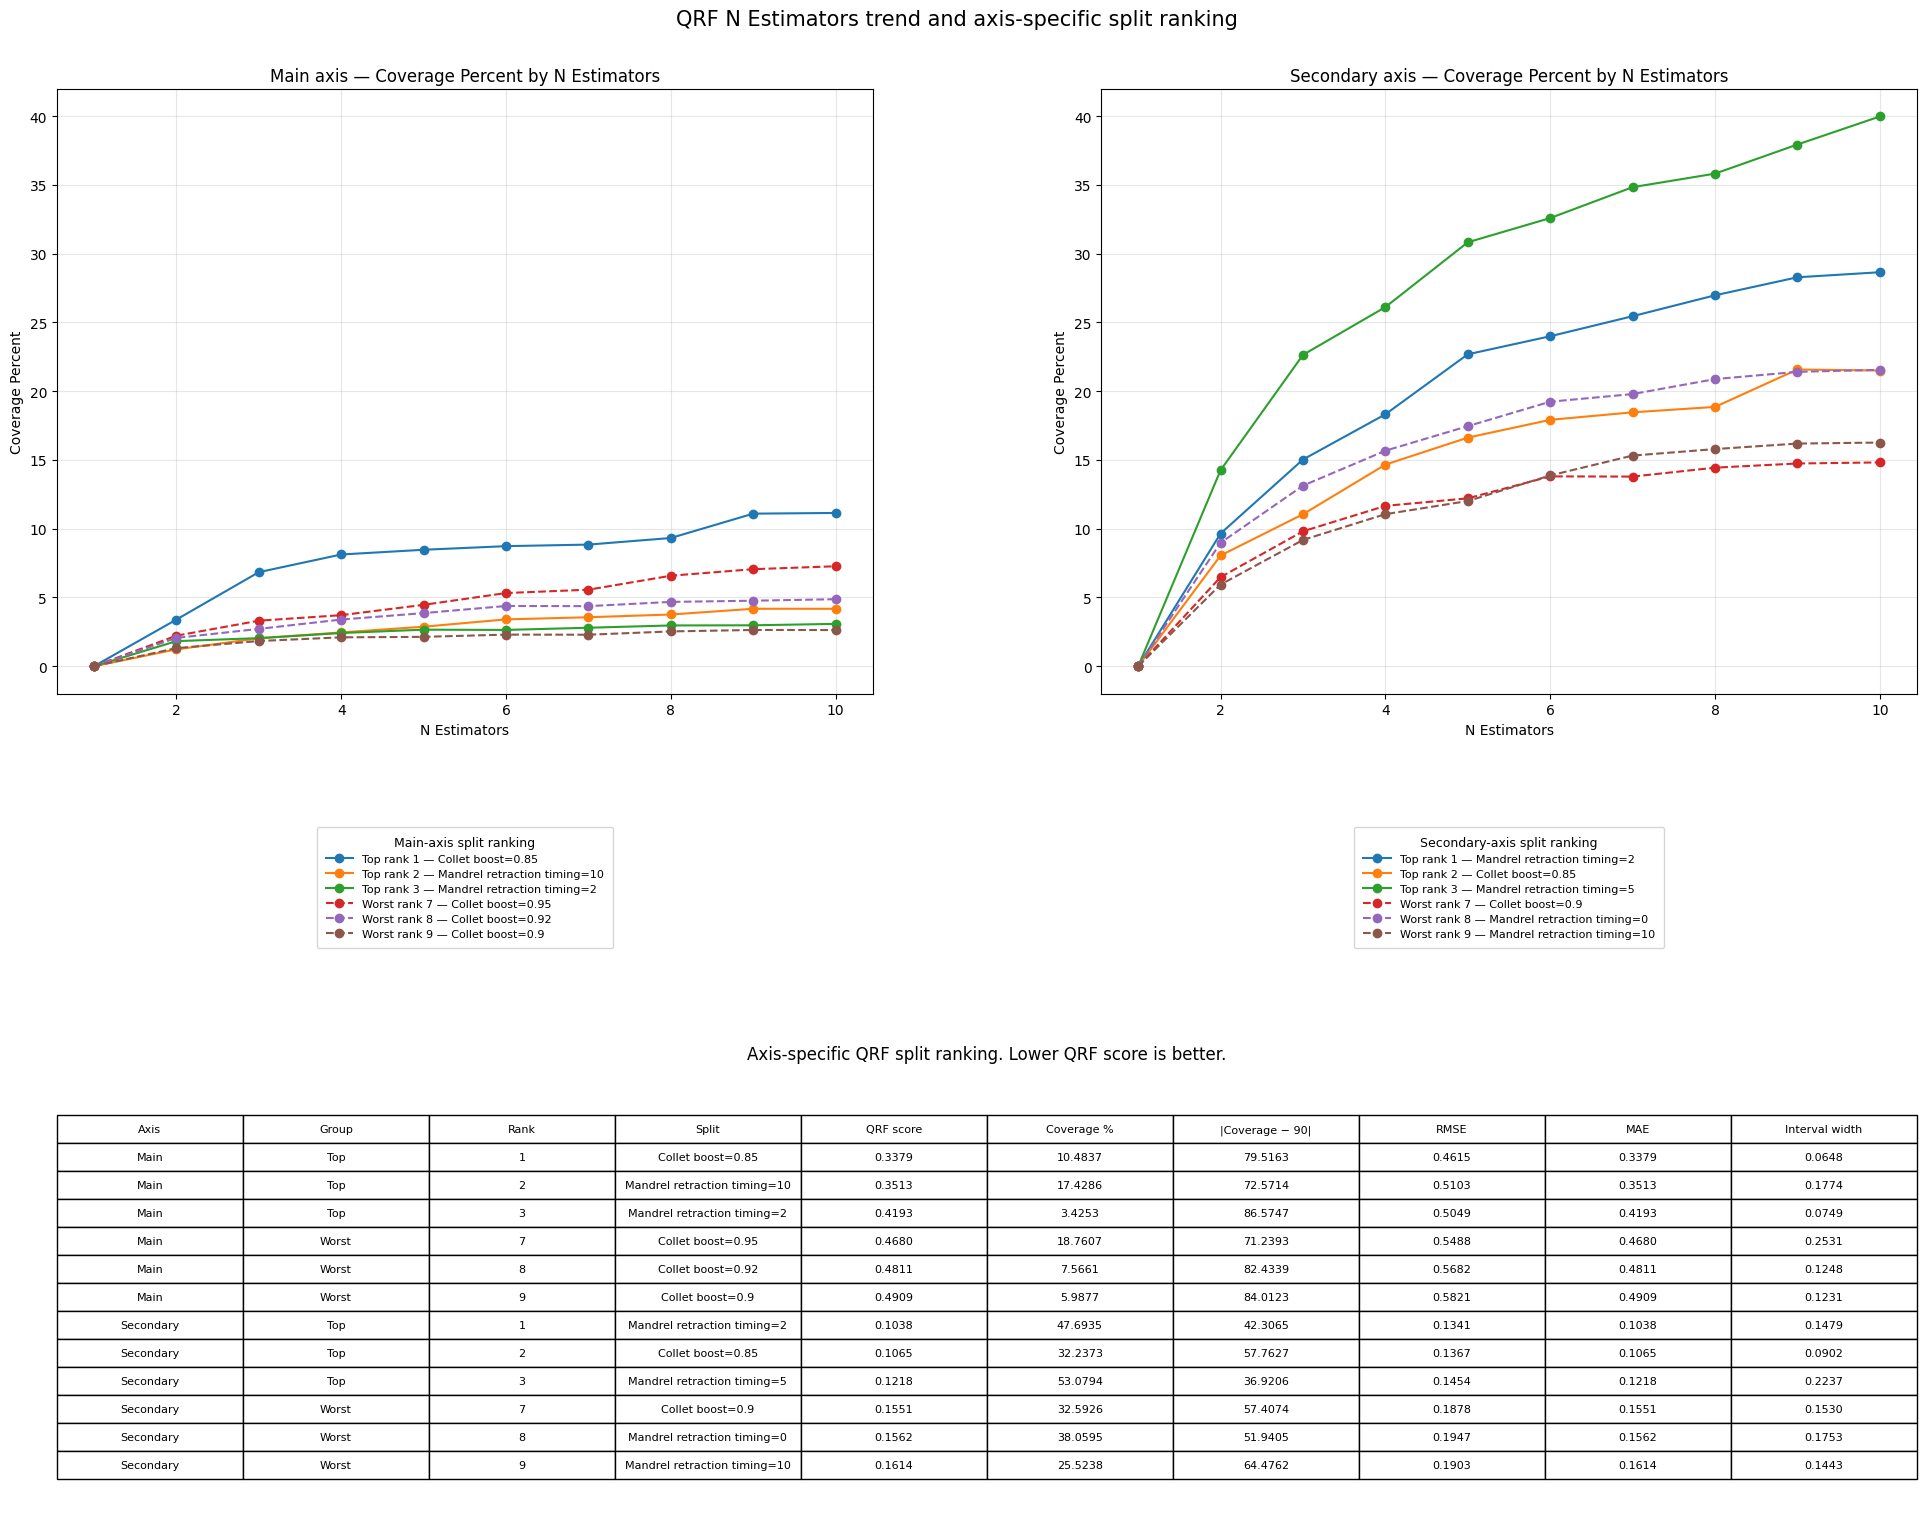

In [7]:
from utils.experiments.plot import (
    plot_main_secondary_convergence_with_ranking,
)


SPLIT_METADATA_PATH = (
    REPO_ROOT
    / config["paths"]["split_metadata"]
)

varying_parameter = config[
    "search"
]["varying_parameter"]

ranking_explanation_df = (
    plot_main_secondary_convergence_with_ranking(
        metrics_df=metrics_df,
        split_metadata=SPLIT_METADATA_PATH,
        metric="coverage_percent",
        x_parameter=varying_parameter,
        top_n=config[
            "search"
        ][
            "split_selection"
        ][
            "top_n"
        ],
        worst_n=config[
            "search"
        ][
            "split_selection"
        ][
            "worst_n"
        ],
    )
)

# display(
#     ranking_explanation_df
# )

### RMSE plot

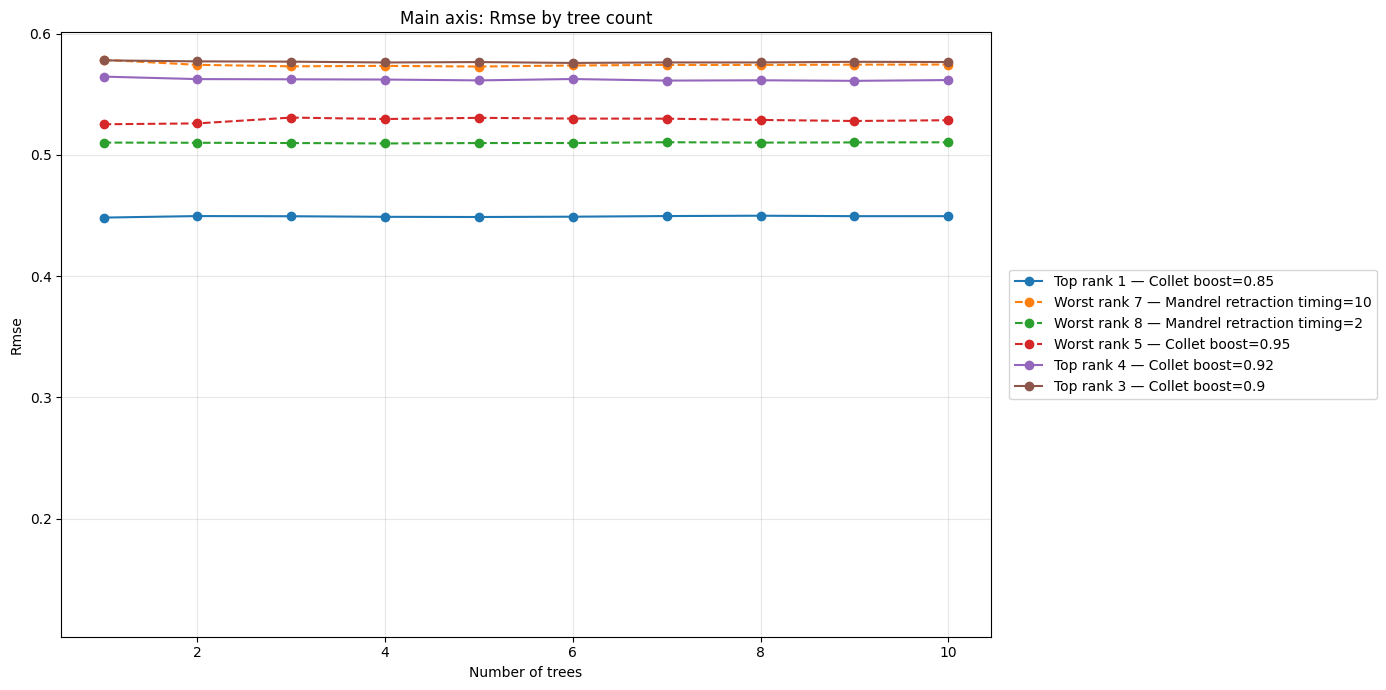

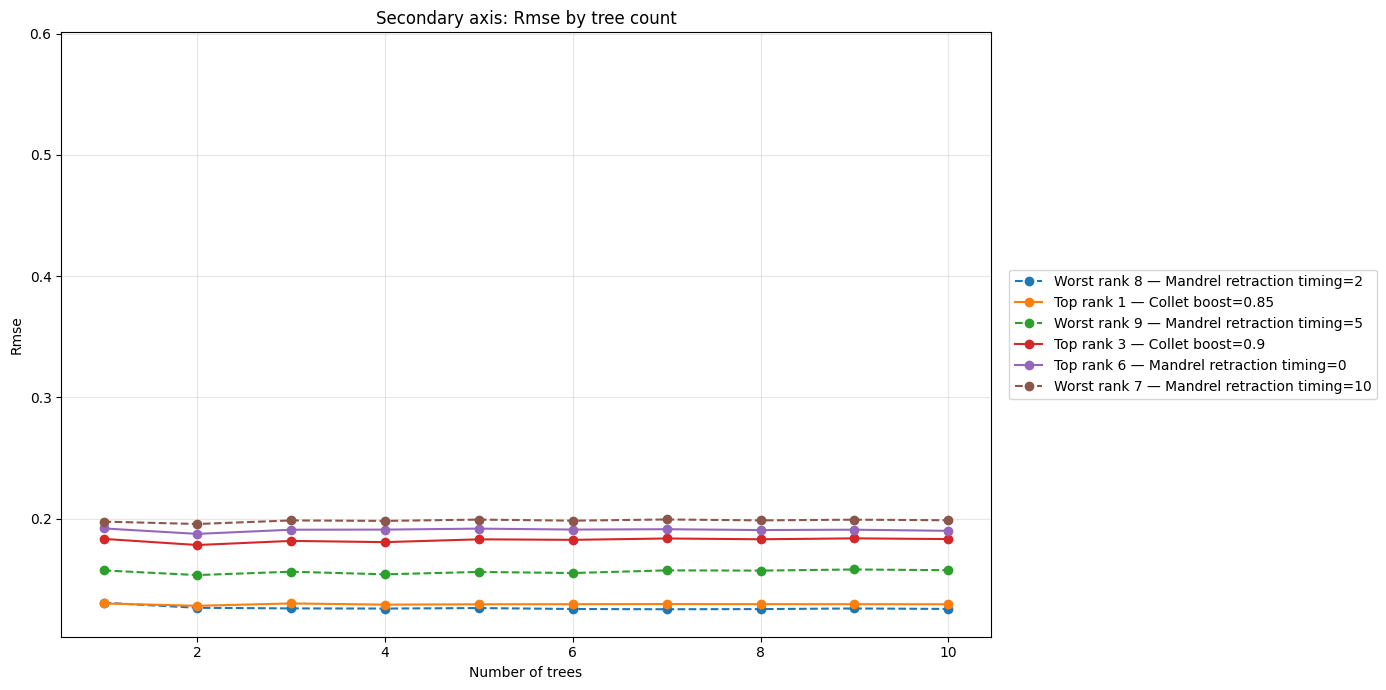

In [8]:
metric = "rmse"

metric_values = pd.to_numeric(
    metrics_df[metric],
    errors="coerce",
).dropna()

metric_min = float(metric_values.min())
metric_max = float(metric_values.max())

metric_range = metric_max - metric_min

padding = (
    metric_range * 0.05
    if metric_range > 0
    else max(abs(metric_min), 1.0) * 0.05
)

shared_ylim = (
    metric_min - padding,
    metric_max + padding,
)

for axis in config["search"]["axes"]:
    plot_metric_by_tree_count(
        metrics_df=metrics_df,
        metric=metric,
        axis=axis,
        top_n=config["search"]["split_selection"]["top_n"],
        worst_n=config["search"]["split_selection"]["worst_n"],
        ylim=shared_ylim,
    )

# Bending-Setup Feature Ranking and Group-Spread Visualization

This notebook visualizes the ranked bending-setup features.

For each ranked feature:

- The feature values are shown as the main groups on the x-axis.
- Each bending setup group is represented by a separate bar.
- The y-axis represents the selected group-spread metric, such as PINAW or mean pairwise distance.
- Features are plotted according to their ranking order.

In [9]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt

CURRENT_DIR = Path.cwd().resolve()

REPO_ROOT = CURRENT_DIR

while REPO_ROOT.name != "tube-bending-geometry":
    if REPO_ROOT == REPO_ROOT.parent:
        raise RuntimeError("Repository root was not found.")
    REPO_ROOT = REPO_ROOT.parent

QRF_ROOT = (
    REPO_ROOT
    / "src"
    / "pipeline"
    / "ml"
    / "qrf"
)

for path in [REPO_ROOT, QRF_ROOT]:
    path_str = str(path)

    if path_str not in sys.path:
        sys.path.insert(0, path_str)

from utils.experiments.bending_ranked_feature_plot import (
    PAIRWISE_DISTANCE_COLUMN,
    STD_DISTANCE_COLUMN,
    build_feature_plot_dataframe,
    compute_group_mean_pairwise_distance,
    compute_group_std_distance,
    convert_group_id,
    get_available_ranked_features,
    plot_adjusted_effect_by_feature_value,
    plot_metric_distribution_by_feature_value,
    plot_metric_mean_median_trend,
    plot_ranked_feature_group_spread,
    resolve_column_name,
    select_ranked_features,
)

In [10]:
TOP_N_FEATURES = None

RANKING_PATH = (
    QRF_ROOT
    / "data"
    / "bending_setup_group_spread_feature_ranking.parquet"
)

BENDING_SETUP_PATH = (
    REPO_ROOT
    / "data"
    / "rf_augmented"
    / "ui_data"
    / "unique_bending_setups.csv"
)

EXPERIMENT_DATA_PATH = (
    REPO_ROOT
    / "data"
    / "rf_augmented"
    / "ui_data"
    / "final_geometry_within_group_interpolation_raw.csv"
)

In [11]:
ranking_df = pd.read_parquet(RANKING_PATH)
bending_setup_df = pd.read_csv(BENDING_SETUP_PATH)
experiment_df = pd.read_csv(EXPERIMENT_DATA_PATH)

bending_group_column = resolve_column_name(
    bending_setup_df,
    "Group_ID",
)

experiment_group_column = resolve_column_name(
    experiment_df,
    "Group_ID",
)

bending_setup_df[bending_group_column] = convert_group_id(
    bending_setup_df[bending_group_column]
)

experiment_df[experiment_group_column] = convert_group_id(
    experiment_df[experiment_group_column]
)

/var/folders/kb/kmrwh0z16f1bq6q4bmbcnxvc0000gn/T/ipykernel_5844/3003111070.py:3: DtypeWarning: Columns (17,18,19,20) have mixed types. Specify dtype option on import or set low_memory=False.
  experiment_df = pd.read_csv(EXPERIMENT_DATA_PATH)


## Top 3 and worst 3 split train-value maps

This section compares the **three best** and **three worst** QRF-ranked splits.

The function creates six figures:

1. Top rank 1
2. Top rank 2
3. Top rank 3
4. Worst rank 1
5. Worst rank 2
6. Worst rank 3

Each figure contains two panels:

- **Left:** main-axis split
- **Right:** secondary-axis split

For every bending-setup feature, all observed values are normalised independently
to the range `[-1, 1]`.

- A **filled blue circle** means that value occurs in at least one training group.
- An **open black circle** means that value does not occur in any training group.

Train membership is determined from `train_group_ids` in
`various_splits.parquet` and `Group_ID` in `unique_bending_setups.csv`.

The metrics box reports the available axis-specific test metrics.

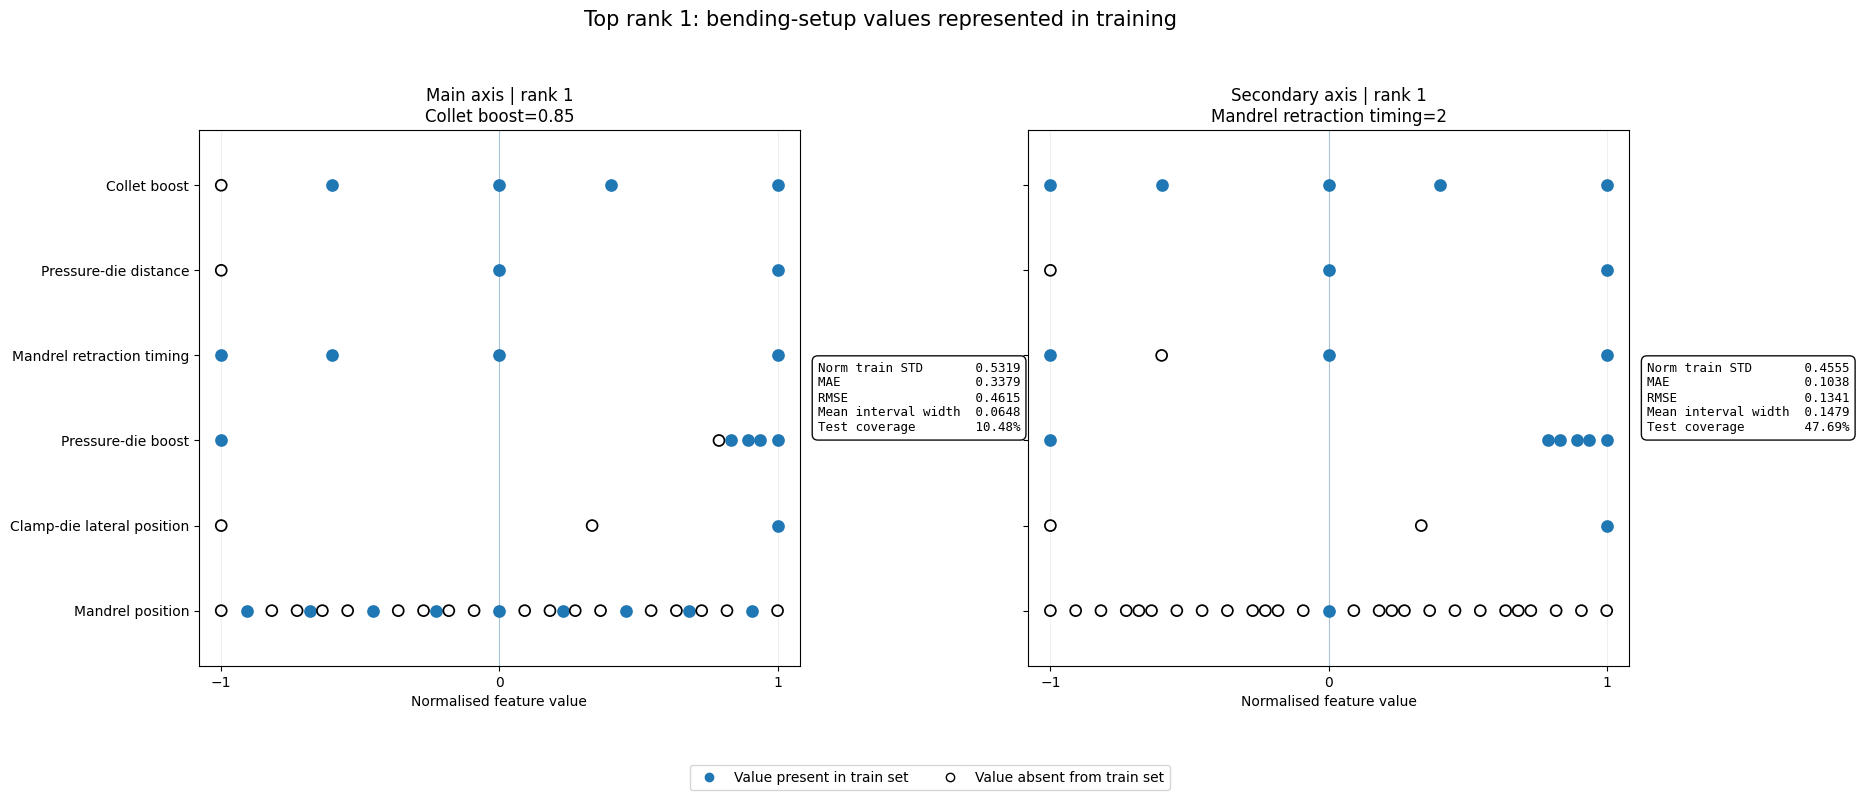

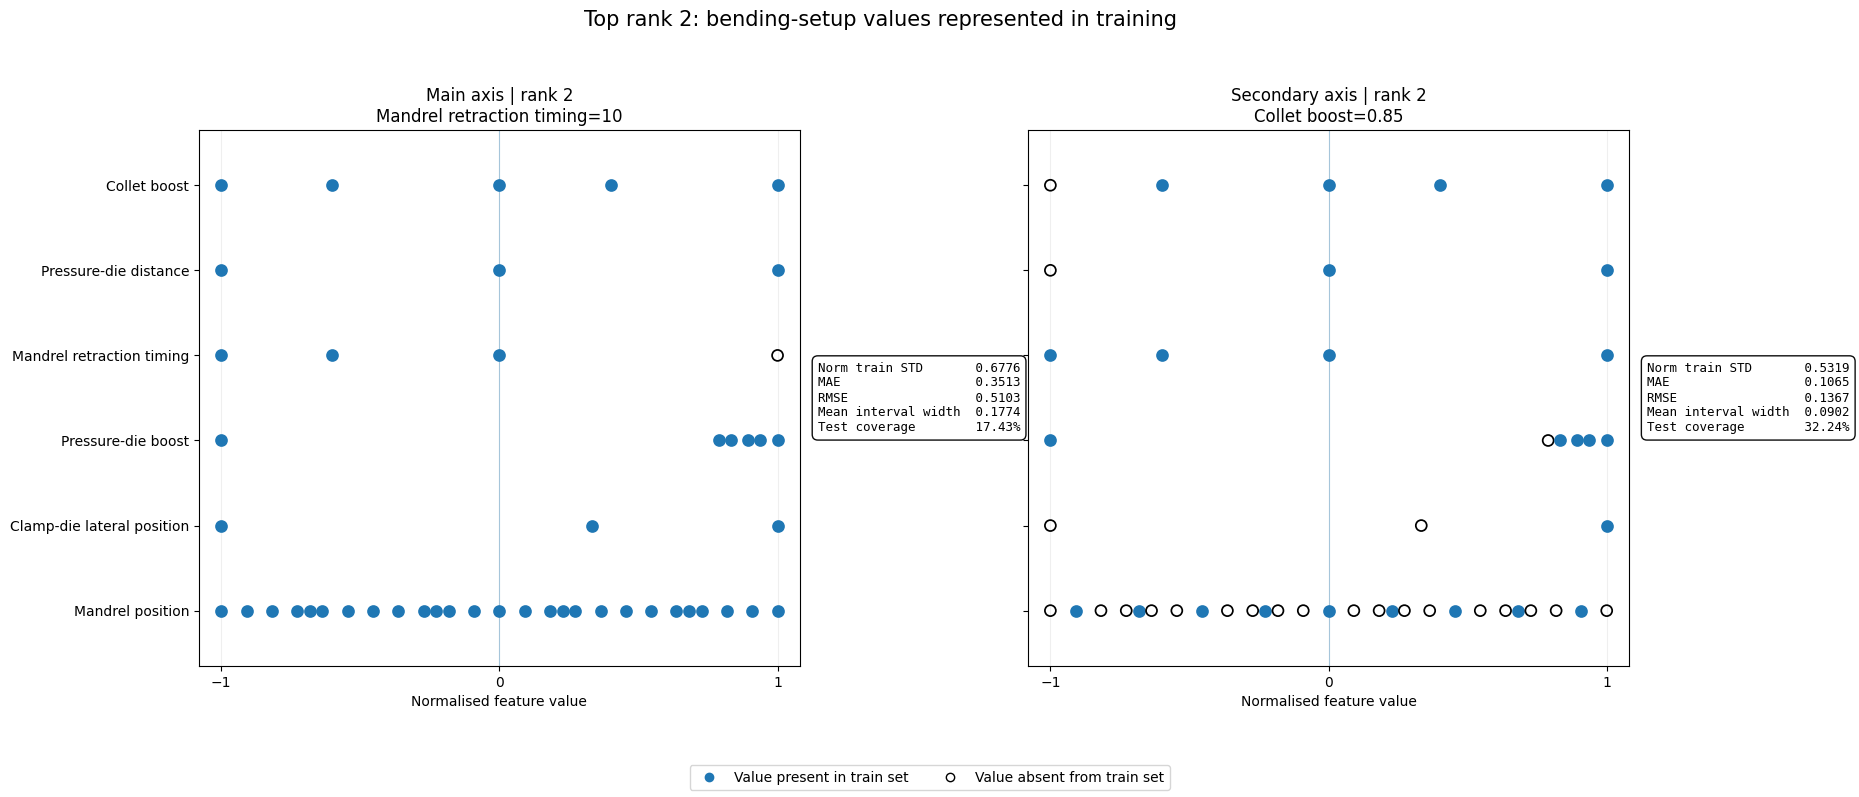

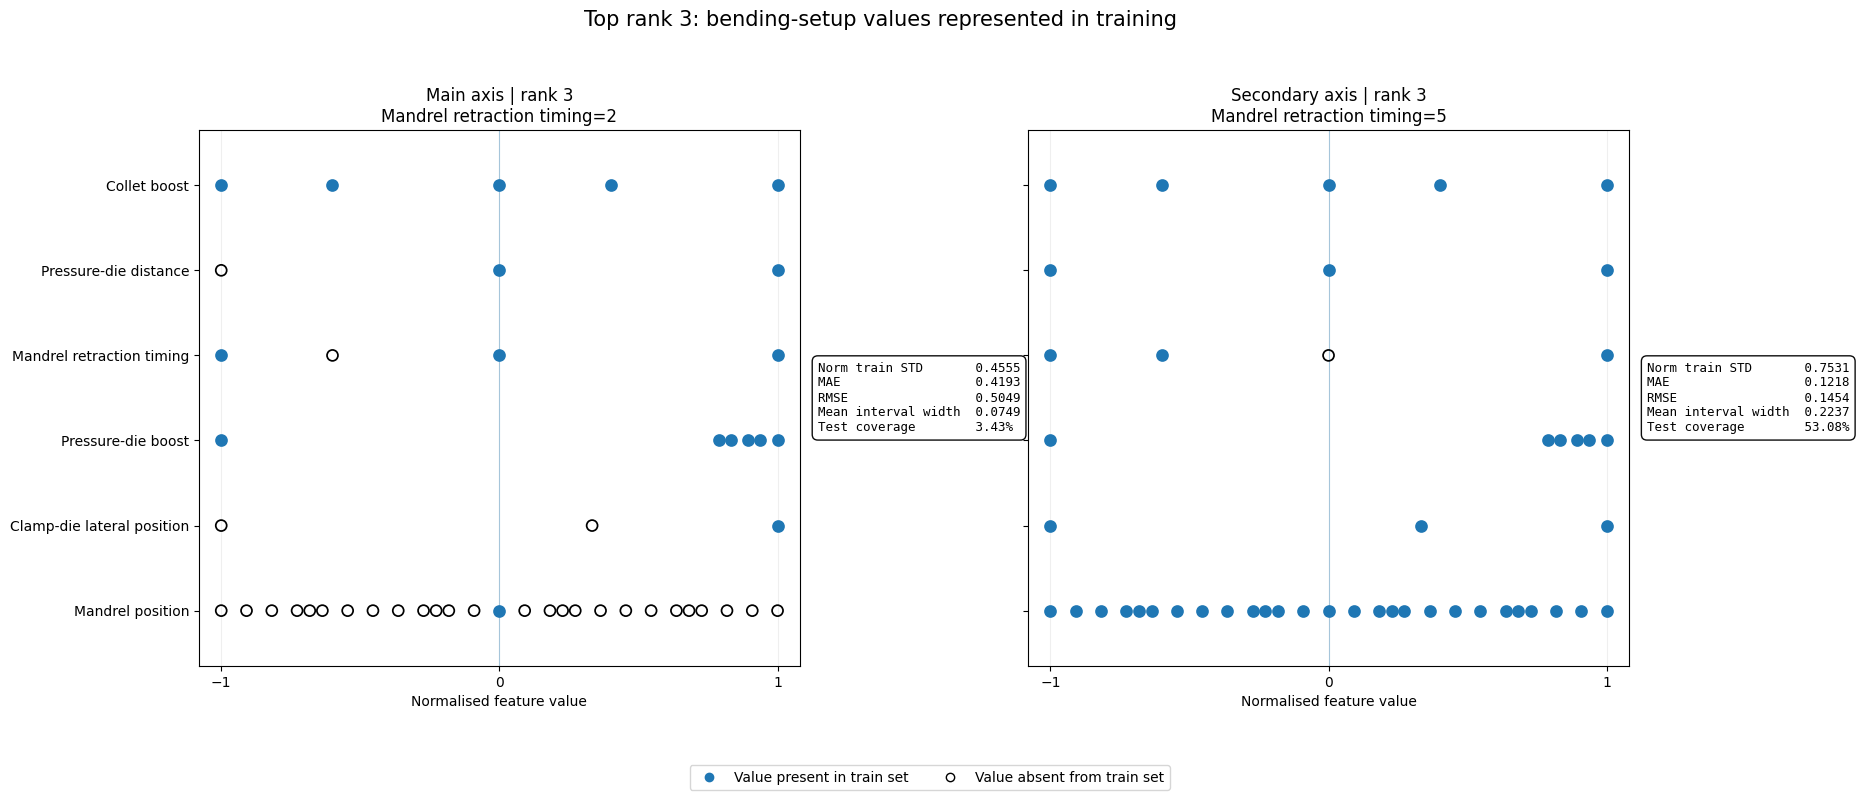

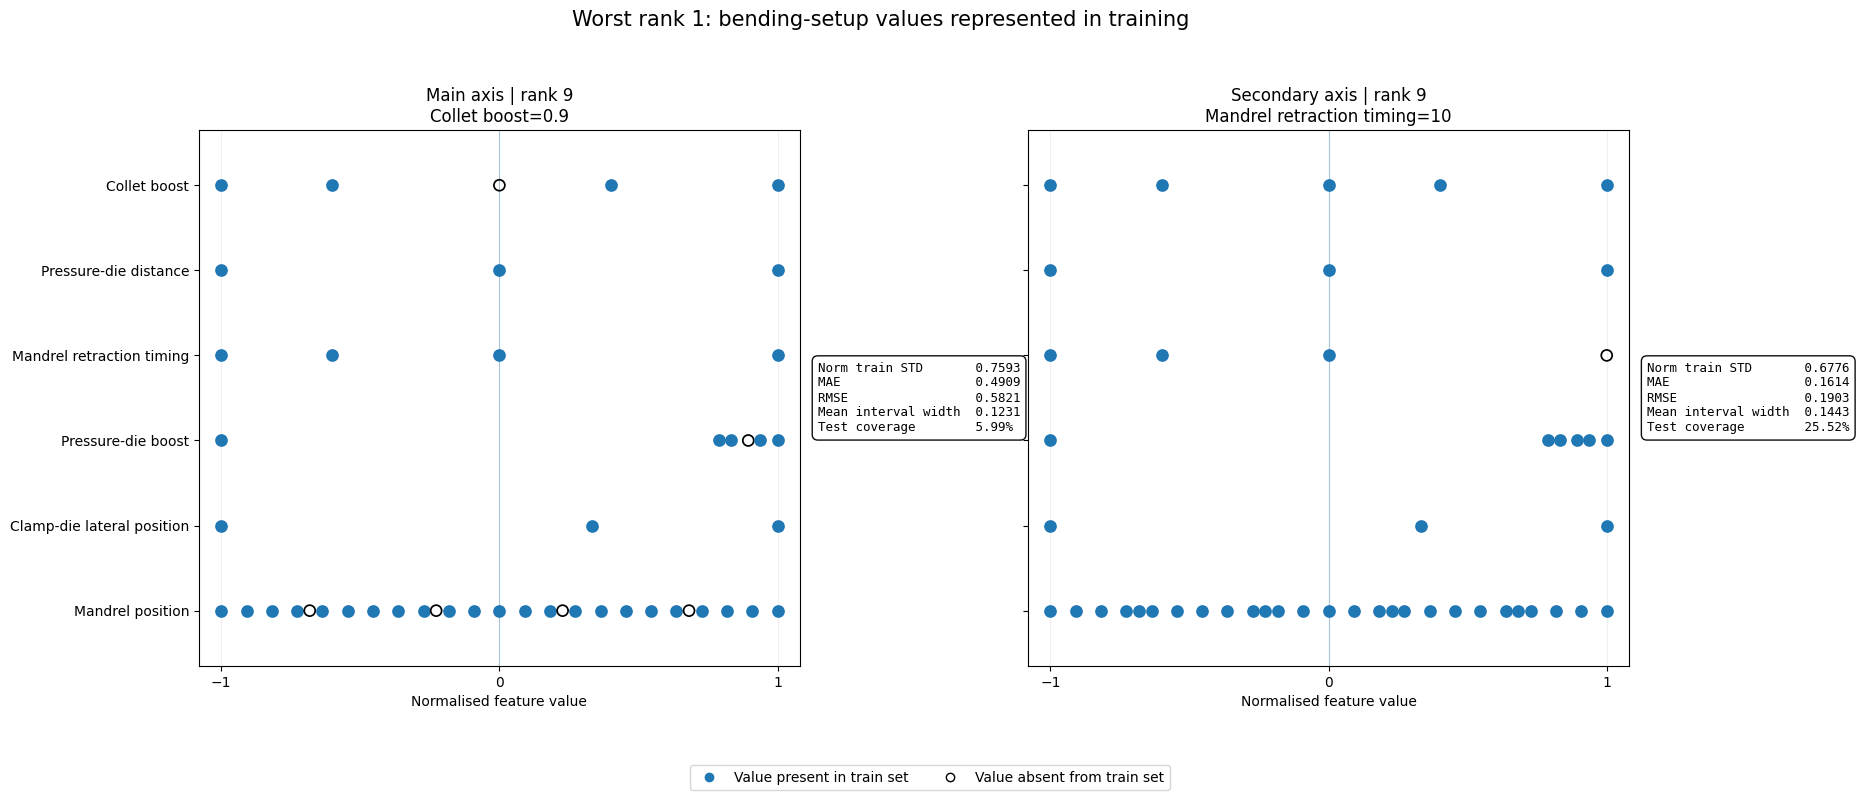

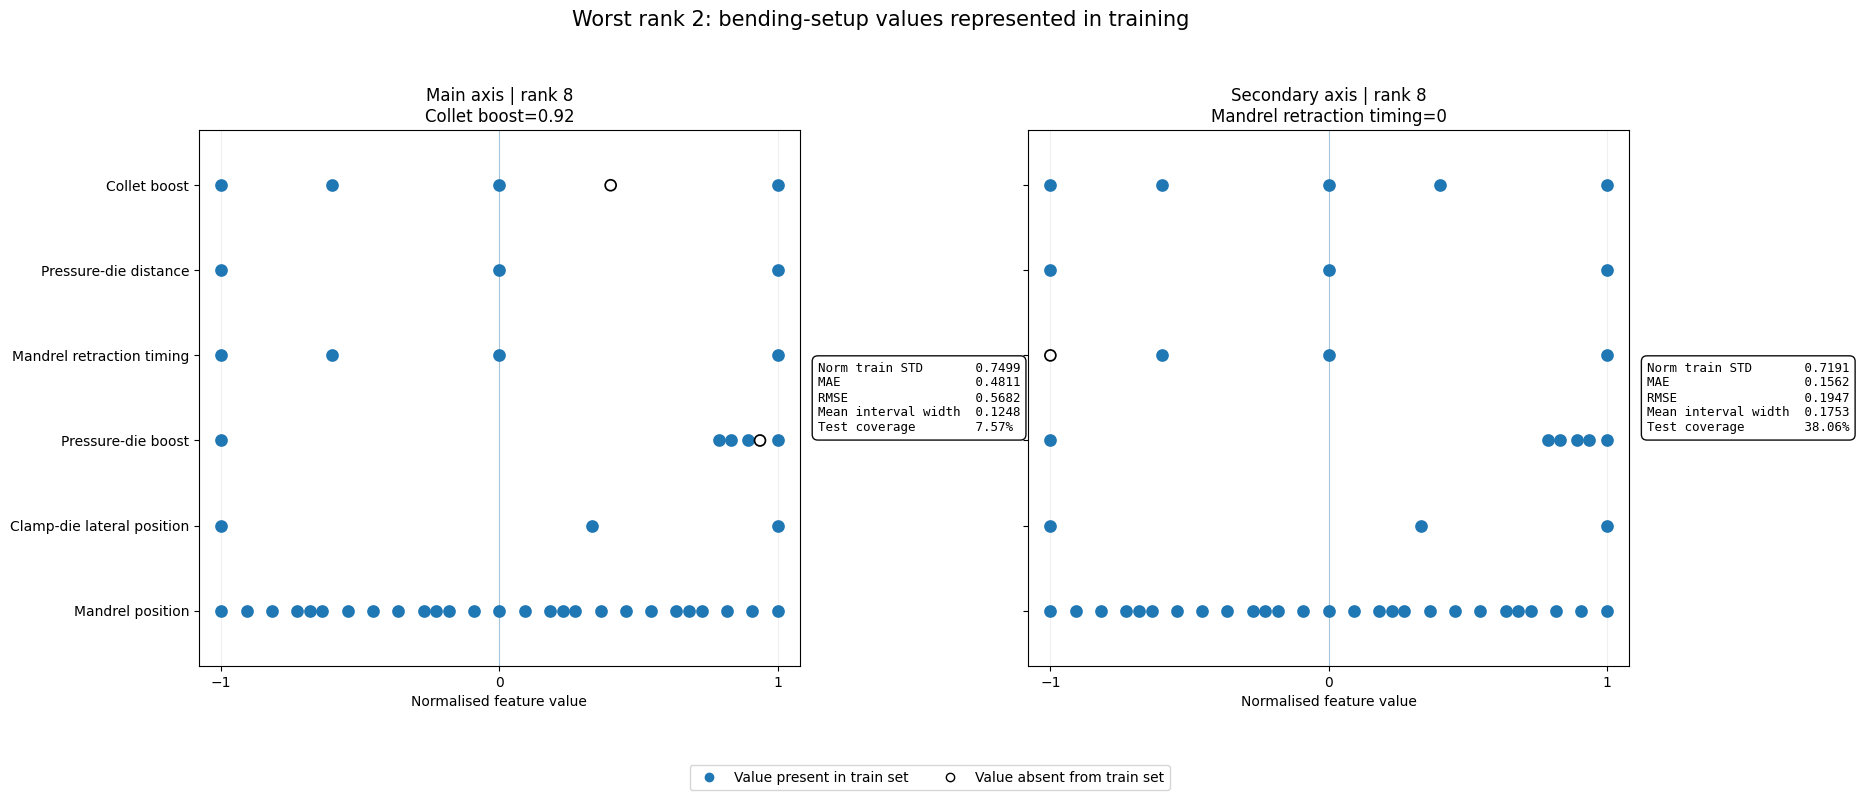

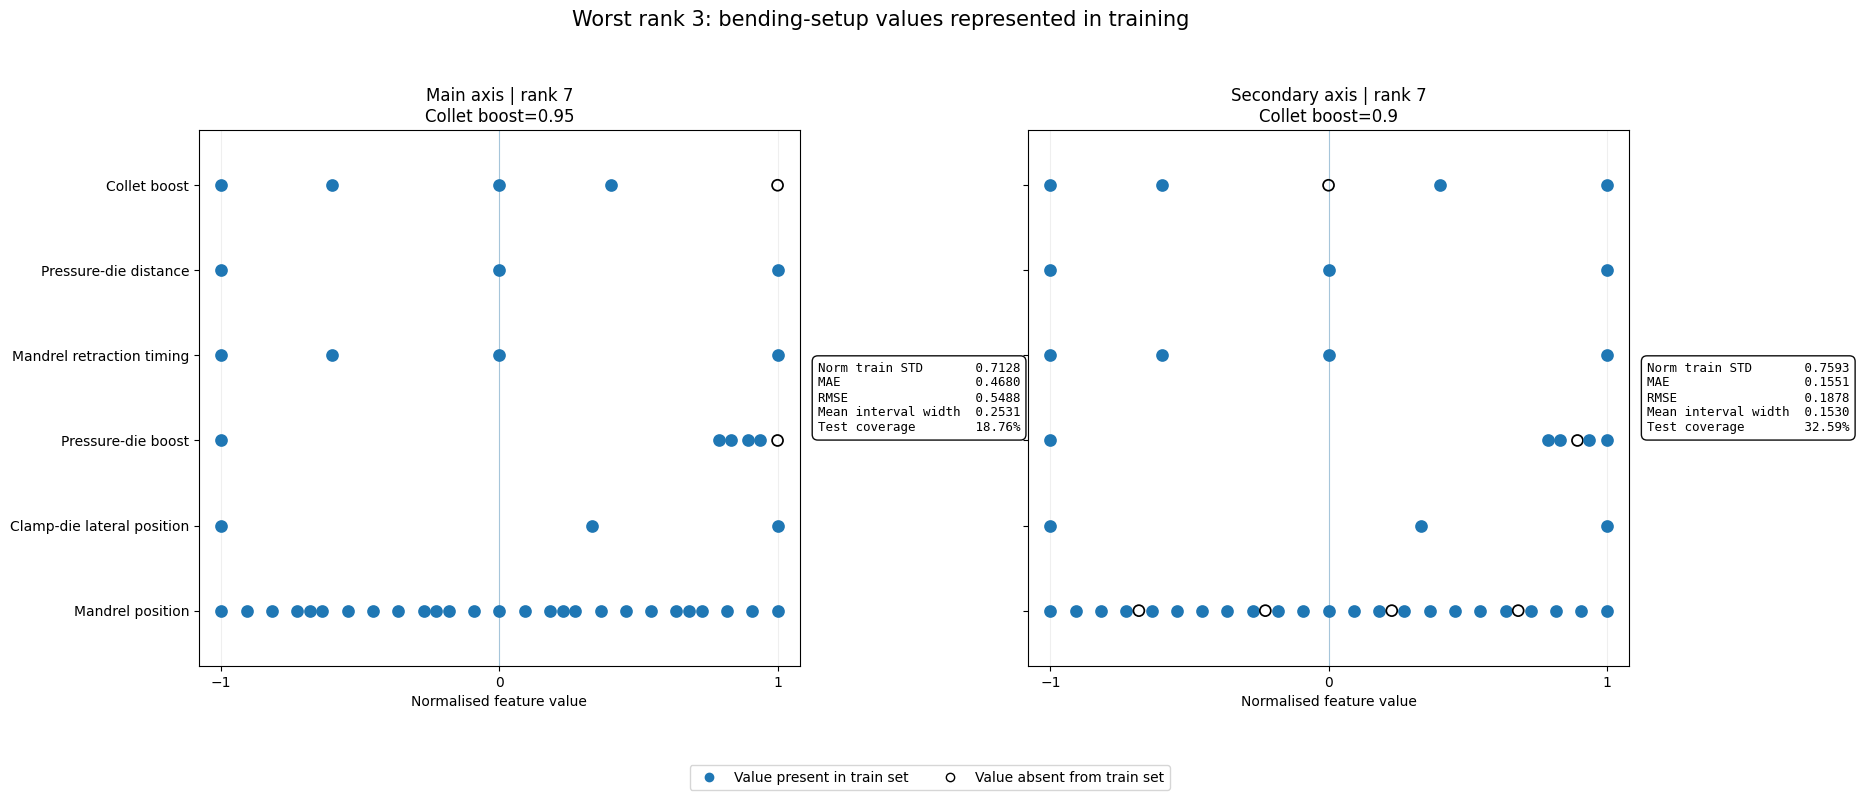

,figure_group,axis,split_index,split_name,rank,mean_train_feature_std,train_feature_std_by_feature
0,Top rank 1,main,1,Collet boost=0.85,1,0.531919,"{'Collet boost': 0.5830951894845299, 'Pressure..."
1,Top rank 1,secondary,8,Mandrel retraction timing=2,1,0.455523,"{'Collet boost': 0.7088018058667742, 'Pressure..."
2,Top rank 2,main,7,Mandrel retraction timing=10,2,0.677586,"{'Collet boost': 0.7088018058667742, 'Pressure..."
3,Top rank 2,secondary,1,Collet boost=0.85,2,0.531919,"{'Collet boost': 0.5830951894845299, 'Pressure..."
4,Top rank 3,main,8,Mandrel retraction timing=2,3,0.455523,"{'Collet boost': 0.7088018058667742, 'Pressure..."
5,Top rank 3,secondary,9,Mandrel retraction timing=5,3,0.753109,"{'Collet boost': 0.7088018058667742, 'Pressure..."
6,Worst rank 1,main,3,Collet boost=0.9,9,0.759322,"{'Collet boost': 0.7921489758877431, 'Pressure..."
7,Worst rank 1,secondary,7,Mandrel retraction timing=10,9,0.677586,"{'Collet boost': 0.7088018058667742, 'Pressure..."
8,Worst rank 2,main,4,Collet boost=0.92,8,0.749914,"{'Collet boost': 0.7533259586659682, 'Pressure..."
9,Worst rank 2,secondary,6,Mandrel retraction timing=0,8,0.719087,"{'Collet boost': 0.7088018058667742, 'Pressure..."


In [12]:
from utils.experiments.plot import (
    plot_top_worst_split_value_maps,
)

SPLIT_VALUE_FEATURES = [
    "Collet boost",
    "Pressure-die distance",
    "Mandrel retraction timing",
    "Pressure-die boost",
    "Clamp-die lateral position",
    "Mandrel position",
]

split_value_figures, split_value_summary_df = (
    plot_top_worst_split_value_maps(
        split_metadata=split_metadata_df,
        bending_setup_df=bending_setup_df,
        feature_names=SPLIT_VALUE_FEATURES,
        bending_group_column=bending_group_column,
        train_group_ids_column="train_group_ids",
        top_n=3,
        worst_n=3,
        figsize=(22, 8),
        marker_size=62,
        show=True,
    )
)

display(split_value_summary_df)

# Coverage Trend

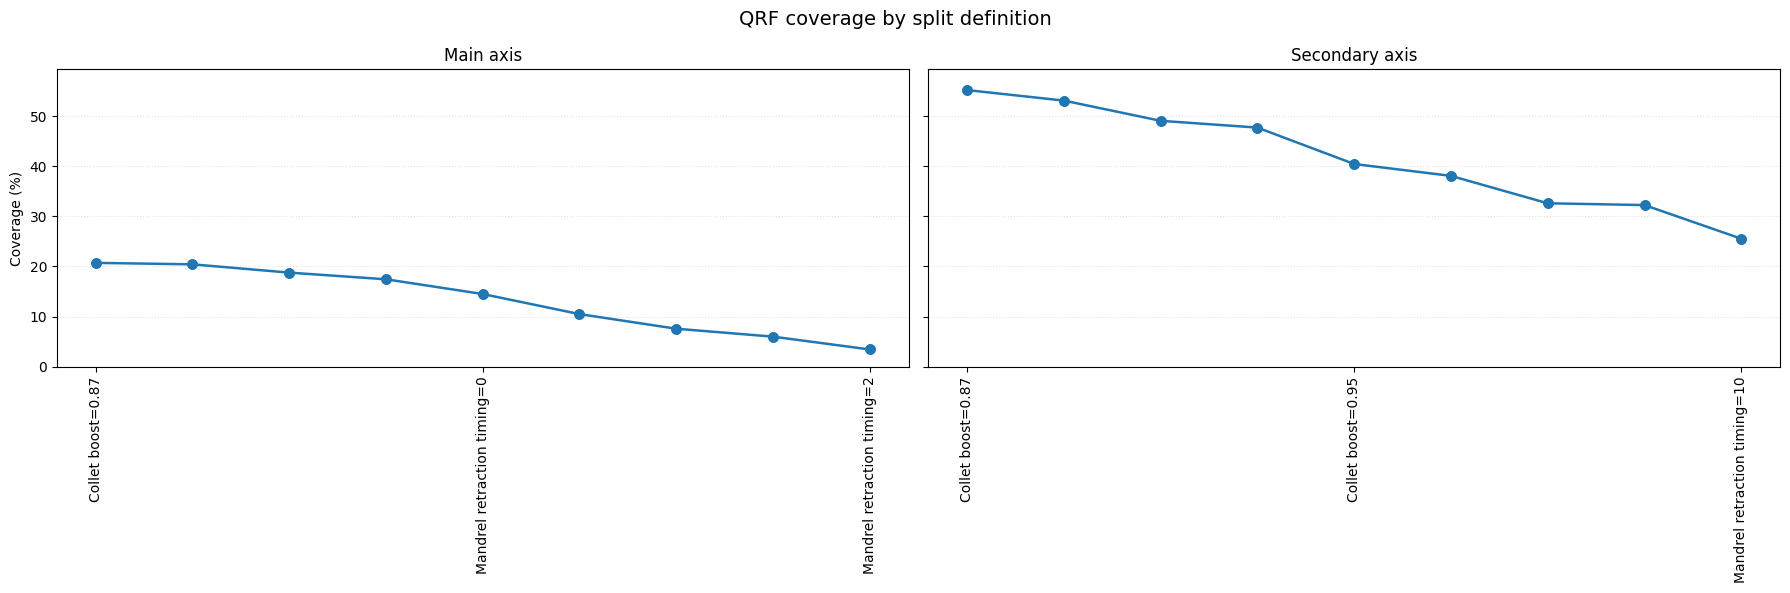

In [13]:
from utils.experiments.plot import (
    plot_split_coverage_by_split_name,
)

coverage_figure, coverage_summary_df = (
    plot_split_coverage_by_split_name(
        split_metadata=split_metadata_df,
        sort_by="coverage",
        ascending=False,
        figsize=(18, 6),
        marker_size=44,
        show_split_names=False,
        show=True,
    )
)

# display(coverage_summary_df)

In [14]:
ranked_features_main_df, _, feature_column, rank_column, _ = (
    select_ranked_features(
        ranking_data=ranking_df,
        geometry_type="main",
        top_n_features=TOP_N_FEATURES,
    )
)

available_ranked_features, missing_ranked_features = get_available_ranked_features(
    ranked_features=ranked_features_main_df,
    bending_data=bending_setup_df,
    feature_column=feature_column,
)

if missing_ranked_features:
    print("Features missing from bending setup data:")
    for feature_name in missing_ranked_features:
        print(f"  - {feature_name}")

# display(ranked_features_main_df)

In [15]:
def build_axis_plot_data(
    feature_name: str,
    geometry_type: str,
    distance_columns: list[str],
):
    ranked_features_axis_df, _, feature_column, rank_column, _ = (
        select_ranked_features(
            ranking_data=ranking_df,
            geometry_type=geometry_type,
            top_n_features=None,
        )
    )

    feature_rank = ranked_features_axis_df.loc[
        ranked_features_axis_df[feature_column].eq(feature_name),
        rank_column,
    ].iloc[0]

    group_distance_df = compute_group_mean_pairwise_distance(
        dataframe=experiment_df,
        group_column=experiment_group_column,
        distance_columns=distance_columns,
        standardize=True,
    )

    group_distance_df = group_distance_df.rename(
        columns={
            experiment_group_column: bending_group_column,
        }
    )

    feature_plot_df = build_feature_plot_dataframe(
        feature_name=feature_name,
        bending_data=bending_setup_df,
        group_distance_data=group_distance_df,
        bending_group_name=bending_group_column,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
    )

    return feature_plot_df, feature_rank

Mean Pairwise based

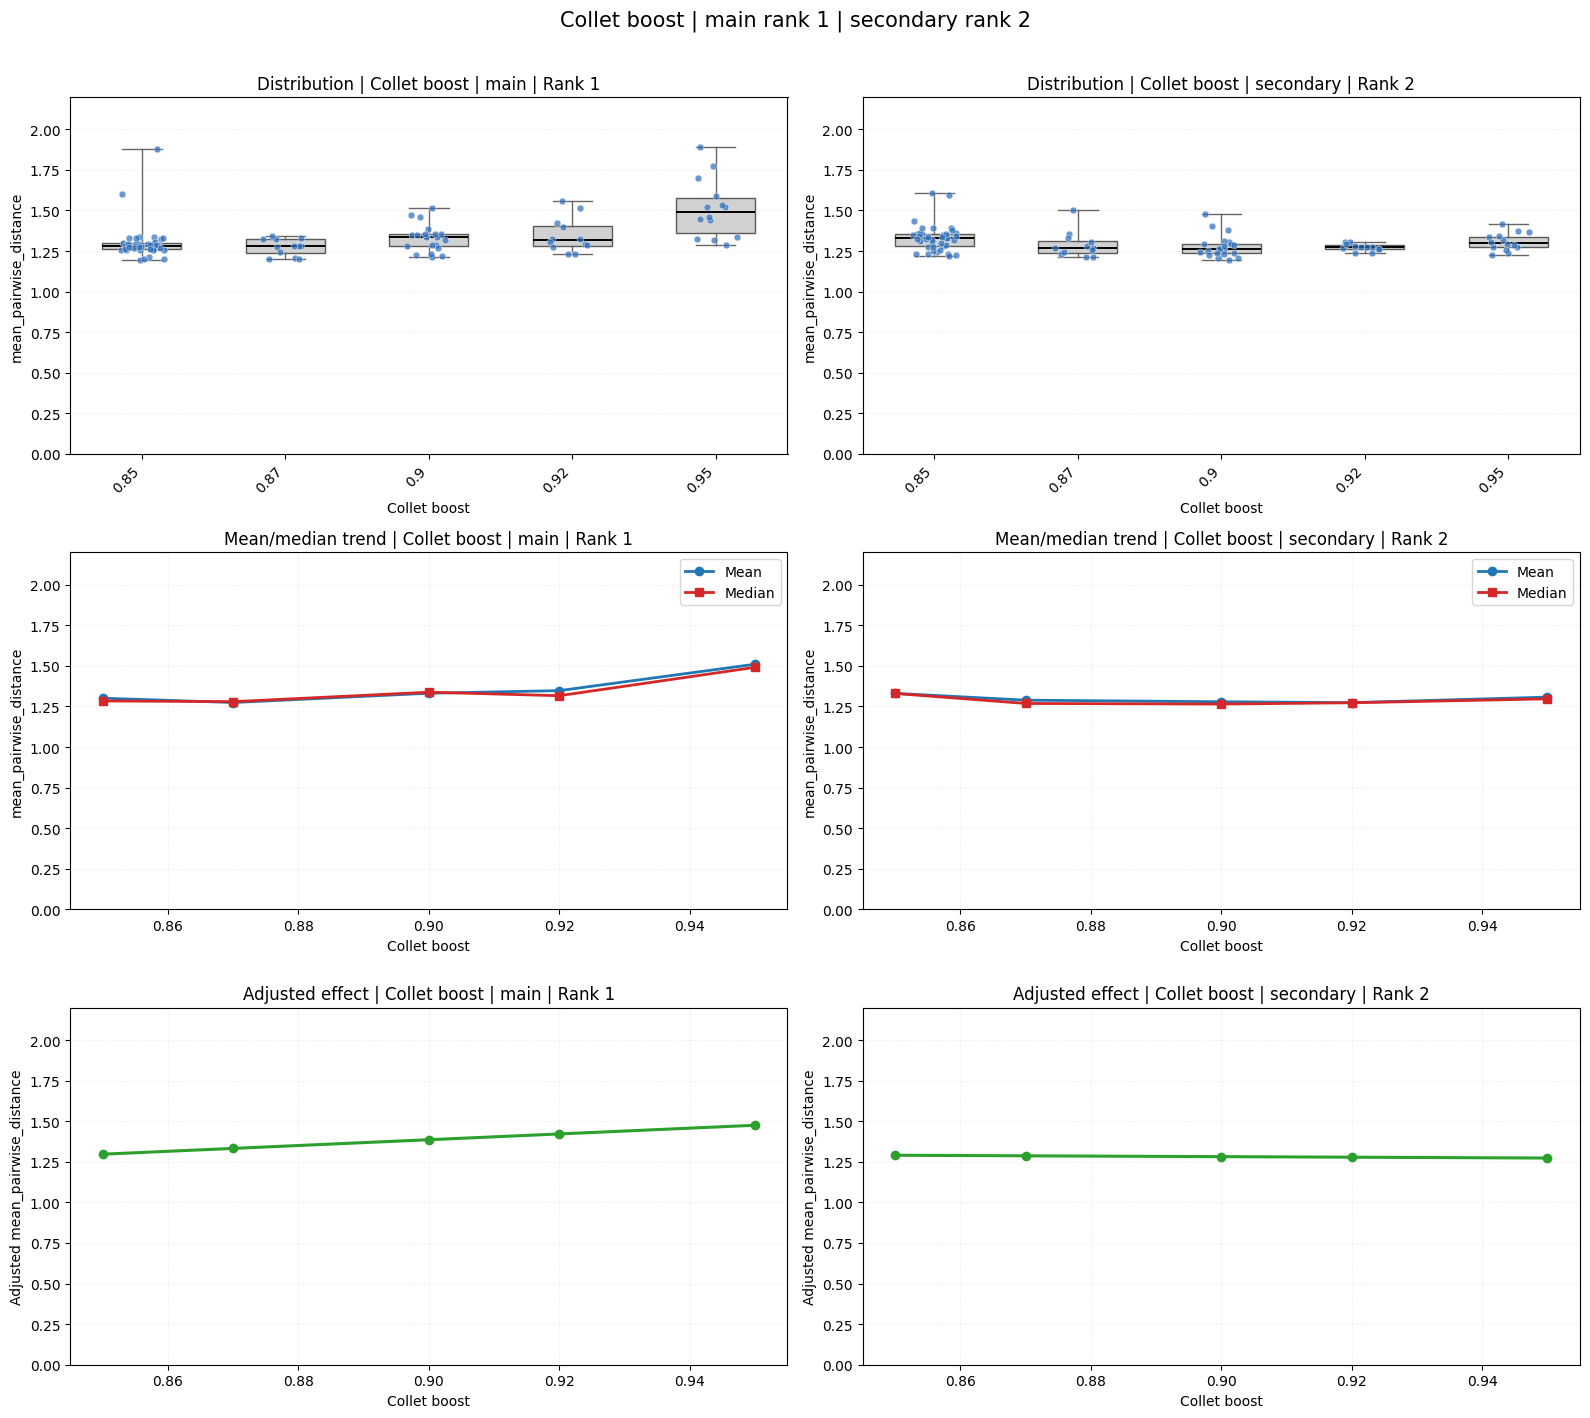

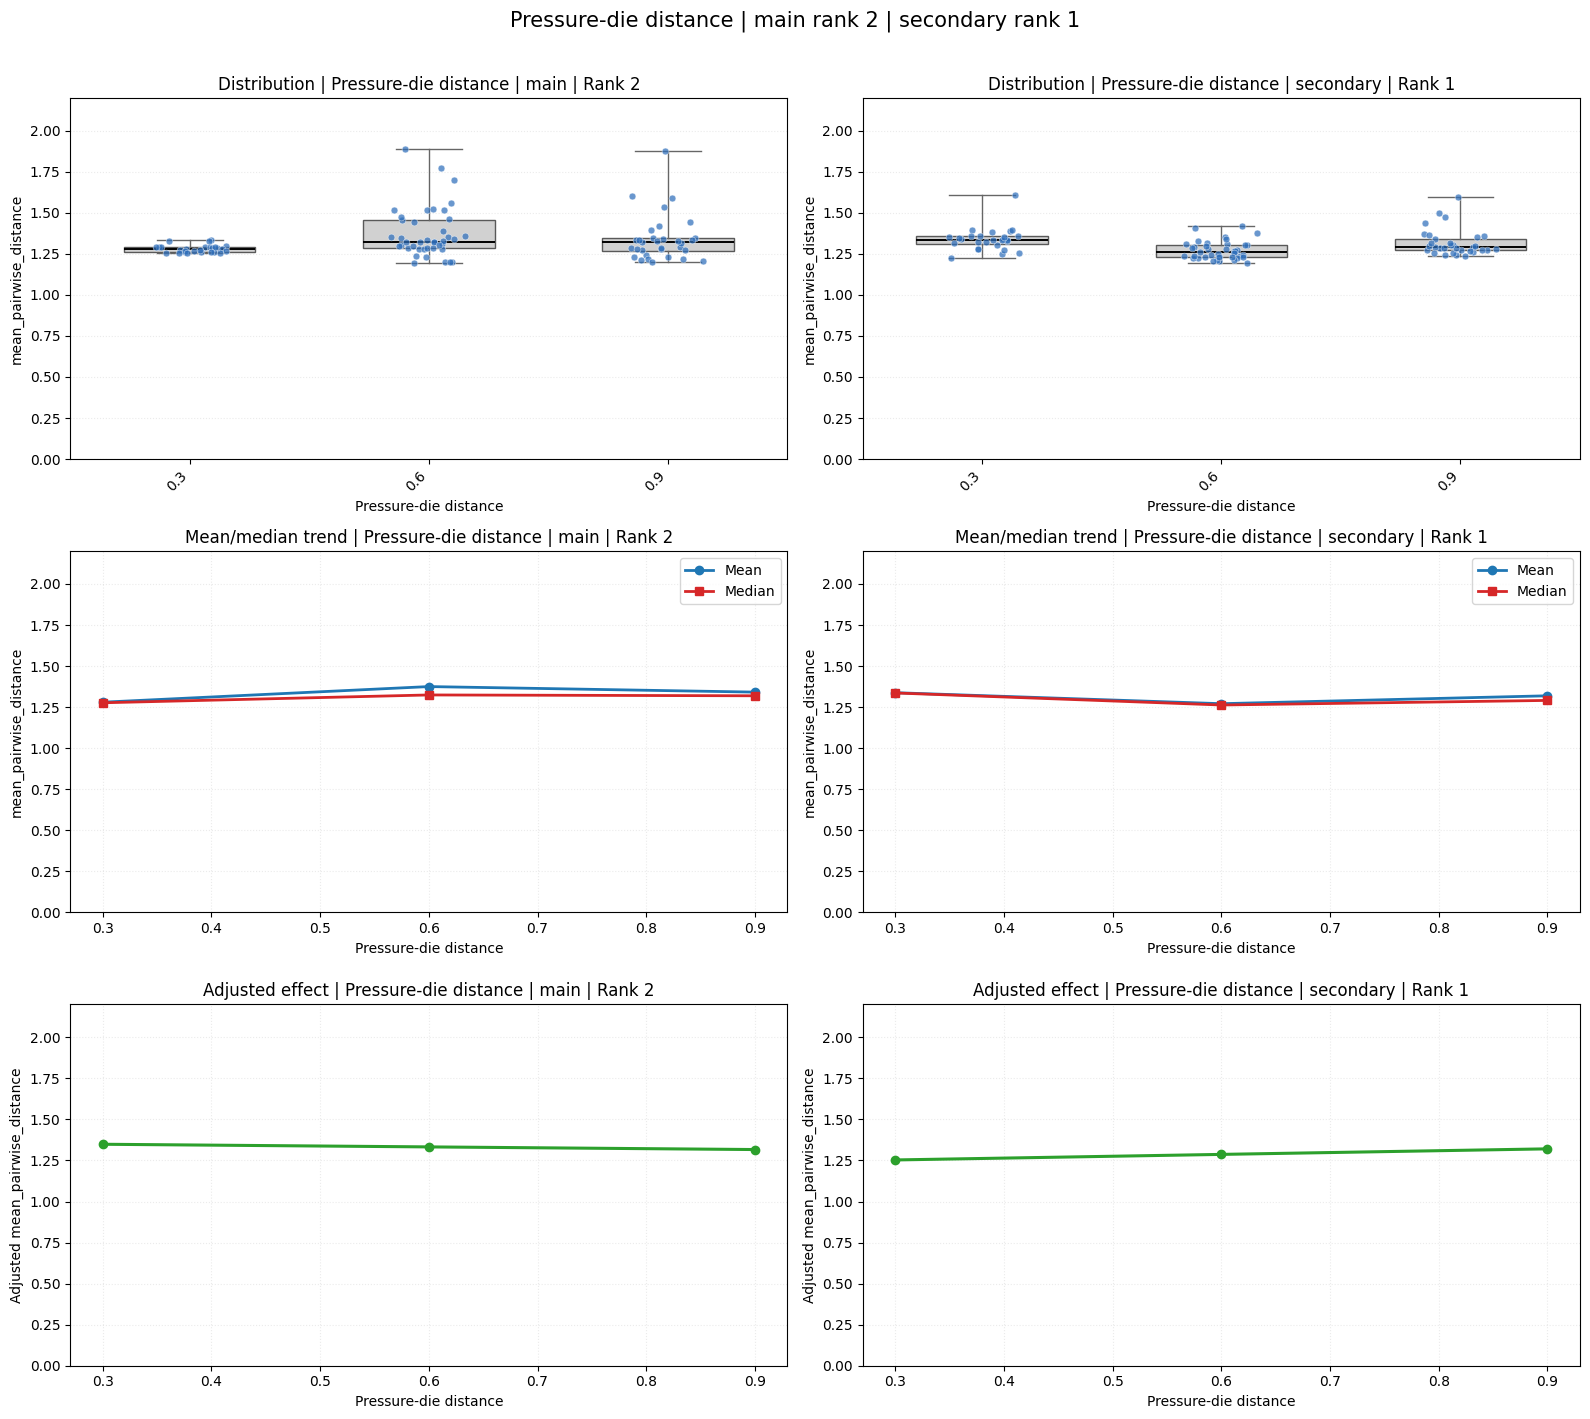

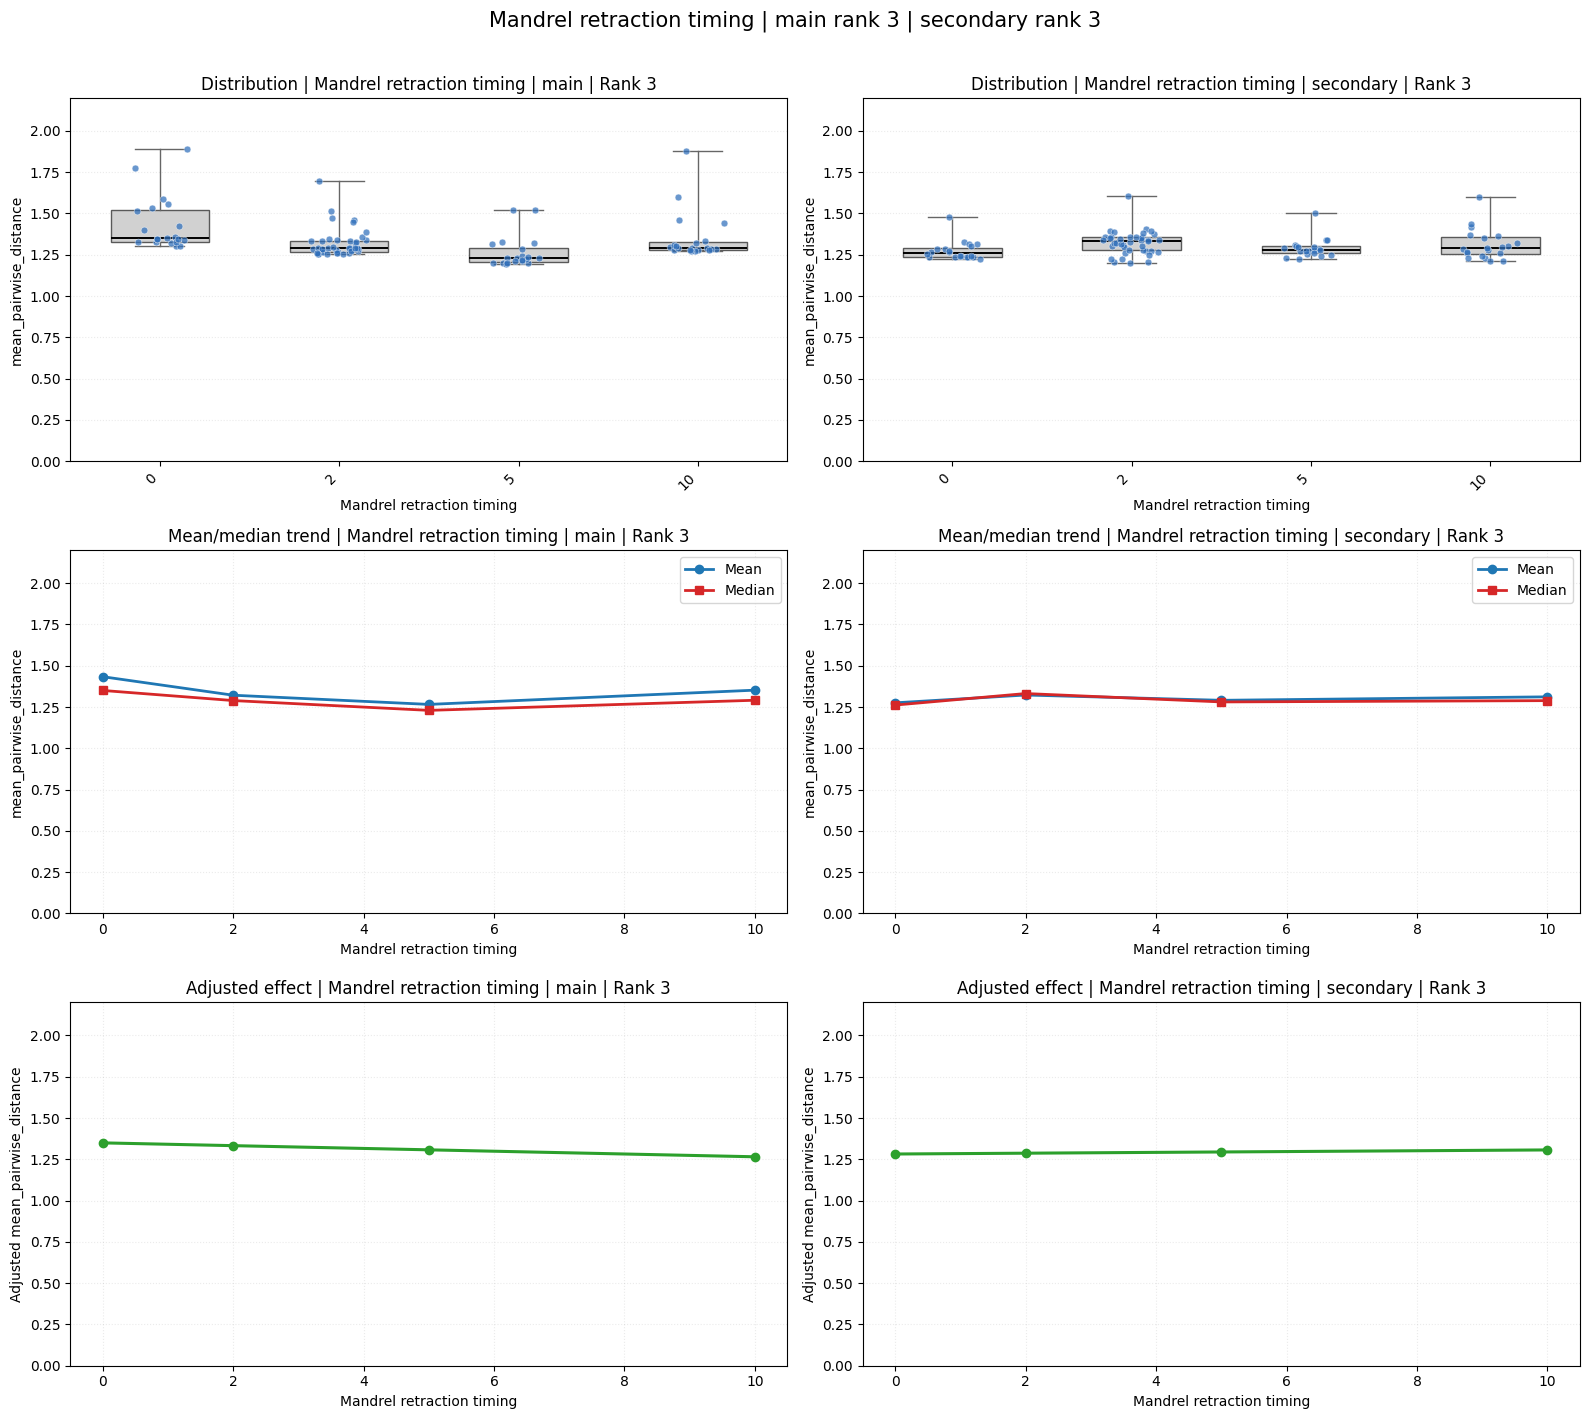

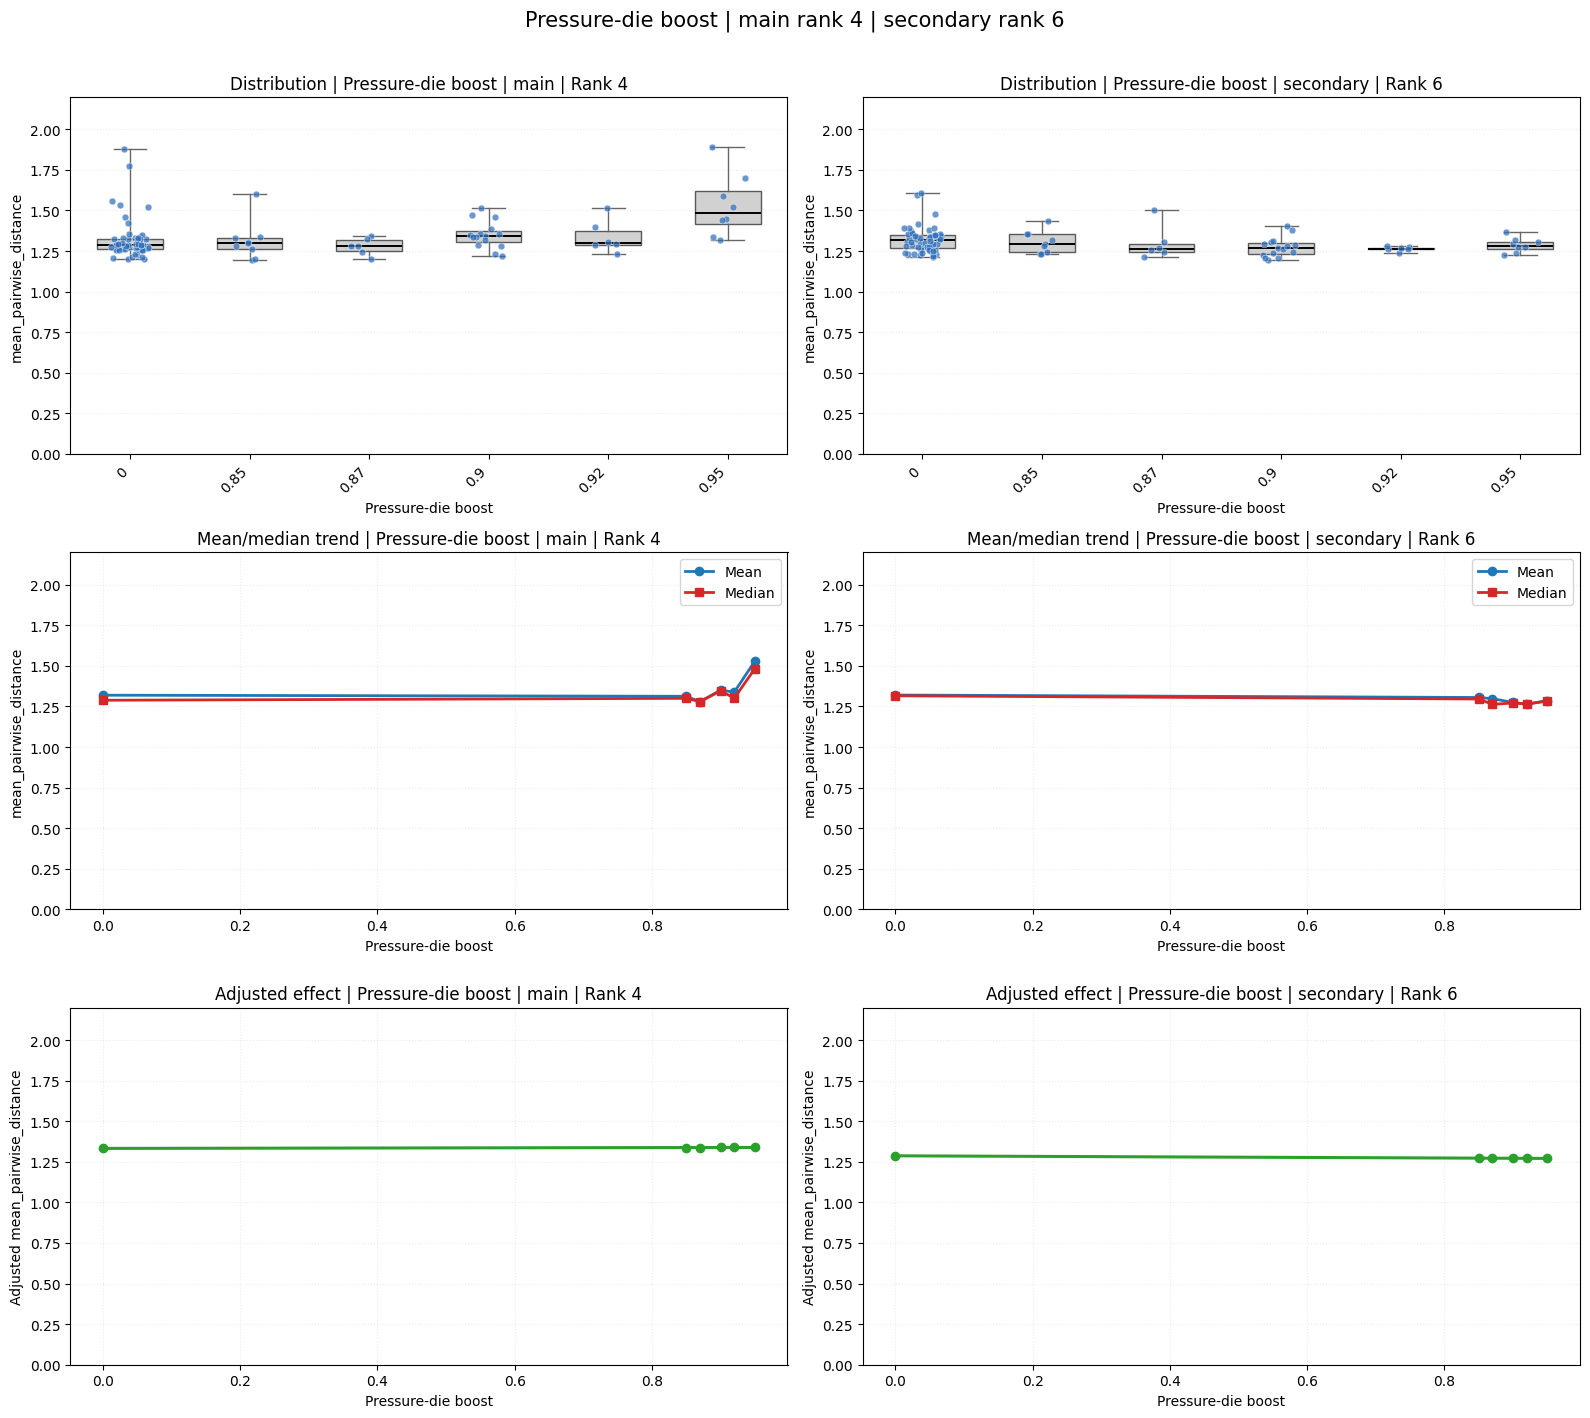

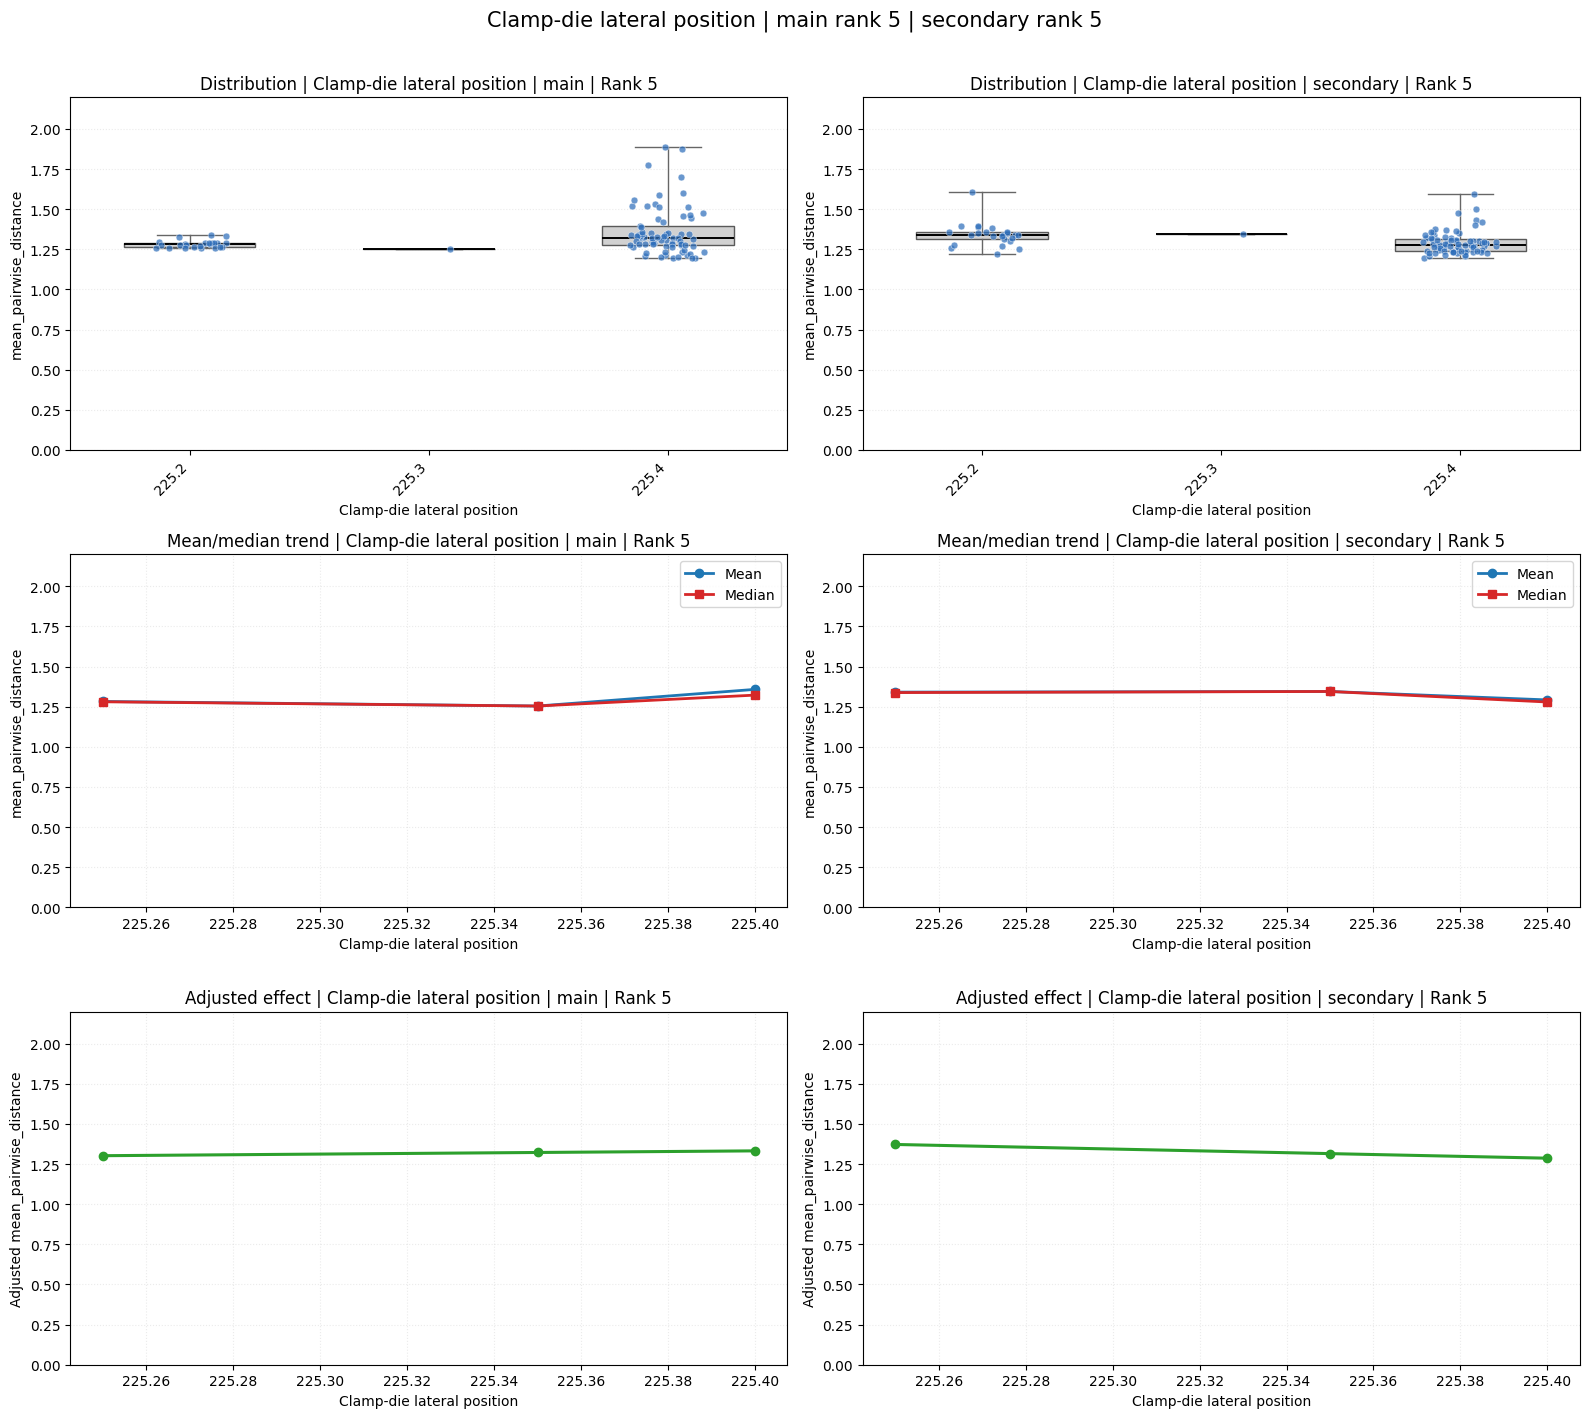

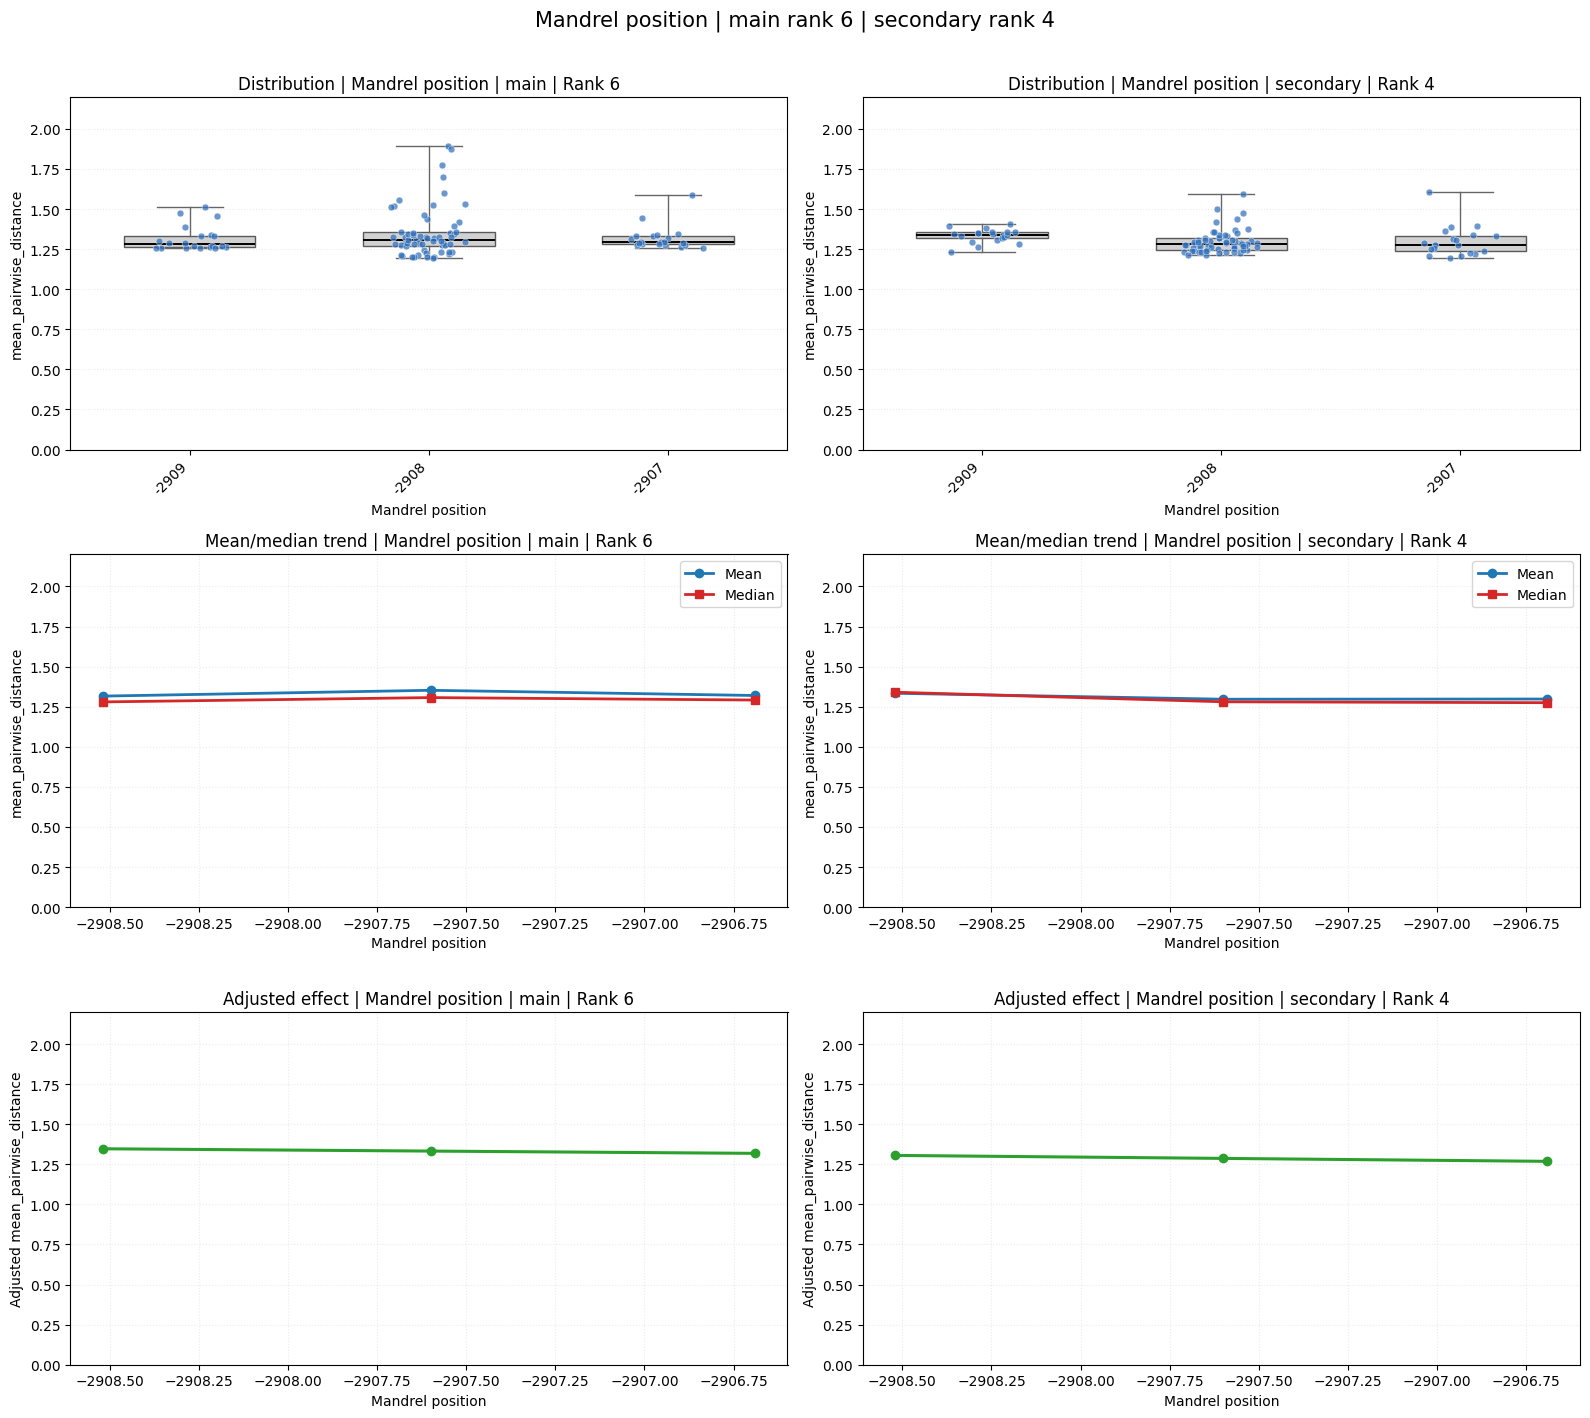

In [16]:
extra_analysis_figures = {}

for feature_name in available_ranked_features:
    main_ranked_features_df, _, feature_column, rank_column, _ = (
        select_ranked_features(
            ranking_data=ranking_df,
            geometry_type="main",
            top_n_features=None,
        )
    )

    secondary_ranked_features_df, _, _, _, _ = (
        select_ranked_features(
            ranking_data=ranking_df,
            geometry_type="secondary",
            top_n_features=None,
        )
    )

    main_rank = main_ranked_features_df.loc[
        main_ranked_features_df[feature_column].eq(feature_name),
        rank_column,
    ].iloc[0]

    secondary_rank = secondary_ranked_features_df.loc[
        secondary_ranked_features_df[feature_column].eq(feature_name),
        rank_column,
    ].iloc[0]

    main_plot_df, _ = build_axis_plot_data(
        feature_name=feature_name,
        geometry_type="main",
        distance_columns=[
            "Angle[degree]ORDistance[mm]",
            "Main-axis [mm]",
        ],
    )

    secondary_plot_df, _ = build_axis_plot_data(
        feature_name=feature_name,
        geometry_type="secondary",
        distance_columns=[
            "Angle[degree]ORDistance[mm]",
            "Secondary-axis [mm]",
        ],
    )

    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(16, 14),
    )

    plot_metric_distribution_by_feature_value(
        plot_data=main_plot_df,
        feature_name=feature_name,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
        geometry_type=f"main | Rank {int(main_rank)}",
        ax=axes[0, 0],
    )

    plot_metric_distribution_by_feature_value(
        plot_data=secondary_plot_df,
        feature_name=feature_name,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
        geometry_type=f"secondary | Rank {int(secondary_rank)}",
        ax=axes[0, 1],
    )

    plot_metric_mean_median_trend(
        plot_data=main_plot_df,
        feature_name=feature_name,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
        geometry_type=f"main | Rank {int(main_rank)}",
        ax=axes[1, 0],
    )

    plot_metric_mean_median_trend(
        plot_data=secondary_plot_df,
        feature_name=feature_name,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
        geometry_type=f"secondary | Rank {int(secondary_rank)}",
        ax=axes[1, 1],
    )

    plot_adjusted_effect_by_feature_value(
        plot_data=main_plot_df,
        bending_data=bending_setup_df,
        feature_name=feature_name,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
        group_column=bending_group_column,
        geometry_type=f"main | Rank {int(main_rank)}",
        ax=axes[2, 0],
    )

    plot_adjusted_effect_by_feature_value(
        plot_data=secondary_plot_df,
        bending_data=bending_setup_df,
        feature_name=feature_name,
        metric_name=PAIRWISE_DISTANCE_COLUMN,
        group_column=bending_group_column,
        geometry_type=f"secondary | Rank {int(secondary_rank)}",
        ax=axes[2, 1],
    )

    fig.suptitle(
        f"{feature_name} | main rank {int(main_rank)} | secondary rank {int(secondary_rank)}",
        fontsize=15,
        y=1.01,
    )

    fig.tight_layout()

    extra_analysis_figures[feature_name] = fig

    plt.show()

STD based

In [17]:
def build_axis_std_plot_data(
    feature_name: str,
    geometry_type: str,
    distance_columns: list[str],
):
    ranked_features_axis_df, _, feature_column, rank_column, _ = (
        select_ranked_features(
            ranking_data=ranking_df,
            geometry_type=geometry_type,
            top_n_features=None,
        )
    )

    feature_rank = ranked_features_axis_df.loc[
        ranked_features_axis_df[feature_column].eq(feature_name),
        rank_column,
    ].iloc[0]

    group_std_df = compute_group_std_distance(
        dataframe=experiment_df,
        group_column=experiment_group_column,
        distance_columns=distance_columns,
        standardize=True,
    )

    group_std_df = group_std_df.rename(
        columns={
            experiment_group_column: bending_group_column,
        }
    )

    feature_plot_df = build_feature_plot_dataframe(
        feature_name=feature_name,
        bending_data=bending_setup_df,
        group_distance_data=group_std_df,
        bending_group_name=bending_group_column,
        metric_name=STD_DISTANCE_COLUMN,
    )

    return feature_plot_df, feature_rank

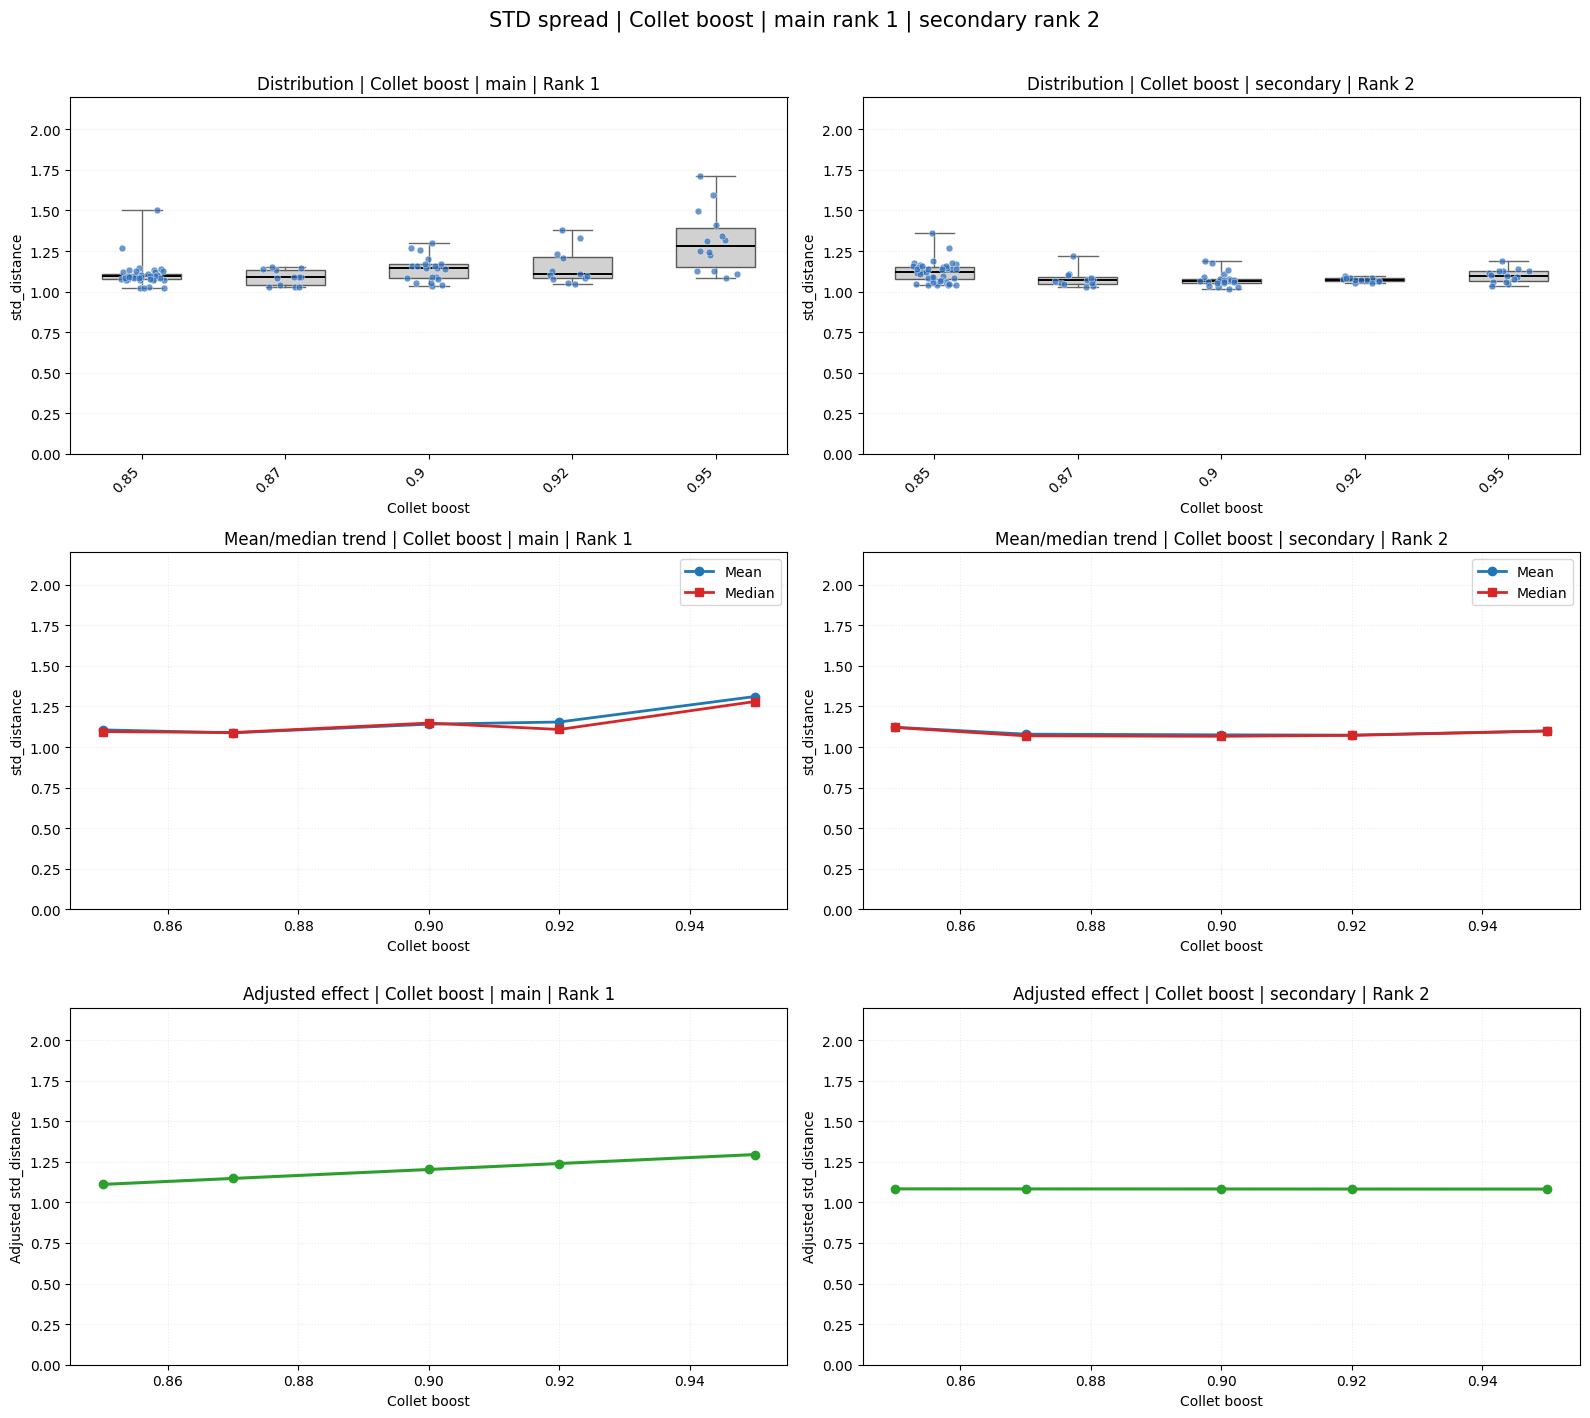

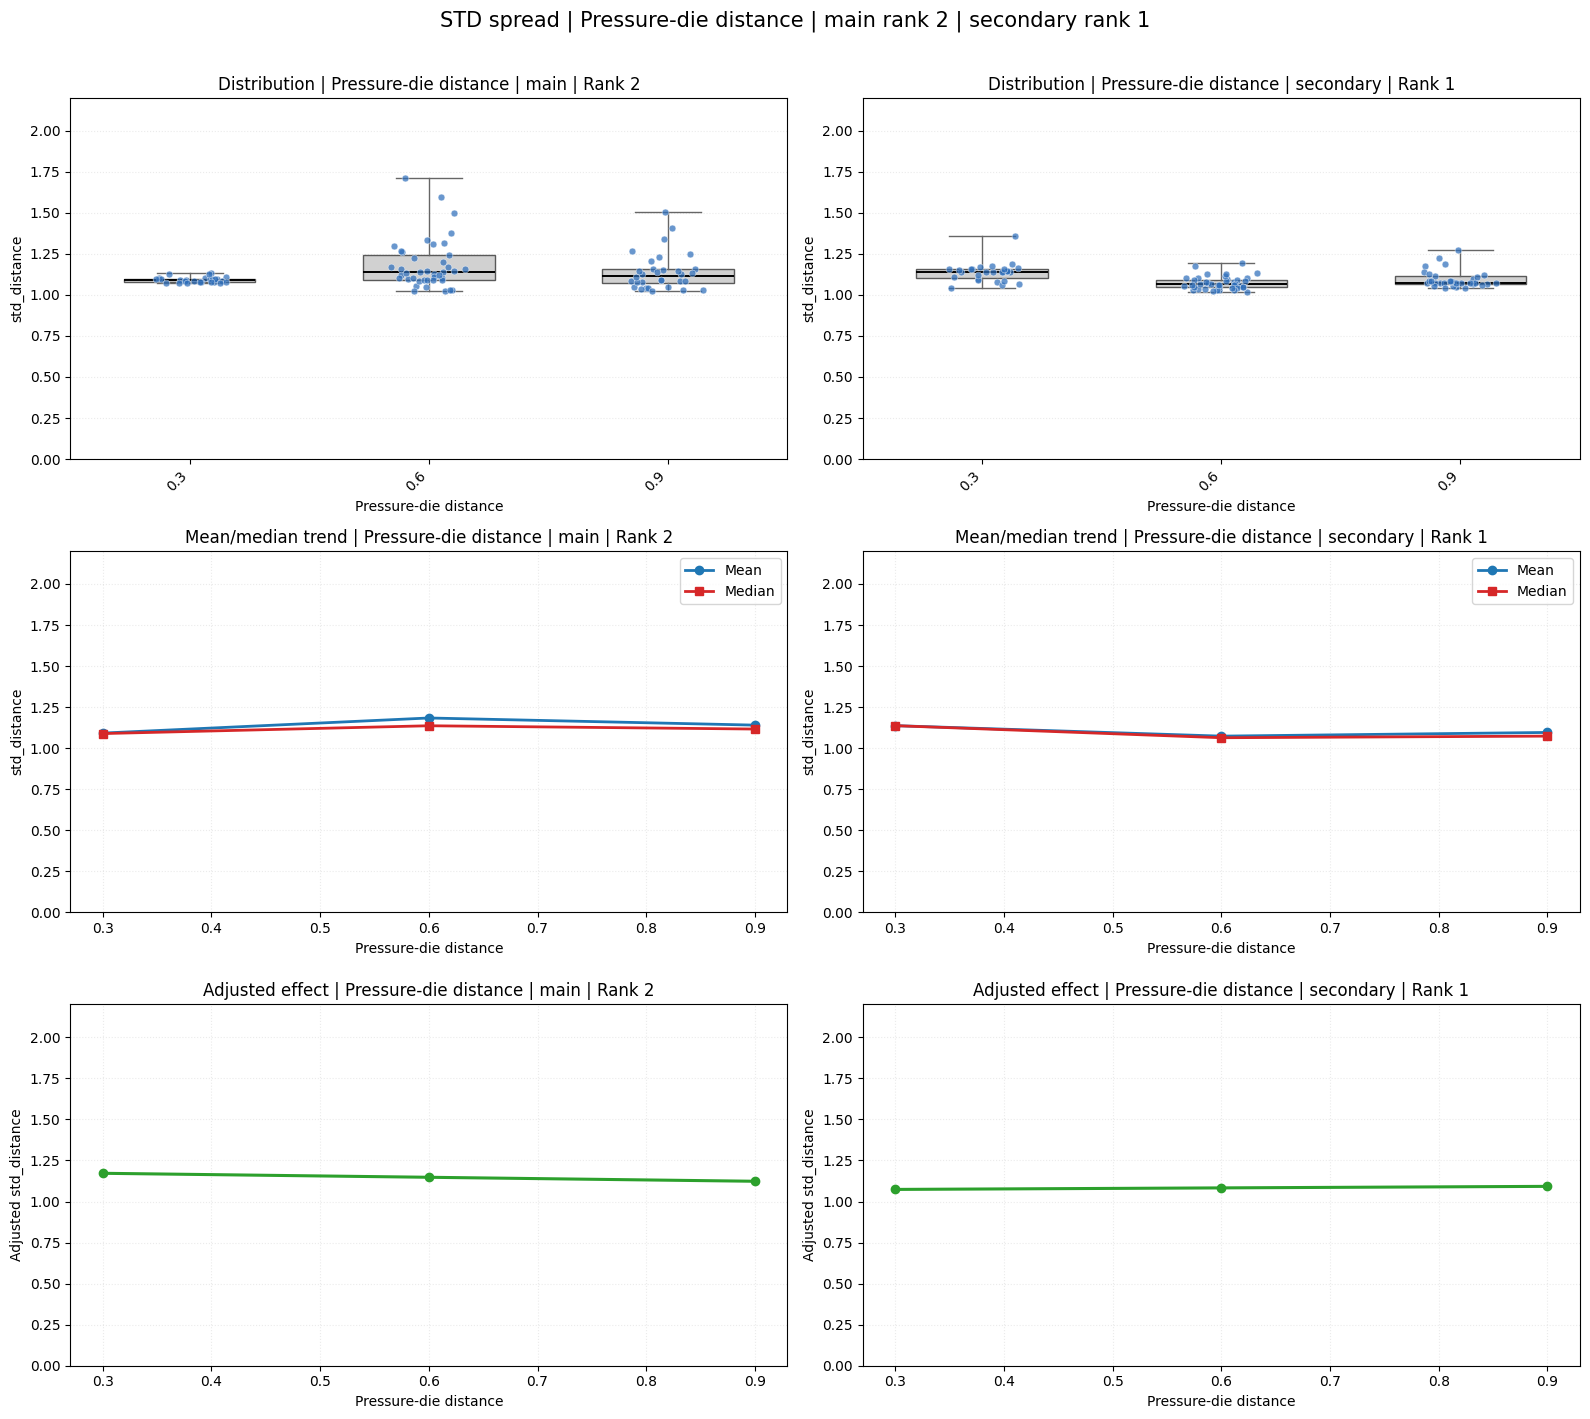

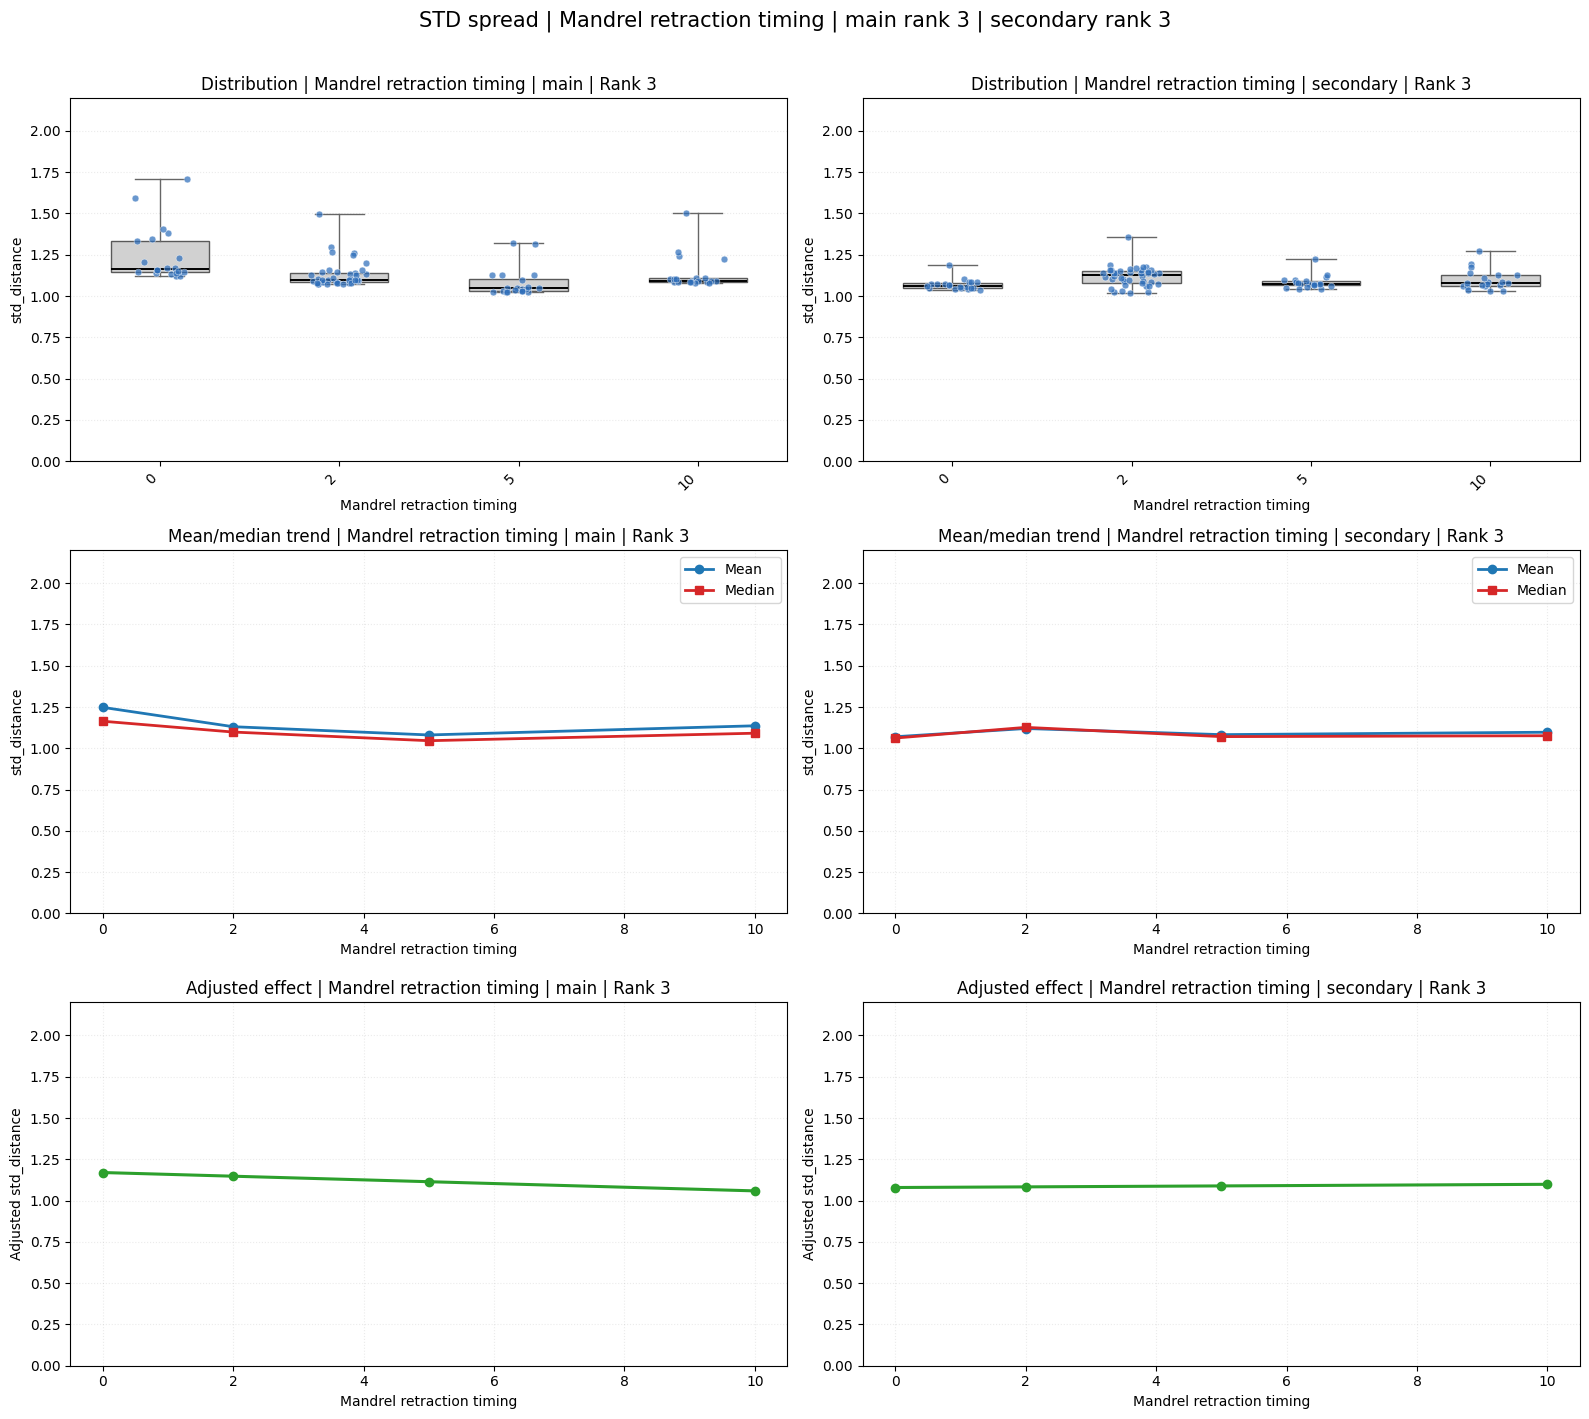

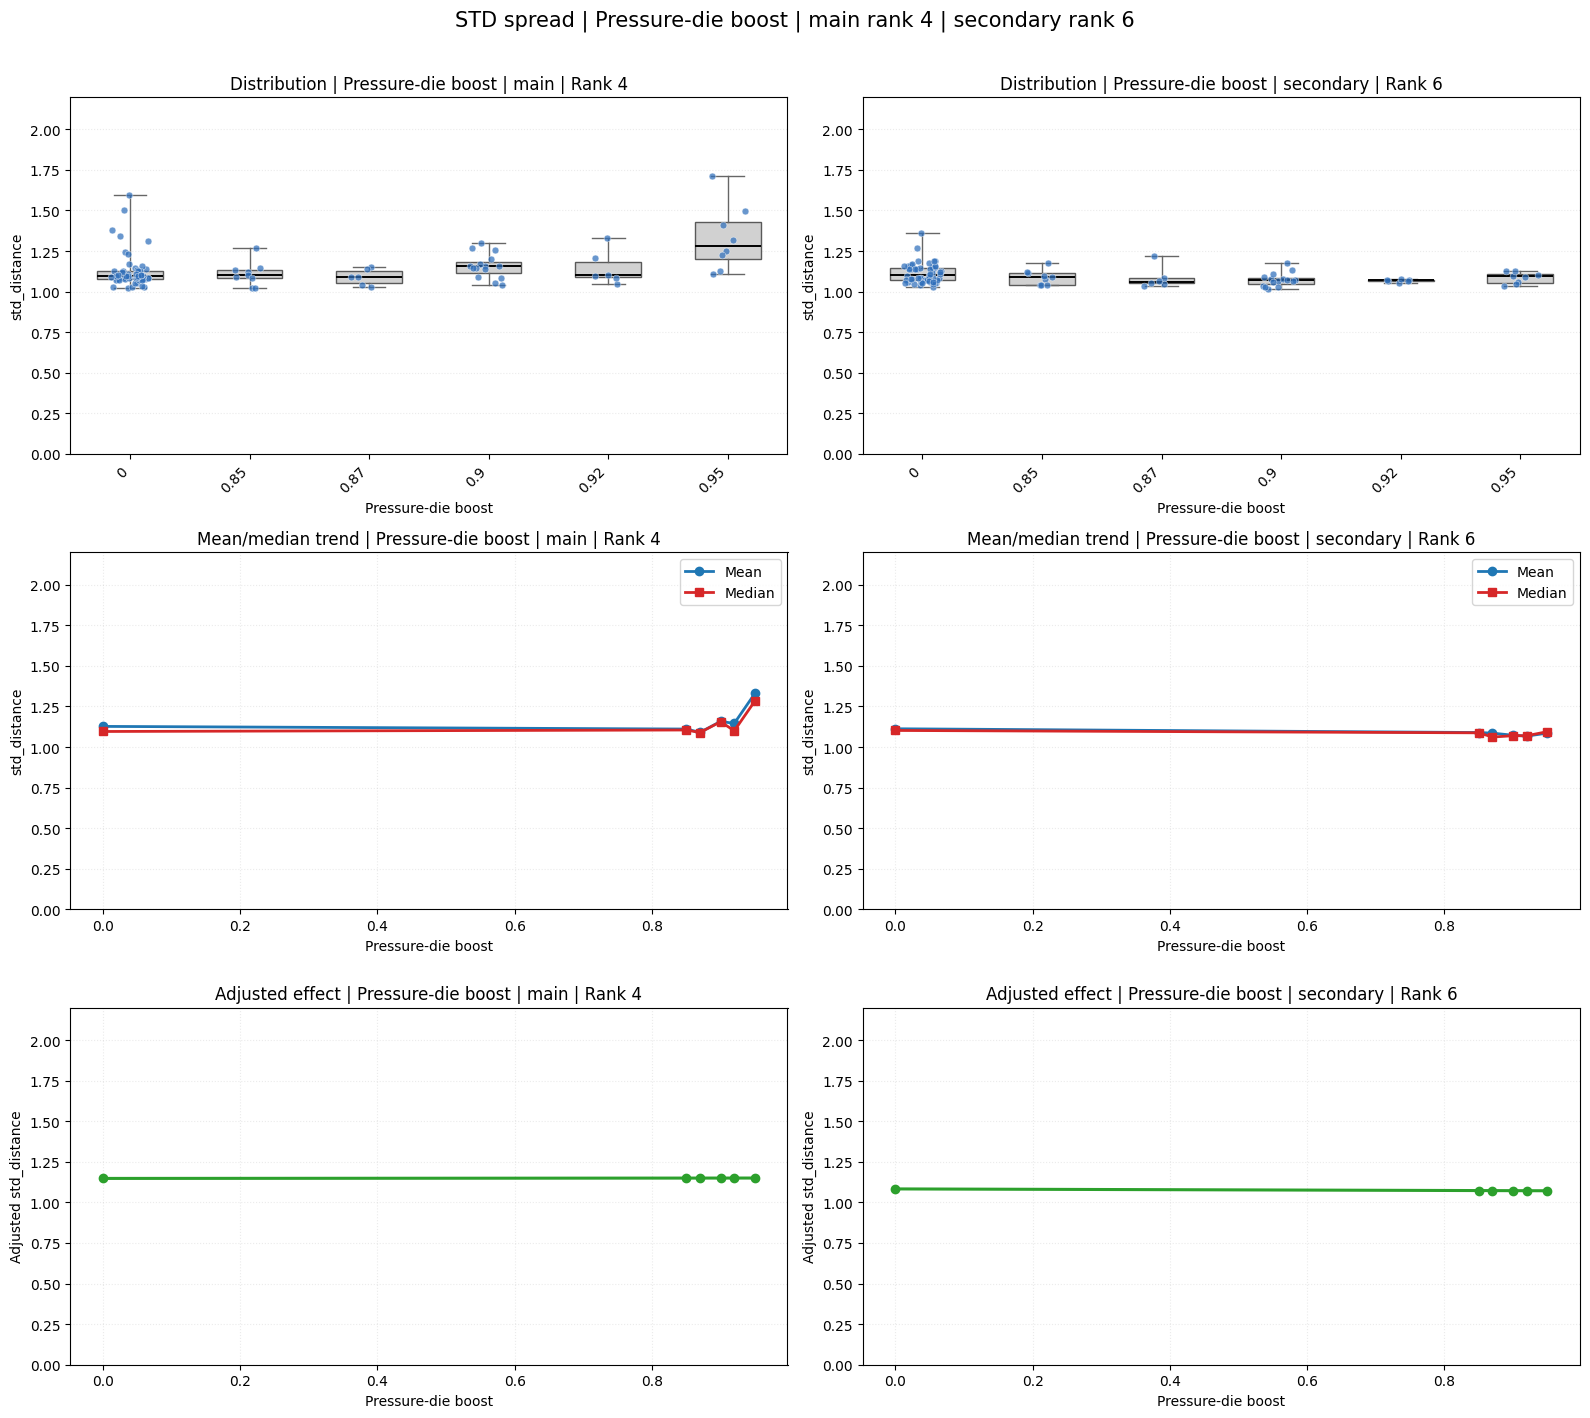

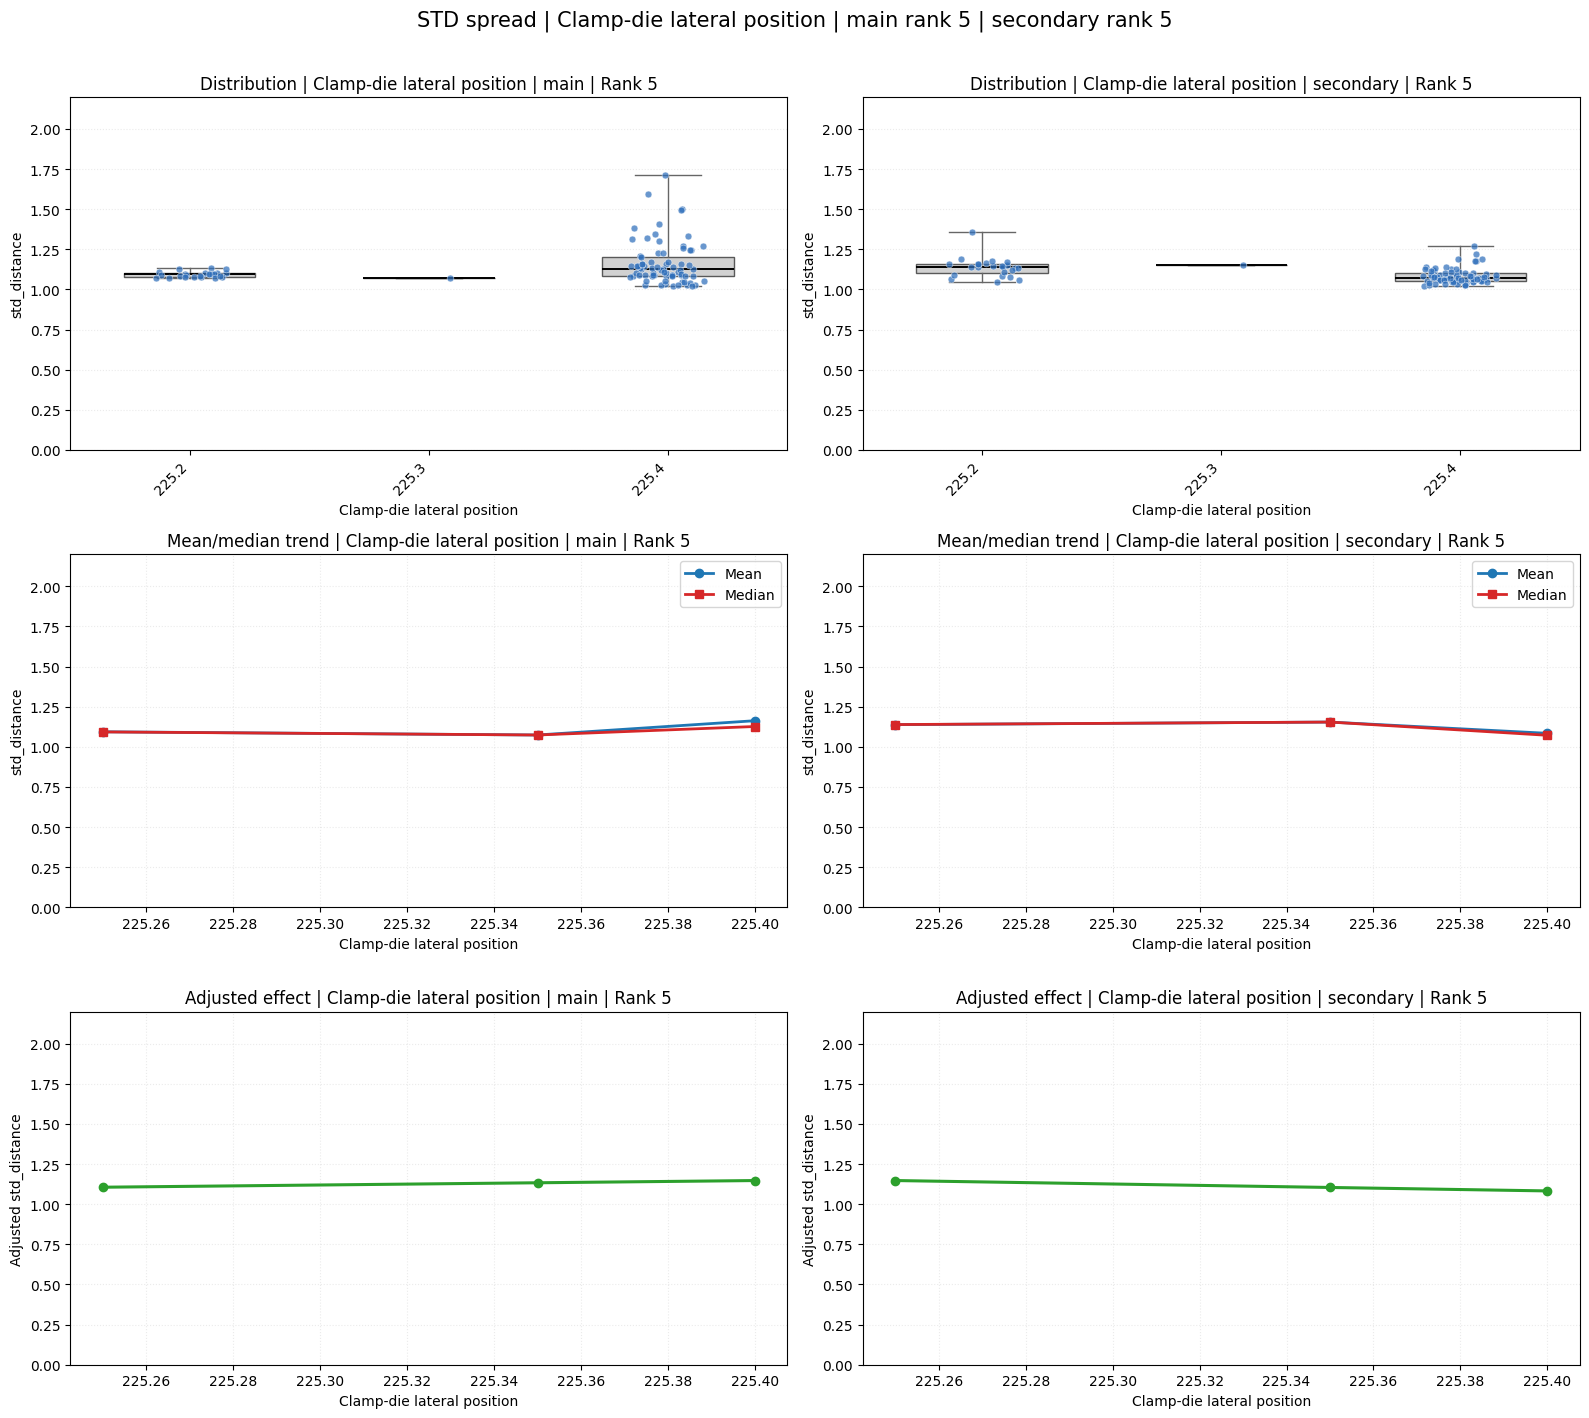

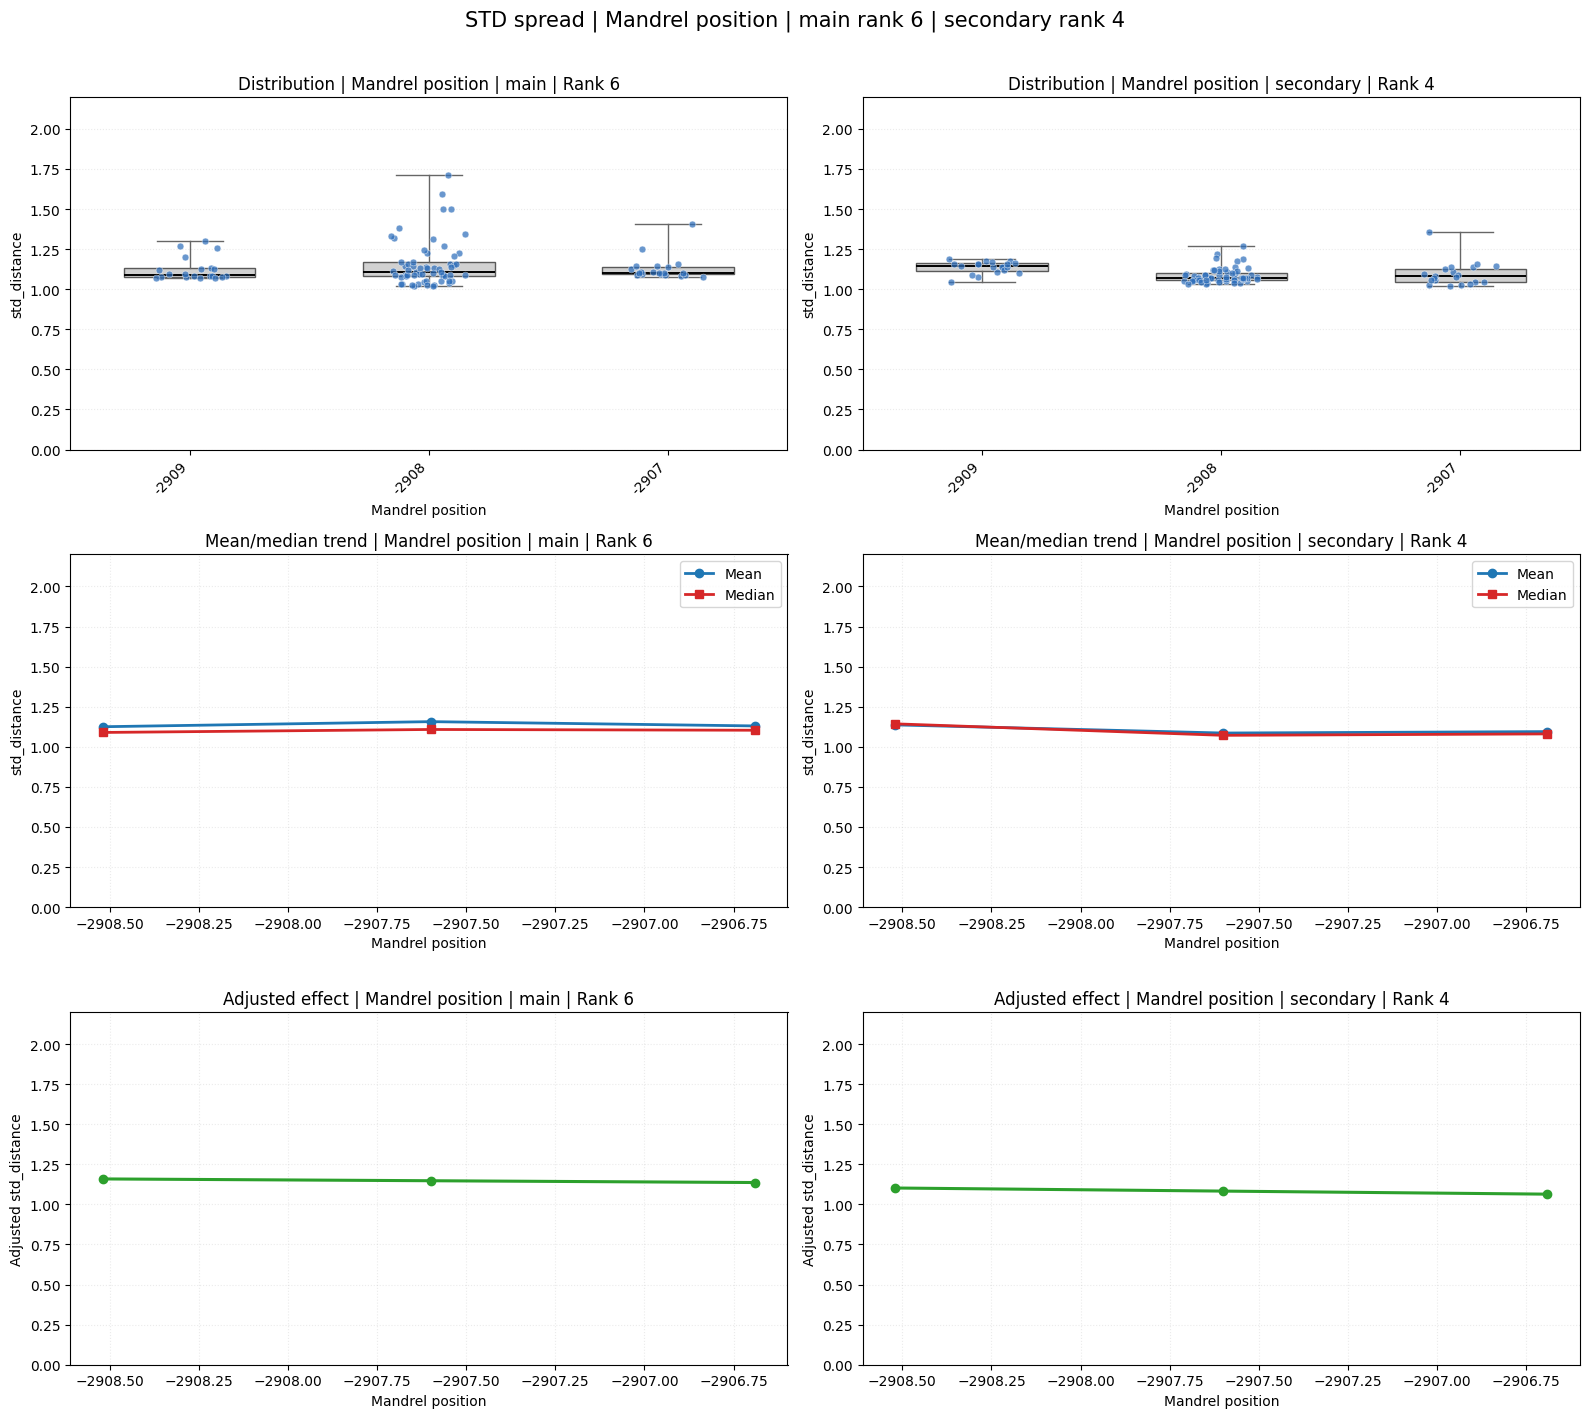

In [18]:
std_analysis_figures = {}

for feature_name in available_ranked_features:
    main_plot_df, main_rank = build_axis_std_plot_data(
        feature_name=feature_name,
        geometry_type="main",
        distance_columns=[
            "Angle[degree]ORDistance[mm]",
            "Main-axis [mm]",
        ],
    )

    secondary_plot_df, secondary_rank = build_axis_std_plot_data(
        feature_name=feature_name,
        geometry_type="secondary",
        distance_columns=[
            "Angle[degree]ORDistance[mm]",
            "Secondary-axis [mm]",
        ],
    )

    fig, axes = plt.subplots(
        nrows=3,
        ncols=2,
        figsize=(16, 14),
    )

    plot_metric_distribution_by_feature_value(
        plot_data=main_plot_df,
        feature_name=feature_name,
        metric_name=STD_DISTANCE_COLUMN,
        geometry_type=f"main | Rank {int(main_rank)}",
        ax=axes[0, 0],
    )

    plot_metric_distribution_by_feature_value(
        plot_data=secondary_plot_df,
        feature_name=feature_name,
        metric_name=STD_DISTANCE_COLUMN,
        geometry_type=f"secondary | Rank {int(secondary_rank)}",
        ax=axes[0, 1],
    )

    plot_metric_mean_median_trend(
        plot_data=main_plot_df,
        feature_name=feature_name,
        metric_name=STD_DISTANCE_COLUMN,
        geometry_type=f"main | Rank {int(main_rank)}",
        ax=axes[1, 0],
    )

    plot_metric_mean_median_trend(
        plot_data=secondary_plot_df,
        feature_name=feature_name,
        metric_name=STD_DISTANCE_COLUMN,
        geometry_type=f"secondary | Rank {int(secondary_rank)}",
        ax=axes[1, 1],
    )

    plot_adjusted_effect_by_feature_value(
        plot_data=main_plot_df,
        bending_data=bending_setup_df,
        feature_name=feature_name,
        metric_name=STD_DISTANCE_COLUMN,
        group_column=bending_group_column,
        geometry_type=f"main | Rank {int(main_rank)}",
        ax=axes[2, 0],
    )

    plot_adjusted_effect_by_feature_value(
        plot_data=secondary_plot_df,
        bending_data=bending_setup_df,
        feature_name=feature_name,
        metric_name=STD_DISTANCE_COLUMN,
        group_column=bending_group_column,
        geometry_type=f"secondary | Rank {int(secondary_rank)}",
        ax=axes[2, 1],
    )

    fig.suptitle(
        f"STD spread | {feature_name} | main rank {int(main_rank)} | secondary rank {int(secondary_rank)}",
        fontsize=15,
        y=1.01,
    )

    fig.tight_layout()

    std_analysis_figures[feature_name] = fig

    plt.show()

# Hyperparameter Tuning

In [19]:
# from utils.experiments.qrf_pipeline import load_config
# from utils.experiments.hyper_parameter_tuning import HyperParameterTuning

# CONFIG_PATH = QRF_ROOT / "configs" / "tree_convergence_ranked.yaml"

# config = load_config(
#     config_path=CONFIG_PATH,
#     project_root=REPO_ROOT,
# )

# tuner = HyperParameterTuning(
#     config=config,
#     cv_splits=5,

#     # Coordinate-search stopping
#     greedy_patience=2,
#     max_coordinate_passes=4,

#     # Main validation objective tolerances
#     coverage_target=85.0,
#     curve_distance_tolerance=0.01,
#     trend_tolerance=0.01,
#     coverage_tolerance=1.0,
#     pinaw_tolerance=0.01,

#     # OOB tie-break tolerances
#     oob_curve_distance_tolerance=0.01,
#     oob_trend_tolerance=0.01,
# )

# results_df = tuner.run()

In [20]:
# import pandas as pd

# various_splits = pd.read_parquet(
#     QRF_ROOT
#     / "data"
#     / "various_splits.parquet"
# )

# various_splits

In [21]:
# various_splits.columns

In [22]:
# various_splits[various_splits['qrf_rank_main'] == 2]

In [23]:
# various_splits[various_splits['qrf_rank_secondary'] == 2]

# Train vs Test Distribution

In [24]:
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.covariance import LedoitWolf
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

try:
    import umap
except ImportError:
    umap = None


SETUP_ID_COLUMNS = {
    bending_group_column,
    "Experiment_Number",
    "Tube_numbers",
}


def parse_group_ids(value) -> list:
    """
    Convert stored group-ID representations into a Python list.

    Supports:
    - list / tuple / set / ndarray / Series
    - string representations such as "[1, 2, 3]"
    - scalar group IDs
    """
    if isinstance(
        value,
        (
            list,
            tuple,
            set,
            np.ndarray,
            pd.Series,
        ),
    ):
        return list(value)

    if value is None:
        return []

    try:
        if pd.isna(value):
            return []
    except (TypeError, ValueError):
        pass

    if isinstance(value, str):
        stripped_value = value.strip()

        if not stripped_value:
            return []

        try:
            parsed_value = ast.literal_eval(
                stripped_value
            )
        except (ValueError, SyntaxError):
            return [value]

        return parse_group_ids(parsed_value)

    return [value]


setup_feature_columns = []

for column in bending_setup_df.columns:
    if column in SETUP_ID_COLUMNS:
        continue

    numeric_values = pd.to_numeric(
        bending_setup_df[column],
        errors="coerce",
    )

    if numeric_values.notna().all():
        setup_feature_columns.append(column)


if not setup_feature_columns:
    raise ValueError(
        "No fully numeric bending-setup features were found."
    )


setup_feature_df = (
    bending_setup_df[
        [bending_group_column]
        + setup_feature_columns
    ]
    .copy()
)

setup_feature_df[setup_feature_columns] = (
    setup_feature_df[
        setup_feature_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)

setup_feature_df = (
    setup_feature_df
    .dropna(
        subset=setup_feature_columns,
    )
    .drop_duplicates(
        subset=[bending_group_column],
        keep="first",
    )
    .set_index(
        bending_group_column
    )
    .sort_index()
)


if len(setup_feature_df) < 4:
    raise ValueError(
        "At least four bending setup groups are required."
    )


setup_group_ids = (
    setup_feature_df
    .index
    .to_numpy()
)


# print(
#     f"Using {len(setup_feature_columns)} setup features "
#     f"for {len(setup_feature_df)} bending setup groups."
# )

# print(
#     "Setup features:",
#     setup_feature_columns,
# )

In [25]:
def build_setup_embedding_dataframe(
    random_state: int = 42,
) -> pd.DataFrame:
    """
    Build global setup-space embeddings for visualization.

    Important:
    These global embeddings are descriptive visualizations only.
    They are not used for quantitative train/test distance metrics.
    """
    global_scaler = StandardScaler()

    setup_feature_scaled = (
        global_scaler.fit_transform(
            setup_feature_df[
                setup_feature_columns
            ]
        )
    )

    n_samples = len(
        setup_feature_df
    )

    pca_model = PCA(
        n_components=4,
        random_state=random_state,
    )

    pca_coordinates = (
        pca_model.fit_transform(
            setup_feature_scaled
        )
    )

    embedding_df = pd.DataFrame(
        {
            "Group_ID": setup_group_ids,
            "PCA 1": pca_coordinates[:, 0],
            "PCA 2": pca_coordinates[:, 1],
            "PCA 3": pca_coordinates[:, 2],
            "PCA 4": pca_coordinates[:, 3],
        }
    )

    explained_variance_ratio = (
        pca_model.explained_variance_ratio_
    )

    embedding_df.attrs[
        "pca_explained_variance_ratio"
    ] = explained_variance_ratio

    perplexity = min(
        30.0,
        max(
            2.0,
            (n_samples - 1) / 3.0,
        ),
        n_samples - 1.0,
    )

    tsne_coordinates = TSNE(
        n_components=2,
        perplexity=perplexity,
        init="pca",
        learning_rate="auto",
        random_state=random_state,
    ).fit_transform(
        setup_feature_scaled
    )

    embedding_df[
        "t-SNE 1"
    ] = tsne_coordinates[:, 0]

    embedding_df[
        "t-SNE 2"
    ] = tsne_coordinates[:, 1]

    if (
        umap is not None
        and n_samples >= 4
    ):
        n_neighbors = min(
            15,
            n_samples - 1,
        )

        umap_coordinates = umap.UMAP(
            n_components=2,
            n_neighbors=n_neighbors,
            min_dist=0.1,
            random_state=random_state,
        ).fit_transform(
            setup_feature_scaled
        )

        embedding_df[
            "UMAP 1"
        ] = umap_coordinates[:, 0]

        embedding_df[
            "UMAP 2"
        ] = umap_coordinates[:, 1]

    return embedding_df


setup_embedding_df = (
    build_setup_embedding_dataframe()
)

pca_variance = setup_embedding_df.attrs[
    "pca_explained_variance_ratio"
]

print(
    "PCA explained variance: "
    f"PC1={pca_variance[0]:.3f}, "
    f"PC2={pca_variance[1]:.3f}, "
    f"total={pca_variance.sum():.3f}"
)

# display(
#     setup_embedding_df.head()
# )

PCA explained variance: PC1=0.386, PC2=0.143, total=0.802


Detected split axis column: None


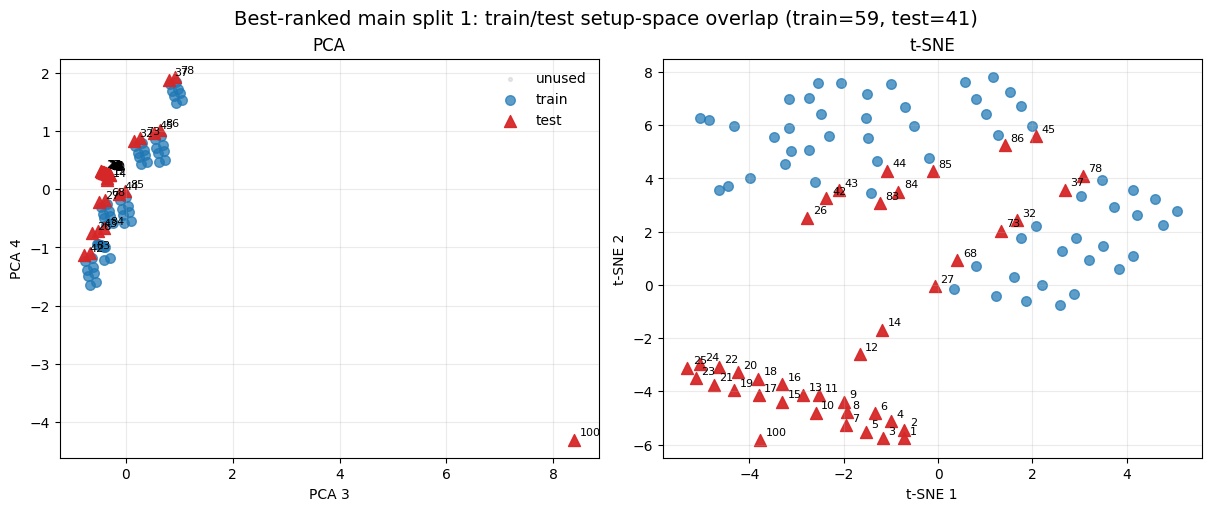

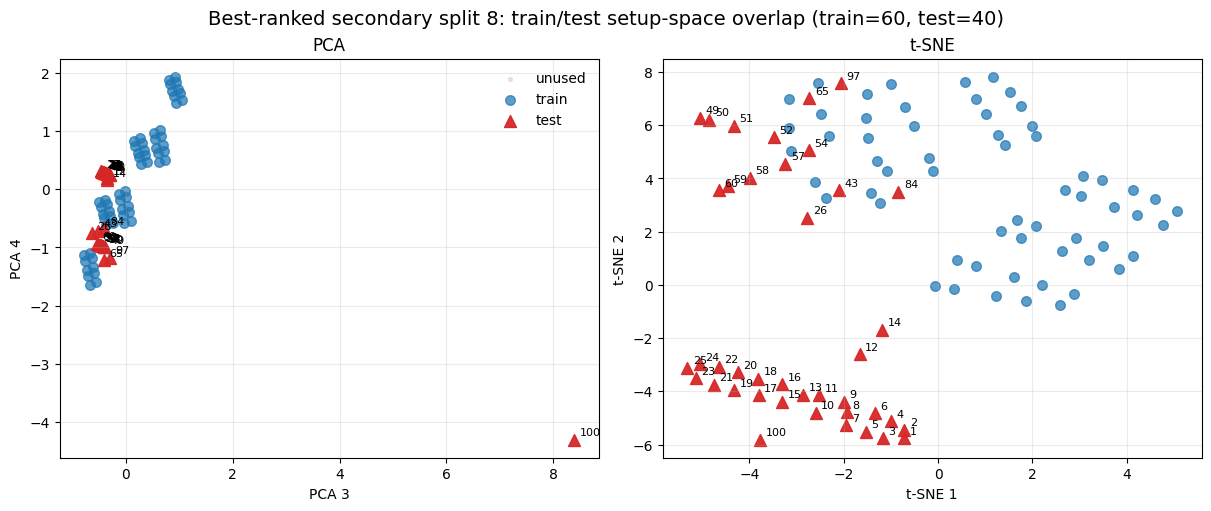

In [26]:
def detect_split_axis_column() -> str | None:
    """
    Detect the column used to distinguish main and secondary splits.
    """
    candidate_columns = [
        "axis",
        "target_axis",
        "geometry_type",
    ]

    for column in candidate_columns:
        if column in split_metadata_df.columns:
            return column

    return None


split_axis_column = (
    detect_split_axis_column()
)

print(
    "Detected split axis column:",
    split_axis_column,
)


def get_split_row(
    split_index: int,
    axis: str | None = None,
) -> pd.Series:
    """
    Retrieve exactly one split metadata row.
    """
    mask = split_metadata_df[
        "split_index"
    ].eq(split_index)

    if (
        axis is not None
        and split_axis_column is not None
    ):
        axis_values = (
            split_metadata_df[
                split_axis_column
            ]
            .astype(str)
            .str.lower()
        )

        mask &= axis_values.eq(
            str(axis).lower()
        )

    matching_rows = (
        split_metadata_df.loc[
            mask
        ]
    )

    if matching_rows.empty:
        raise KeyError(
            "No split metadata row was found for "
            f"split_index={split_index}, axis={axis}."
        )

    if len(matching_rows) > 1:
        raise ValueError(
            "Multiple split metadata rows were found for "
            f"split_index={split_index}, axis={axis}. "
            "Check the axis-column mapping."
        )

    return matching_rows.iloc[0]


def plot_split_setup_embeddings(
    split_index: int,
    axis: str,
):
    """
    Plot train/test membership in global PCA, t-SNE,
    and optionally UMAP setup-space embeddings.
    """
    split_row = get_split_row(
        split_index=split_index,
        axis=axis,
    )

    train_group_ids = set(
        parse_group_ids(
            split_row[
                "train_group_ids"
            ]
        )
    )

    test_group_ids = set(
        parse_group_ids(
            split_row[
                "test_group_ids"
            ]
        )
    )

    overlap = (
        train_group_ids
        & test_group_ids
    )

    if overlap:
        raise ValueError(
            "Train/test group overlap detected for "
            f"split {split_index}: {sorted(overlap)}"
        )

    plot_df = (
        setup_embedding_df.copy()
    )

    plot_df["membership"] = np.select(
        [
            plot_df[
                "Group_ID"
            ].isin(test_group_ids),

            plot_df[
                "Group_ID"
            ].isin(train_group_ids),
        ],
        [
            "test",
            "train",
        ],
        default="unused",
    )

    embedding_pairs = [
        (
            "PCA 3",
            "PCA 4",
            "PCA",
        ),
        (
            "t-SNE 1",
            "t-SNE 2",
            "t-SNE",
        ),
    ]

    if {
        "UMAP 1",
        "UMAP 2",
    }.issubset(
        plot_df.columns
    ):
        embedding_pairs.append(
            (
                "UMAP 1",
                "UMAP 2",
                "UMAP",
            )
        )

    fig, axes = plt.subplots(
        nrows=1,
        ncols=len(embedding_pairs),
        figsize=(
            6 * len(embedding_pairs),
            5,
        ),
        constrained_layout=True,
    )

    if len(embedding_pairs) == 1:
        axes = [axes]

    styles = {
        "unused": {
            "color": "#bdbdbd",
            "marker": ".",
            "label": "unused",
            "alpha": 0.35,
            "s": 30,
        },
        "train": {
            "color": "#1f77b4",
            "marker": "o",
            "label": "train",
            "alpha": 0.72,
            "s": 48,
        },
        "test": {
            "color": "#d62728",
            "marker": "^",
            "label": "test",
            "alpha": 0.95,
            "s": 74,
        },
    }

    for (
        ax,
        (
            x_column,
            y_column,
            embedding_name,
        ),
    ) in zip(
        axes,
        embedding_pairs,
    ):
        for membership in [
            "unused",
            "train",
            "test",
        ]:
            subset = plot_df.loc[
                plot_df[
                    "membership"
                ].eq(membership)
            ]

            ax.scatter(
                subset[x_column],
                subset[y_column],
                **styles[membership],
            )

        test_subset = plot_df.loc[
            plot_df[
                "membership"
            ].eq("test")
        ]

        for _, row in (
            test_subset.iterrows()
        ):
            ax.annotate(
                str(
                    row["Group_ID"]
                ),
                (
                    row[x_column],
                    row[y_column],
                ),
                xytext=(4, 3),
                textcoords="offset points",
                fontsize=8,
            )

        ax.set_title(
            embedding_name
        )
        ax.set_xlabel(
            x_column
        )
        ax.set_ylabel(
            y_column
        )
        ax.grid(
            True,
            alpha=0.25,
        )

    axes[0].legend(
        loc="best",
        frameon=False,
    )

    train_count = int(
        plot_df[
            "membership"
        ].eq("train").sum()
    )

    test_count = int(
        plot_df[
            "membership"
        ].eq("test").sum()
    )

    fig.suptitle(
        f"Best-ranked {axis} split {split_index}: "
        f"train/test setup-space overlap "
        f"(train={train_count}, test={test_count})",
        fontsize=14,
    )

    return fig, plot_df


best_main_split = (
    selected_splits_by_axis[
        "main"
    ]["top"][0]
)

best_secondary_split = (
    selected_splits_by_axis[
        "secondary"
    ]["top"][0]
)


main_embedding_figure, main_embedding_df = (
    plot_split_setup_embeddings(
        split_index=best_main_split,
        axis="main",
    )
)

plt.show()


secondary_embedding_figure, secondary_embedding_df = (
    plot_split_setup_embeddings(
        split_index=best_secondary_split,
        axis="secondary",
    )
)

plt.show()

,axis,split_index,train_group_count,test_group_count,mahalanobis_mean,mahalanobis_median,mahalanobis_p90,mahalanobis_max,median_percentile_vs_train,outside_train_p90_count,outside_train_p95_count,outside_train_p95_fraction,outside_train_p99_count,train_distance_p95
0,main,1,59,41,4.130333,4.149936,5.548382,6.142751,96.666667,39,27,0.658537,16,3.395983
1,secondary,8,60,40,6.560149,5.852571,11.439840,12.941682,100.000000,35,35,0.875000,35,2.472008


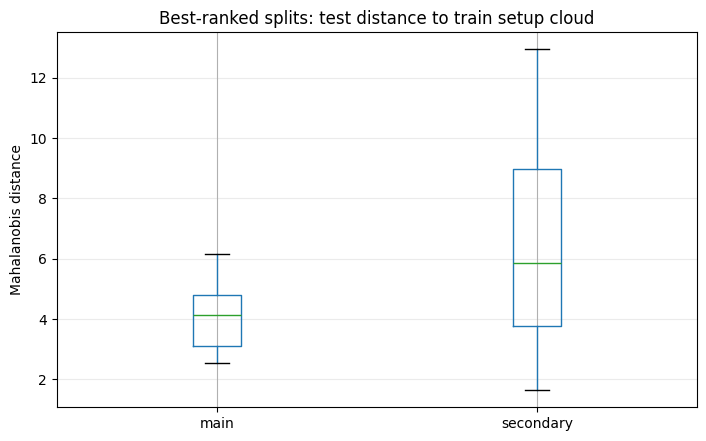

In [27]:
def compute_mahalanobis_distance(
    matrix: np.ndarray,
    center: np.ndarray,
    precision: np.ndarray,
) -> np.ndarray:
    """
    Compute Mahalanobis distance from a common center.
    """
    deltas = (
        matrix
        - center
    )

    squared_distances = np.einsum(
        "ij,jk,ik->i",
        deltas,
        precision,
        deltas,
    )

    return np.sqrt(
        np.maximum(
            squared_distances,
            0.0,
        )
    )


def compute_split_mahalanobis_distances(
    split_index: int,
    axis: str,
) -> pd.DataFrame:
    """
    Quantify how far each test setup lies from the train setup cloud.

    Preprocessing and covariance estimation are fit exclusively
    on the train groups.
    """
    split_row = get_split_row(
        split_index=split_index,
        axis=axis,
    )

    available_group_ids = set(
        setup_feature_df.index
    )

    train_group_ids = [
        group_id
        for group_id in parse_group_ids(
            split_row[
                "train_group_ids"
            ]
        )
        if group_id
        in available_group_ids
    ]

    test_group_ids = [
        group_id
        for group_id in parse_group_ids(
            split_row[
                "test_group_ids"
            ]
        )
        if group_id
        in available_group_ids
    ]

    if len(train_group_ids) < 3:
        raise ValueError(
            f"Split {split_index} ({axis}) has only "
            f"{len(train_group_ids)} usable train groups."
        )

    if not test_group_ids:
        raise ValueError(
            f"Split {split_index} ({axis}) has no usable test groups."
        )

    train_raw = (
        setup_feature_df.loc[
            train_group_ids,
            setup_feature_columns,
        ]
        .to_numpy(
            dtype=float
        )
    )

    test_raw = (
        setup_feature_df.loc[
            test_group_ids,
            setup_feature_columns,
        ]
        .to_numpy(
            dtype=float
        )
    )

    # Fit scaling only on train
    scaler = StandardScaler()

    train_matrix = (
        scaler.fit_transform(
            train_raw
        )
    )

    test_matrix = (
        scaler.transform(
            test_raw
        )
    )

    # Shrinkage covariance for numerical stability
    covariance_model = (
        LedoitWolf().fit(
            train_matrix
        )
    )

    train_center = (
        covariance_model.location_
    )

    precision_matrix = (
        covariance_model.precision_
    )

    train_distances = (
        compute_mahalanobis_distance(
            matrix=train_matrix,
            center=train_center,
            precision=precision_matrix,
        )
    )

    test_distances = (
        compute_mahalanobis_distance(
            matrix=test_matrix,
            center=train_center,
            precision=precision_matrix,
        )
    )

    train_p90 = float(
        np.quantile(
            train_distances,
            0.90,
        )
    )

    train_p95 = float(
        np.quantile(
            train_distances,
            0.95,
        )
    )

    train_p99 = float(
        np.quantile(
            train_distances,
            0.99,
        )
    )

    test_percentiles = np.asarray(
        [
            100.0
            * (
                np.sum(
                    train_distances
                    <= test_distance
                )
                + 1
            )
            / (
                len(train_distances)
                + 1
            )
            for test_distance
            in test_distances
        ],
        dtype=float,
    )

    result_df = pd.DataFrame(
        {
            "axis": axis,
            "split_index": split_index,
            "test_group_id": test_group_ids,
            "mahalanobis_distance": test_distances,
            "distance_percentile_vs_train": test_percentiles,
            "outside_train_p90": (
                test_distances
                > train_p90
            ),
            "outside_train_p95": (
                test_distances
                > train_p95
            ),
            "outside_train_p99": (
                test_distances
                > train_p99
            ),
            "train_group_count": len(
                train_group_ids
            ),
            "test_group_count": len(
                test_group_ids
            ),
            "train_distance_median": float(
                np.median(
                    train_distances
                )
            ),
            "train_distance_p90": train_p90,
            "train_distance_p95": train_p95,
            "train_distance_p99": train_p99,
        }
    )

    return result_df


mahalanobis_distance_df = pd.concat(
    [
        compute_split_mahalanobis_distances(
            split_index=best_main_split,
            axis="main",
        ),
        compute_split_mahalanobis_distances(
            split_index=best_secondary_split,
            axis="secondary",
        ),
    ],
    ignore_index=True,
)


mahalanobis_summary_df = (
    mahalanobis_distance_df
    .groupby(
        [
            "axis",
            "split_index",
        ],
        as_index=False,
    )
    .agg(
        train_group_count=(
            "train_group_count",
            "first",
        ),
        test_group_count=(
            "test_group_id",
            "count",
        ),
        mahalanobis_mean=(
            "mahalanobis_distance",
            "mean",
        ),
        mahalanobis_median=(
            "mahalanobis_distance",
            "median",
        ),
        mahalanobis_p90=(
            "mahalanobis_distance",
            lambda values: values.quantile(
                0.90
            ),
        ),
        mahalanobis_max=(
            "mahalanobis_distance",
            "max",
        ),
        median_percentile_vs_train=(
            "distance_percentile_vs_train",
            "median",
        ),
        outside_train_p90_count=(
            "outside_train_p90",
            "sum",
        ),
        outside_train_p95_count=(
            "outside_train_p95",
            "sum",
        ),
        outside_train_p95_fraction=(
            "outside_train_p95",
            "mean",
        ),
        outside_train_p99_count=(
            "outside_train_p99",
            "sum",
        ),
        train_distance_p95=(
            "train_distance_p95",
            "first",
        ),
    )
)


display(
    mahalanobis_summary_df
)


fig, ax = plt.subplots(
    figsize=(8, 5),
)

mahalanobis_distance_df.boxplot(
    column="mahalanobis_distance",
    by="axis",
    ax=ax,
)

ax.set_title(
    "Best-ranked splits: test distance to train setup cloud"
)

ax.set_xlabel("")
ax.set_ylabel(
    "Mahalanobis distance"
)

ax.grid(
    True,
    axis="y",
    alpha=0.25,
)

fig.suptitle("")

plt.show()


worst_test_groups_by_distance_df = (
    mahalanobis_distance_df
    .sort_values(
        by=[
            "outside_train_p95",
            "mahalanobis_distance",
        ],
        ascending=[
            False,
            False,
        ],
    )
    .reset_index(
        drop=True
    )
)


# display(
#     worst_test_groups_by_distance_df.head(
#         20
#     )
# )

### Split 1: Collet boost=0.85

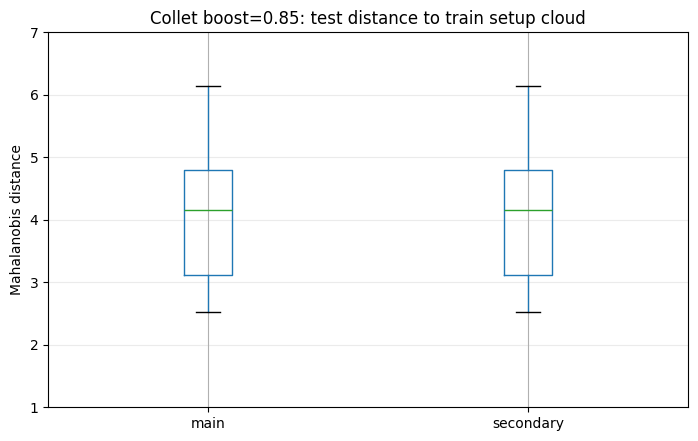

### Split 2: Collet boost=0.87

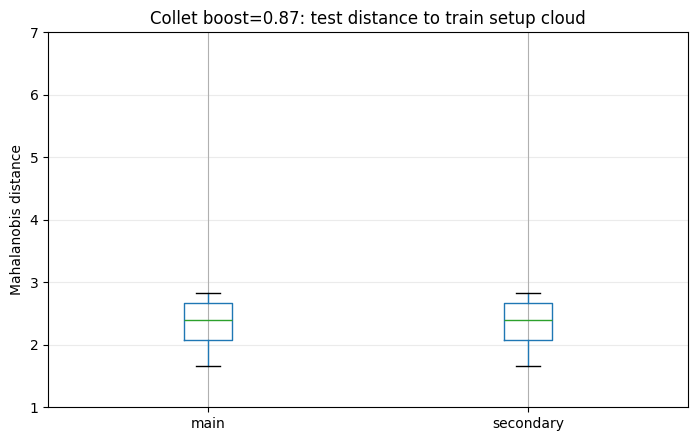

### Split 3: Collet boost=0.9

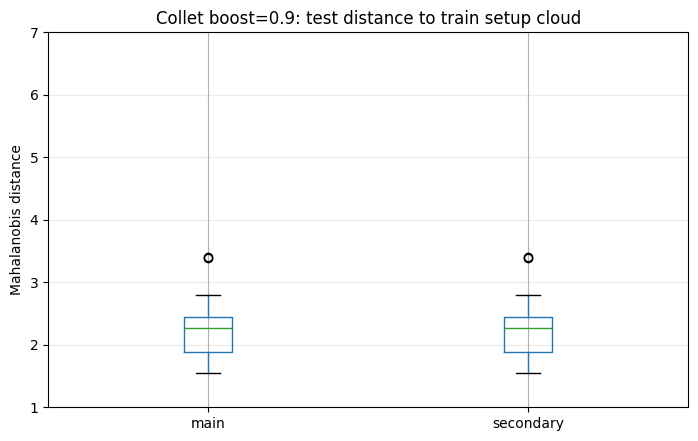

### Split 4: Collet boost=0.92

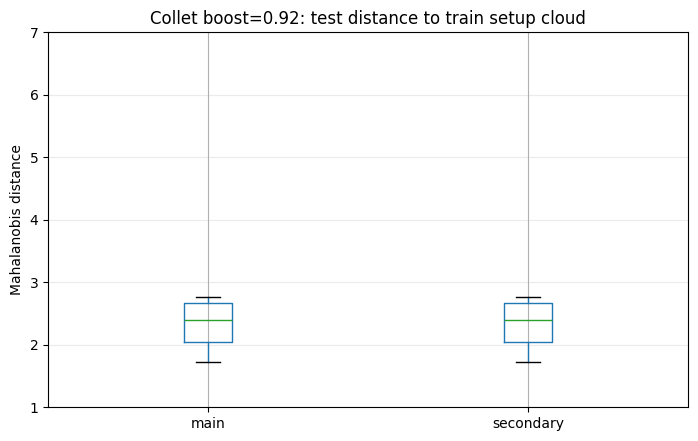

### Split 5: Collet boost=0.95

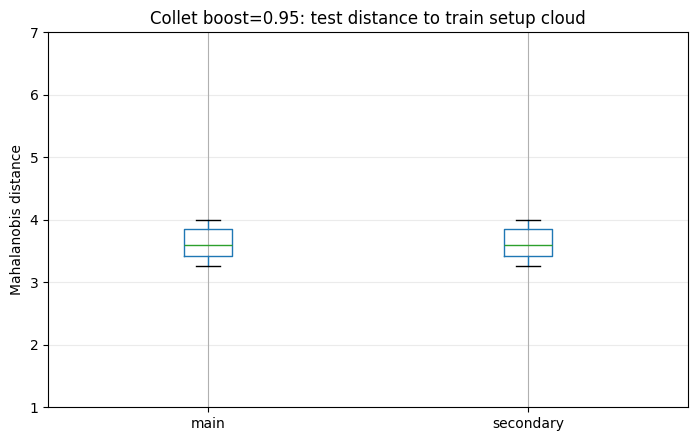

### Split 6: Mandrel retraction timing=0

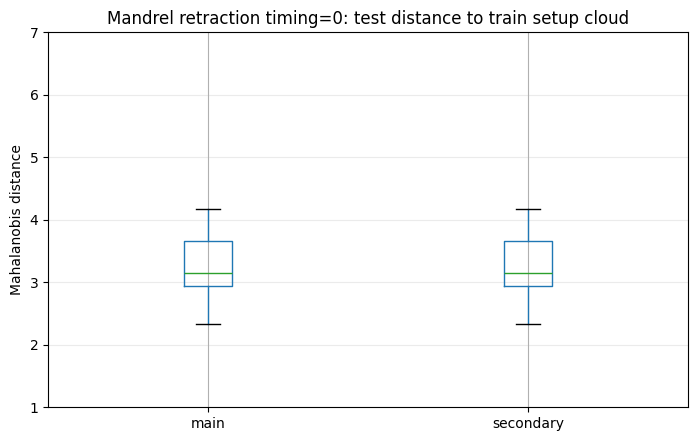

### Split 7: Mandrel retraction timing=10

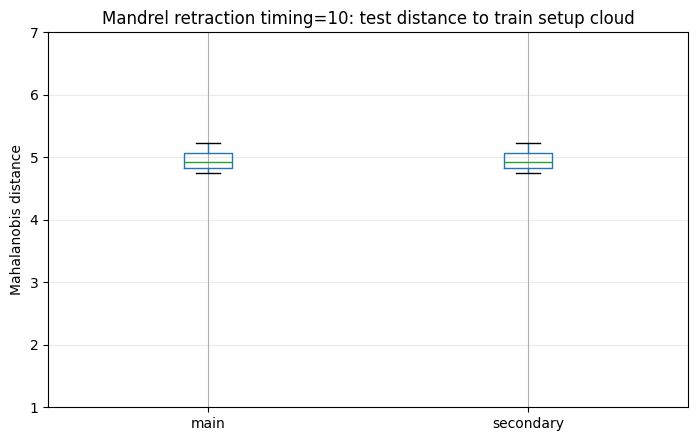

### Split 8: Mandrel retraction timing=2

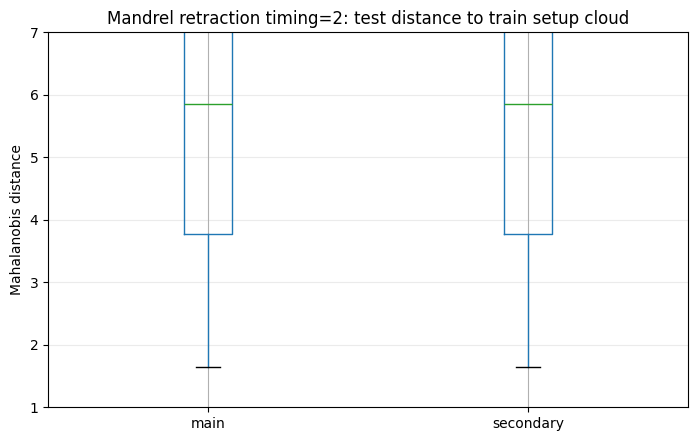

### Split 9: Mandrel retraction timing=5

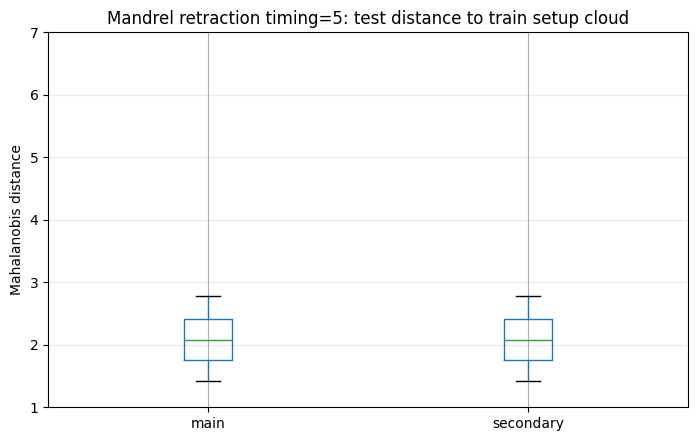

In [28]:
from IPython.display import display, Markdown


def compute_mahalanobis_distance(
    matrix: np.ndarray,
    center: np.ndarray,
    precision: np.ndarray,
) -> np.ndarray:
    deltas = matrix - center

    squared_distances = np.einsum(
        "ij,jk,ik->i",
        deltas,
        precision,
        deltas,
    )

    return np.sqrt(
        np.maximum(
            squared_distances,
            0.0,
        )
    )


def compute_split_mahalanobis_distances(
    split_index: int,
    axis: str,
) -> pd.DataFrame:
    split_row = get_split_row(
        split_index=split_index,
        axis=axis,
    )

    available_group_ids = set(
        setup_feature_df.index
    )

    train_group_ids = [
        int(group_id)
        for group_id in parse_group_ids(
            split_row["train_group_ids"]
        )
        if int(group_id) in available_group_ids
    ]

    test_group_ids = [
        int(group_id)
        for group_id in parse_group_ids(
            split_row["test_group_ids"]
        )
        if int(group_id) in available_group_ids
    ]

    train_raw = (
        setup_feature_df
        .loc[train_group_ids, setup_feature_columns]
        .to_numpy(dtype=float)
    )

    test_raw = (
        setup_feature_df
        .loc[test_group_ids, setup_feature_columns]
        .to_numpy(dtype=float)
    )

    scaler = StandardScaler()
    train_matrix = scaler.fit_transform(train_raw)
    test_matrix = scaler.transform(test_raw)

    covariance_model = LedoitWolf().fit(train_matrix)

    train_distances = compute_mahalanobis_distance(
        matrix=train_matrix,
        center=covariance_model.location_,
        precision=covariance_model.precision_,
    )

    test_distances = compute_mahalanobis_distance(
        matrix=test_matrix,
        center=covariance_model.location_,
        precision=covariance_model.precision_,
    )

    train_p95 = float(
        np.quantile(
            train_distances,
            0.95,
        )
    )

    return pd.DataFrame(
        {
            "axis": axis,
            "split_index": int(split_index),
            "split_name": split_row["split_name"],
            "test_group_id": test_group_ids,
            "mahalanobis_distance": test_distances,
            "outside_train_p95": test_distances > train_p95,
            "train_distance_p95": train_p95,
        }
    )


all_mahalanobis_frames = []

all_split_indices = (
    split_metadata_df["split_index"]
    .drop_duplicates()
    .astype(int)
    .sort_values()
    .tolist()
)

for split_index in all_split_indices:
    for axis in [
        "main",
        "secondary",
    ]:
        all_mahalanobis_frames.append(
            compute_split_mahalanobis_distances(
                split_index=split_index,
                axis=axis,
            )
        )


mahalanobis_distance_df = pd.concat(
    all_mahalanobis_frames,
    ignore_index=True,
)

for split_name, split_df in mahalanobis_distance_df.groupby(
    "split_name",
    sort=False,
):
    split_index = int(
        split_df["split_index"].iloc[0]
    )

    display(
        Markdown(
            f"### Split {split_index}: {split_name}"
        )
    )

    fig, ax = plt.subplots(
        figsize=(8, 5),
    )

    split_df.boxplot(
        column="mahalanobis_distance",
        by="axis",
        ax=ax,
    )

    ax.set_title(
        f"{split_name}: test distance to train setup cloud"
    )

    ax.set_xlabel("")
    ax.set_ylabel(
        "Mahalanobis distance"
    )

    ax.set_ylim(
        1,
        7,
    )

    ax.grid(
        True,
        axis="y",
        alpha=0.25,
    )

    fig.suptitle("")

    plt.show()

# qrf train result test groups

Project root: /Users/soroureskandari/Master Thesis /tube-bending-geometry
Model directory: /Users/soroureskandari/Master Thesis /tube-bending-geometry/src/pipeline/ml/qrf/results/models

Plotting Real / main


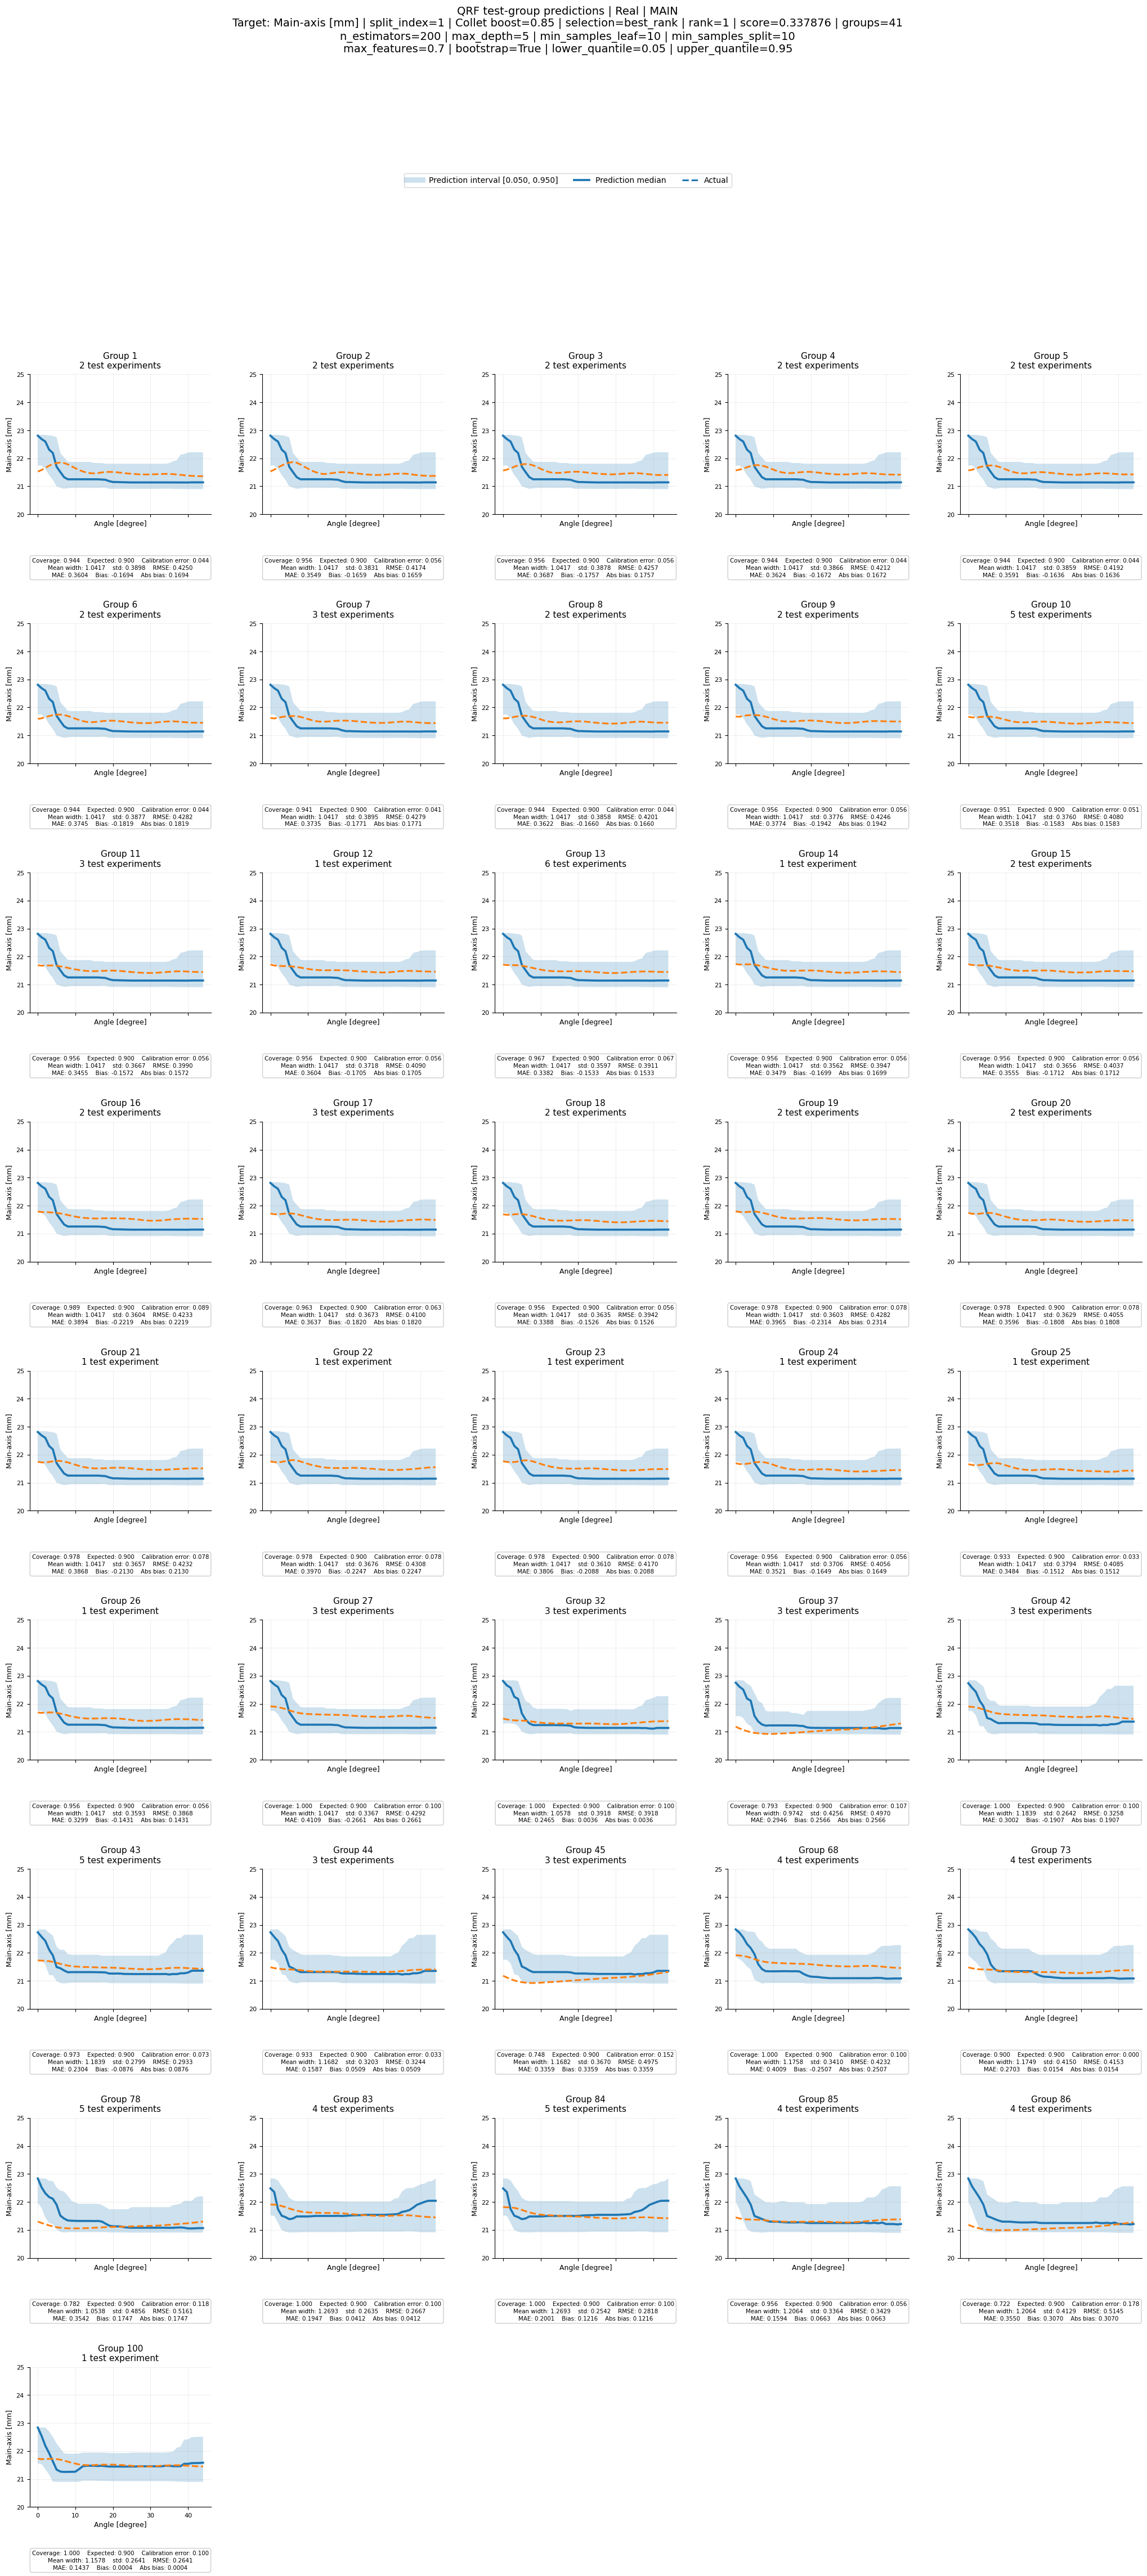


Plotting Real / secondary


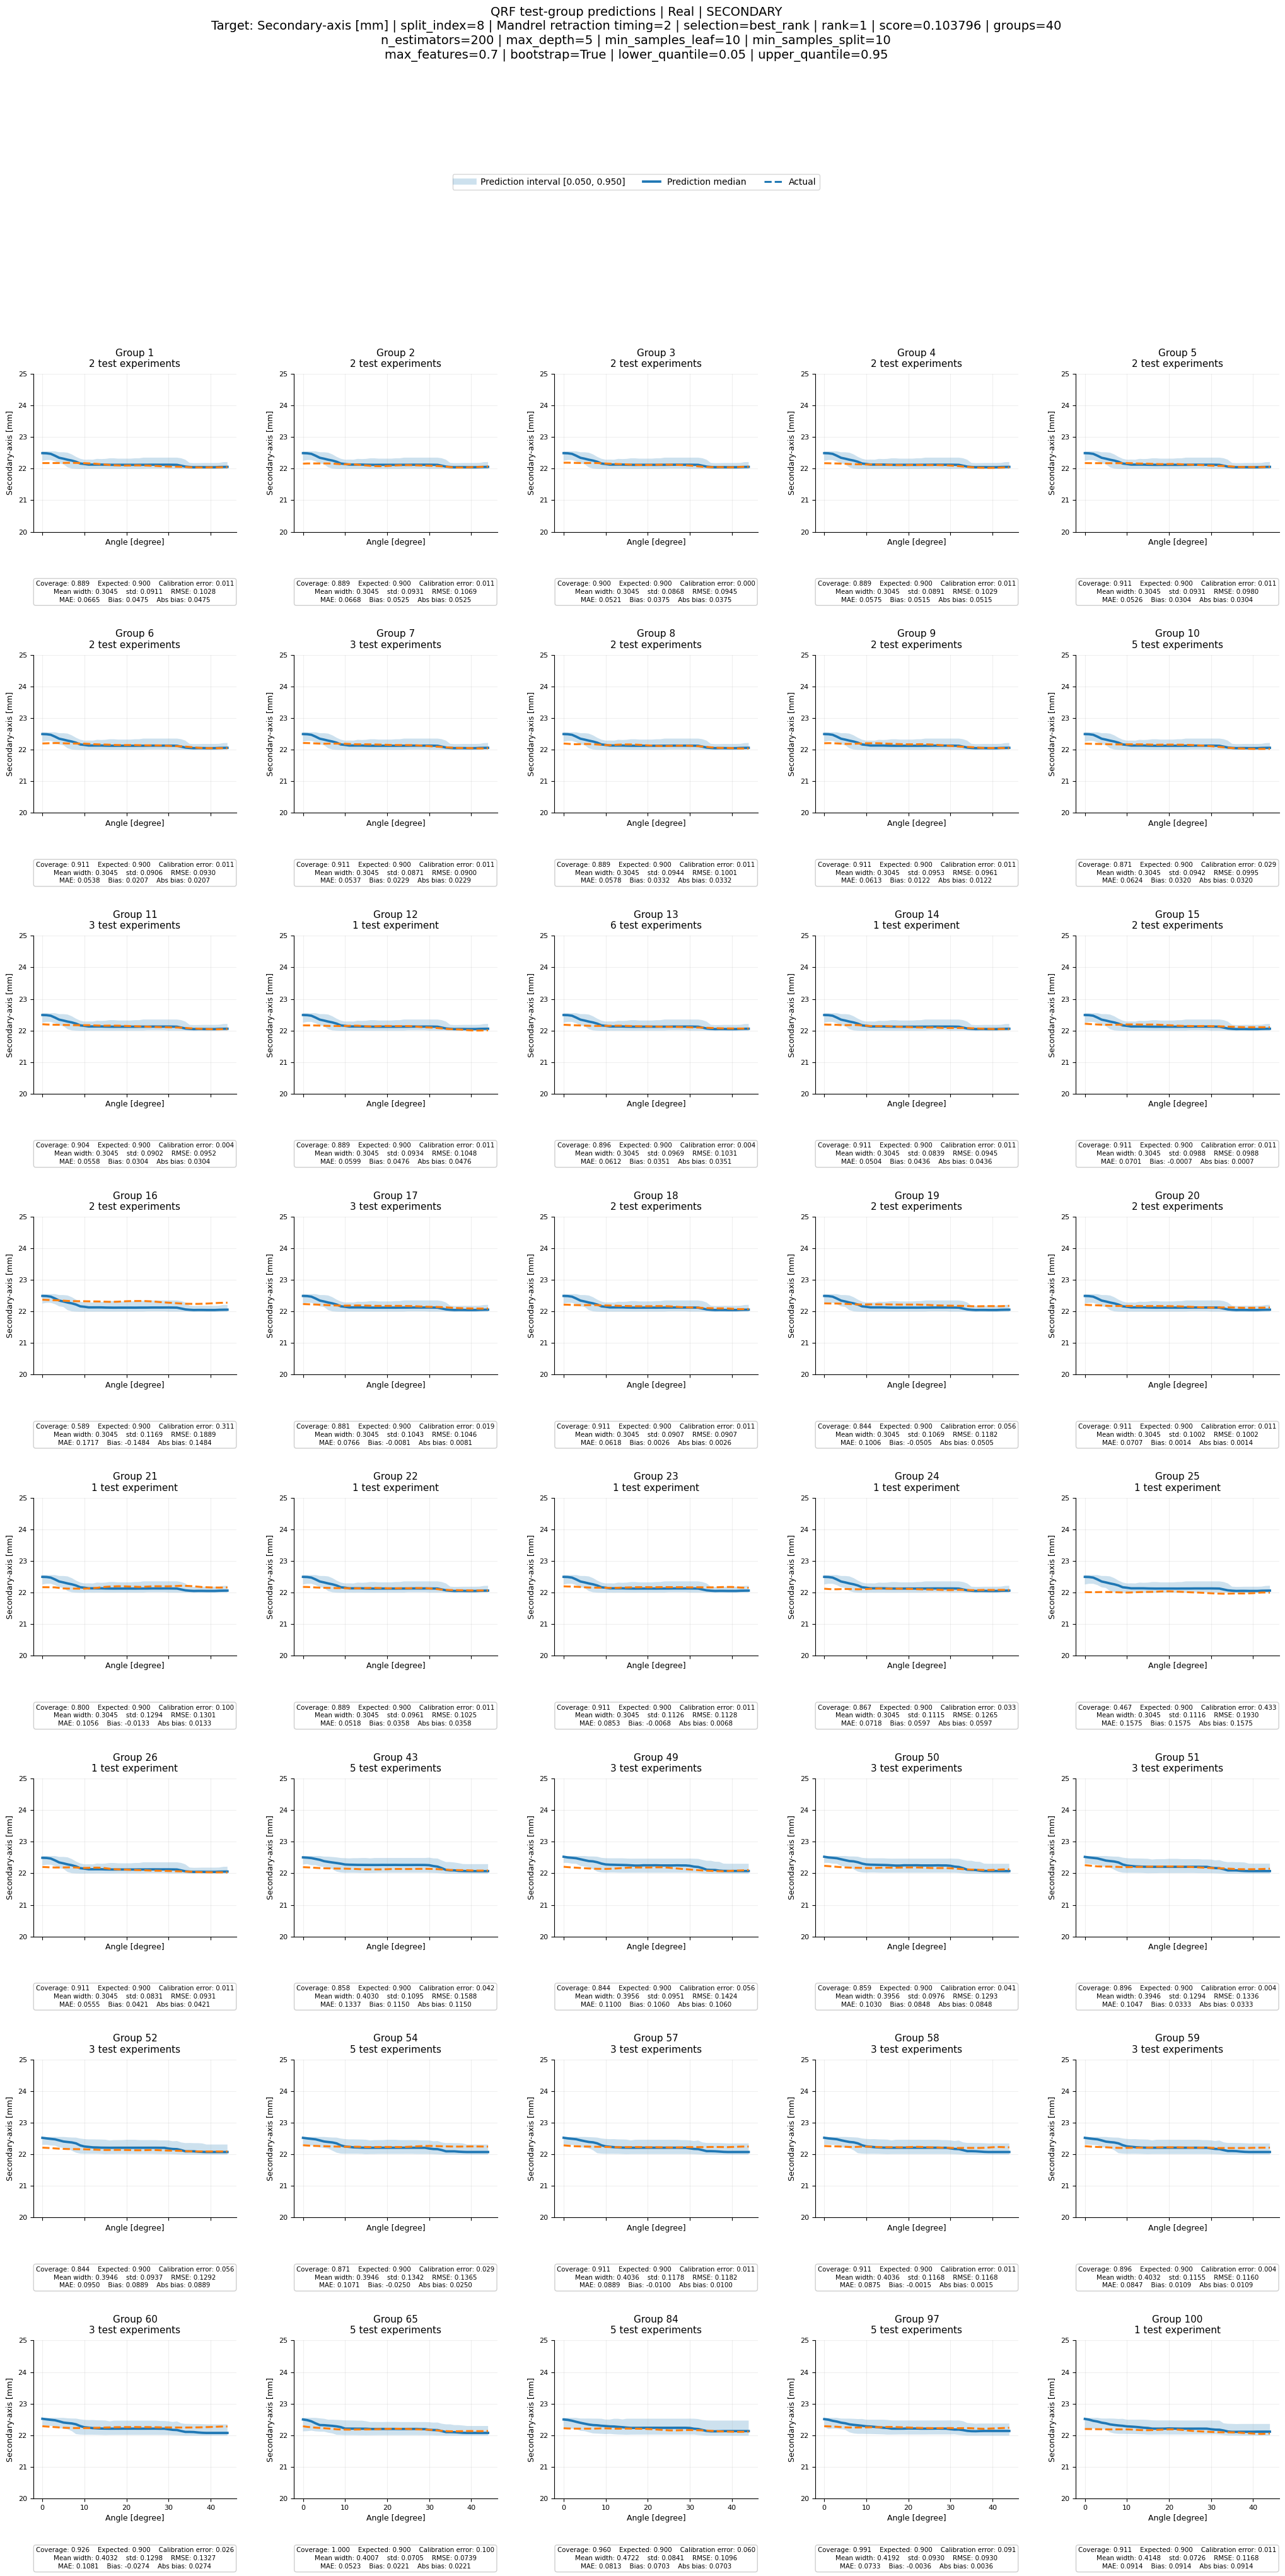


Plotting Augmented / main


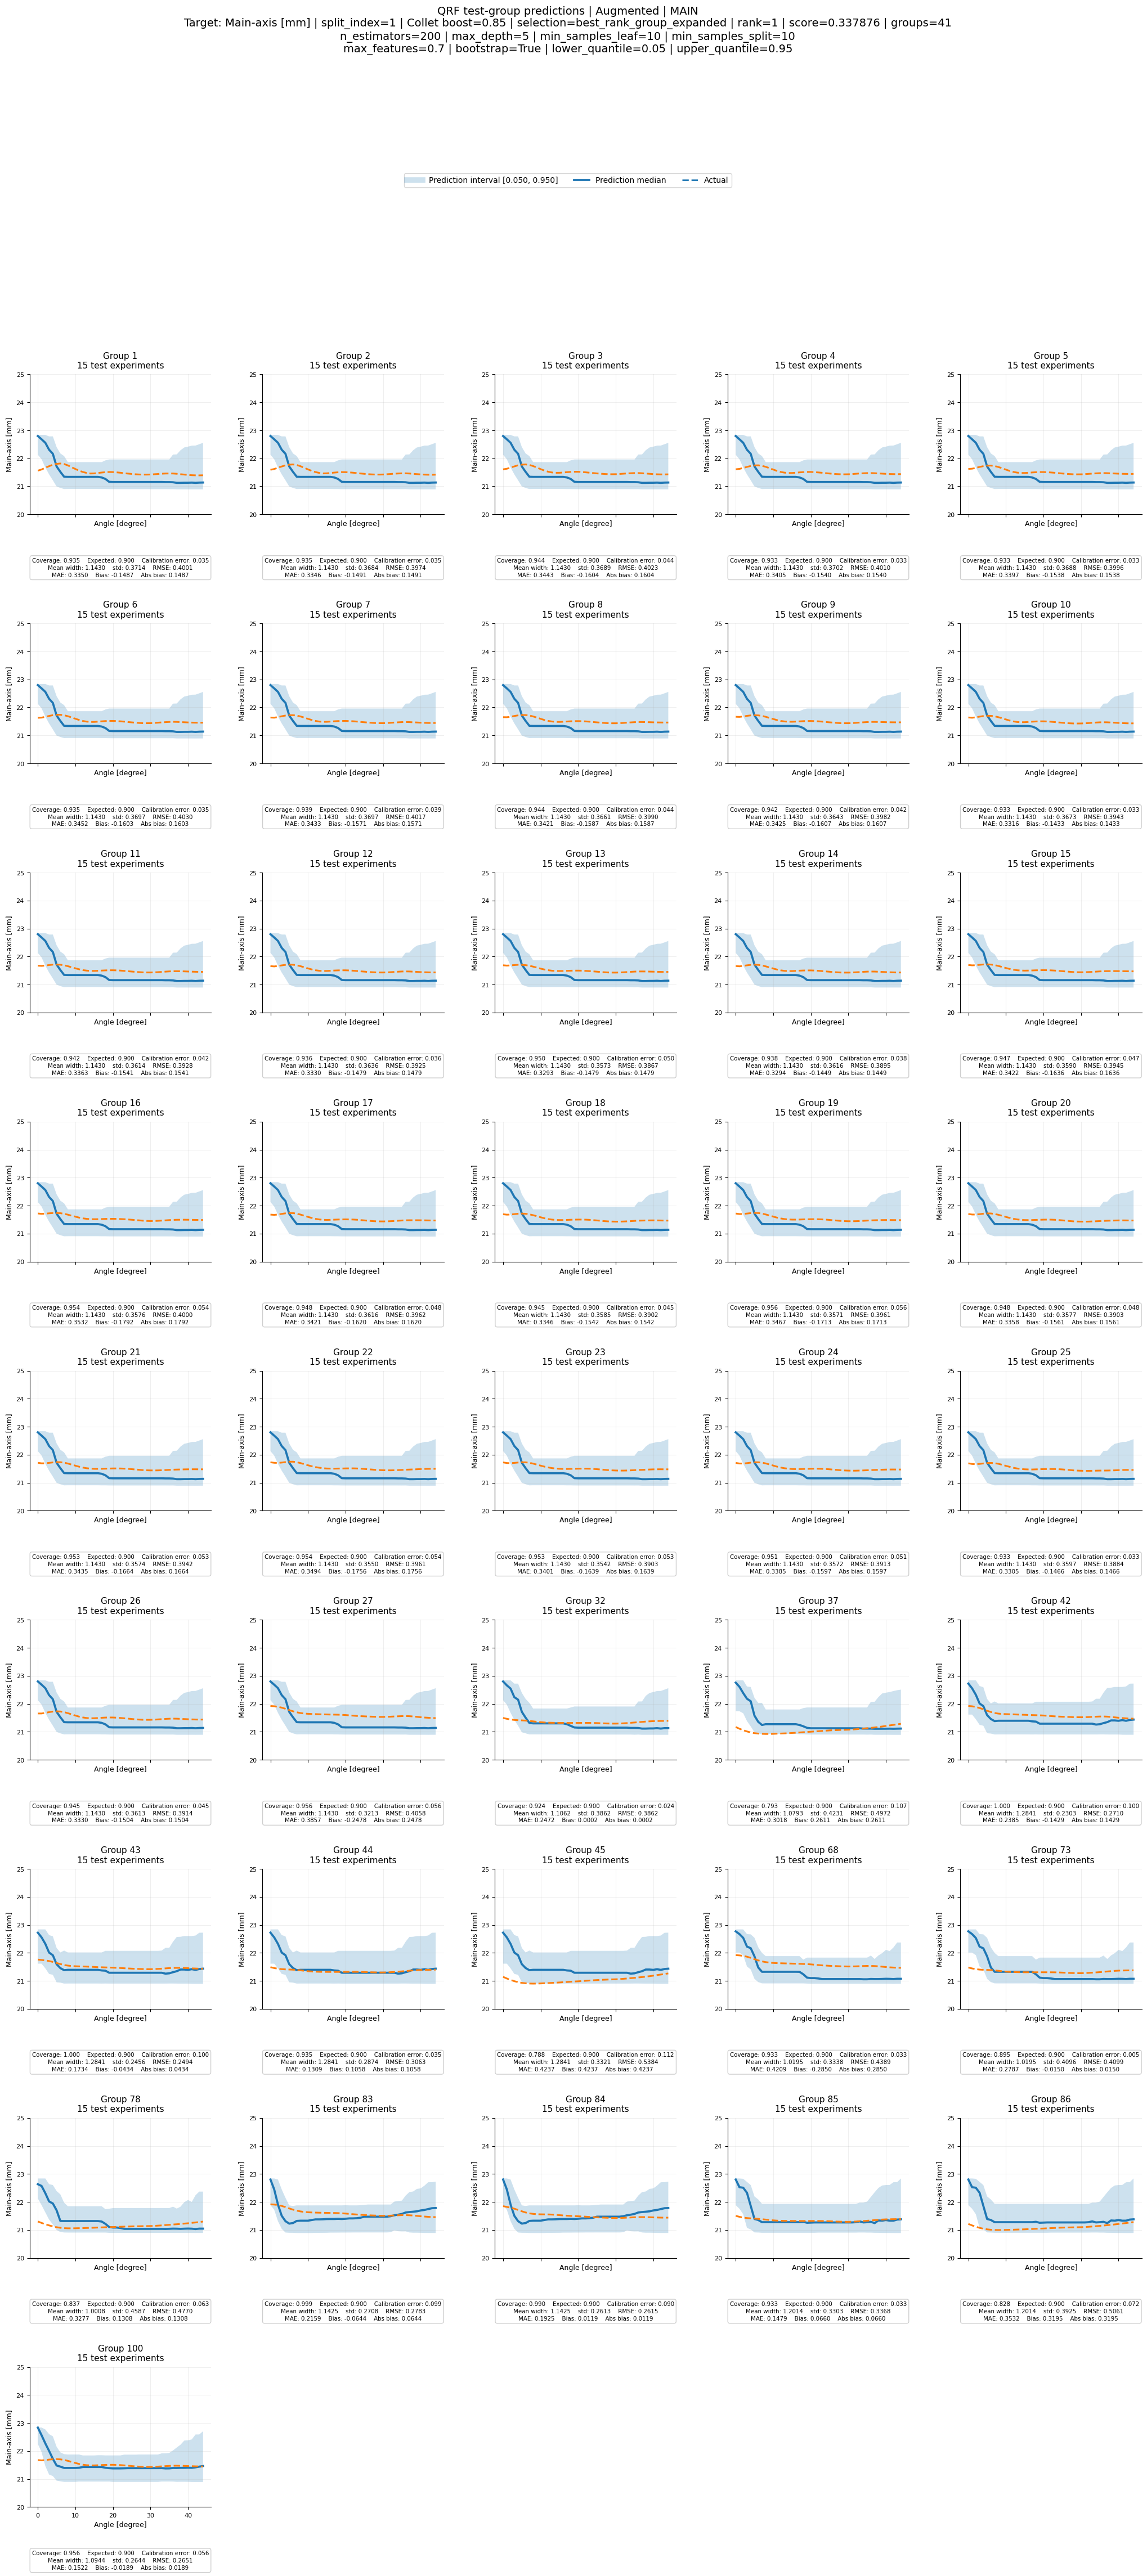


Plotting Augmented / secondary


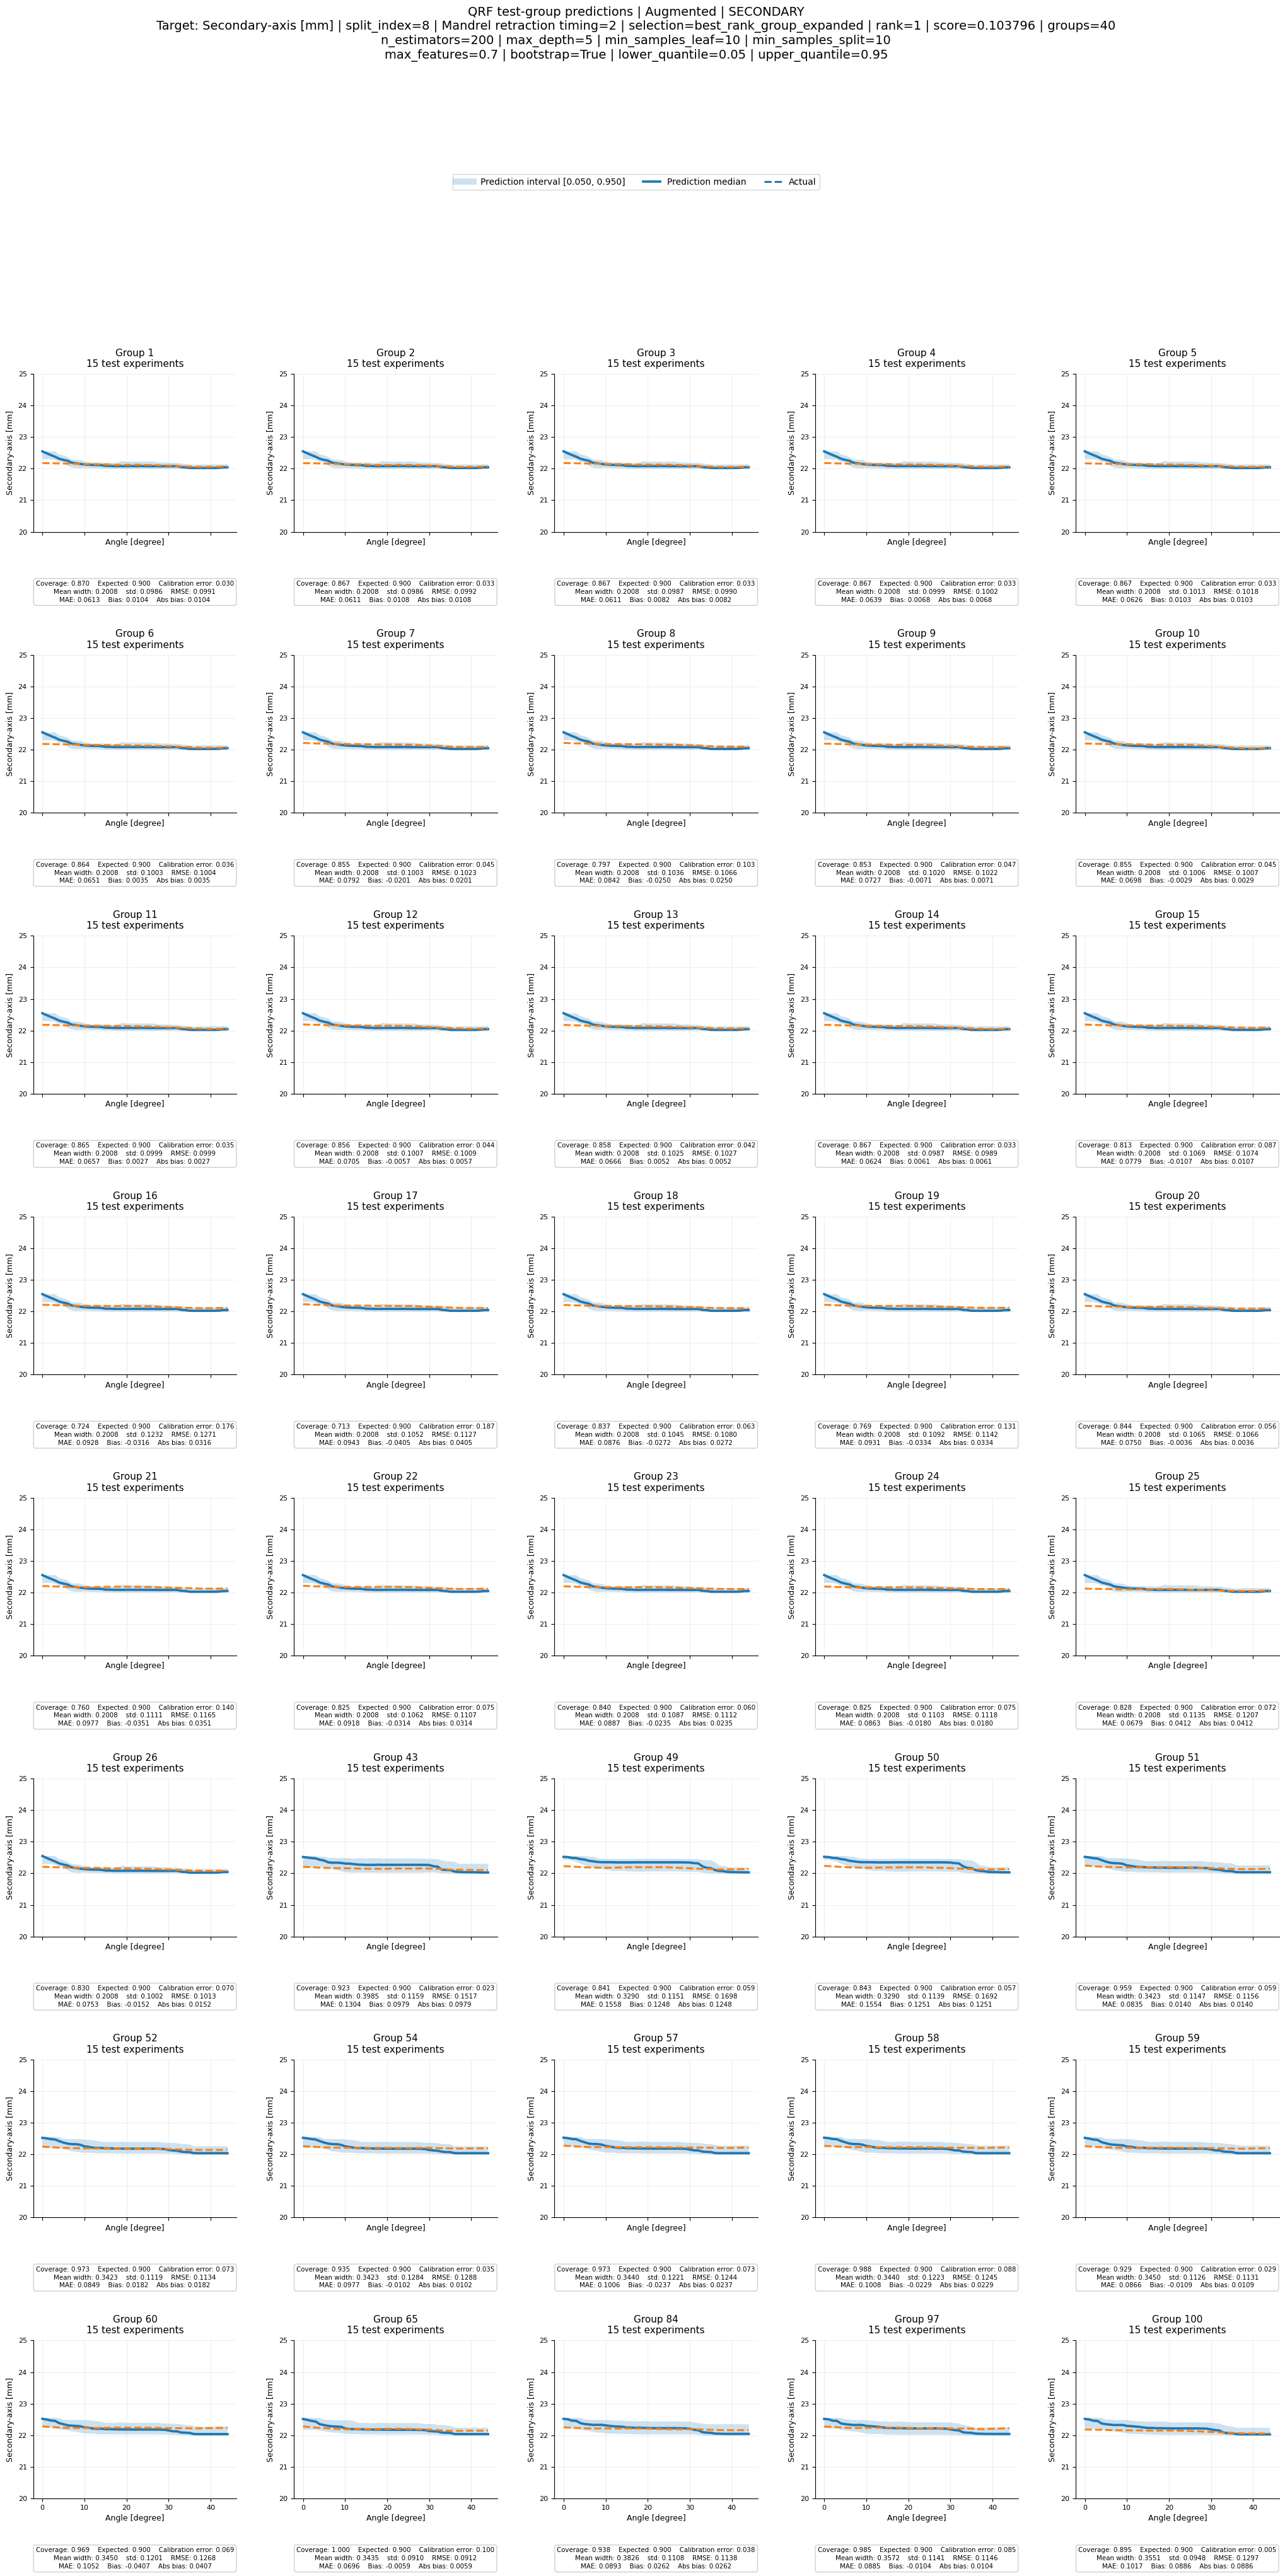


Plotting Interpolation / main


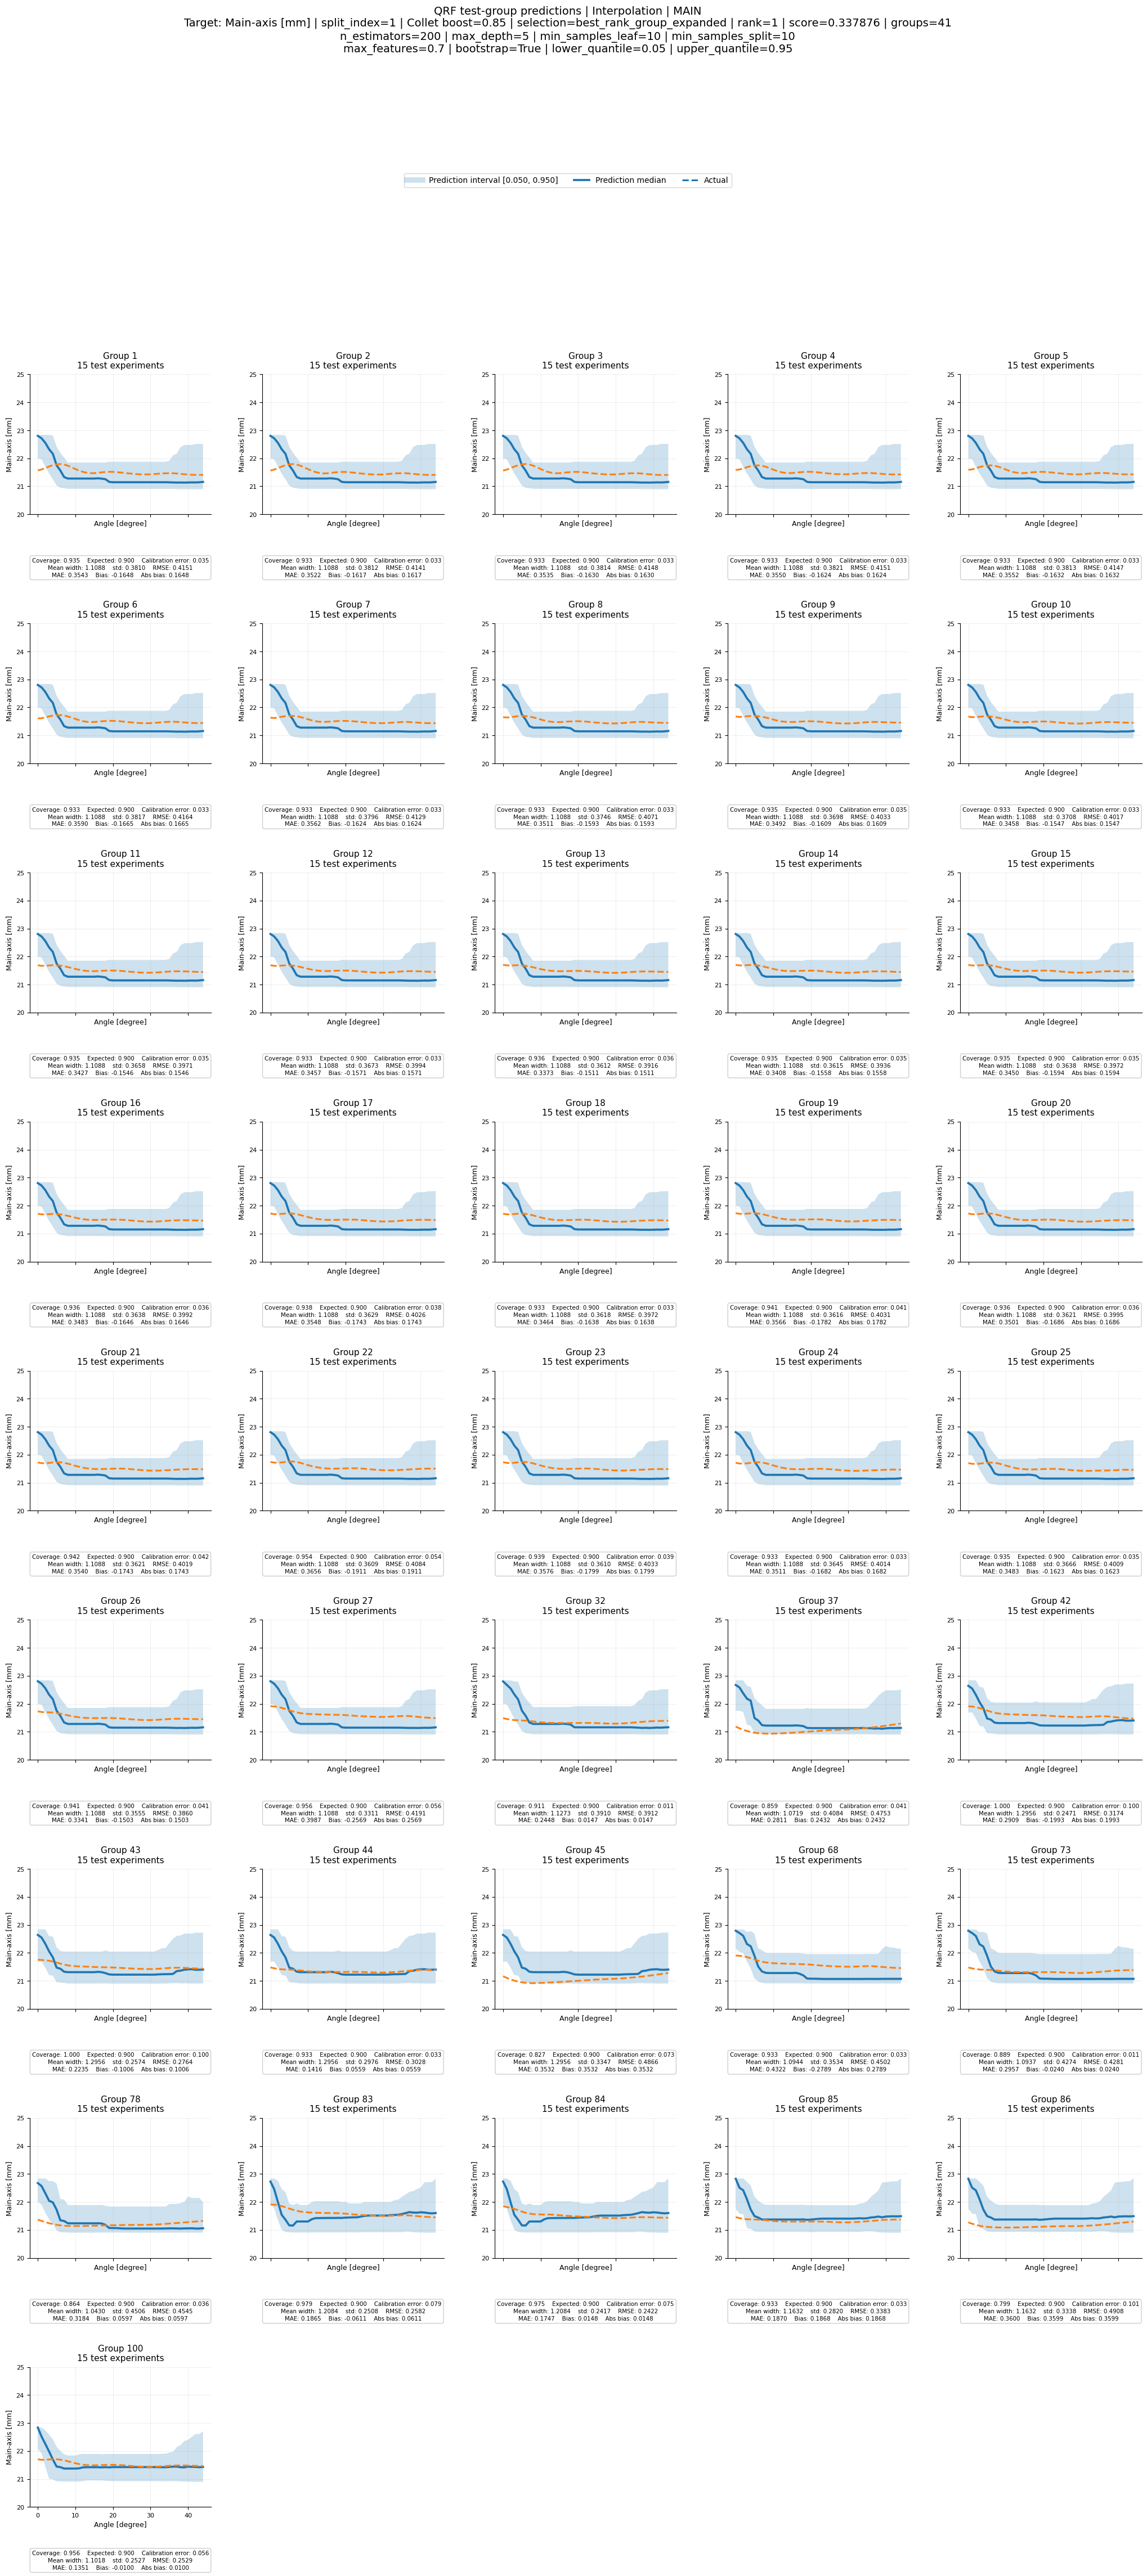


Plotting Interpolation / secondary


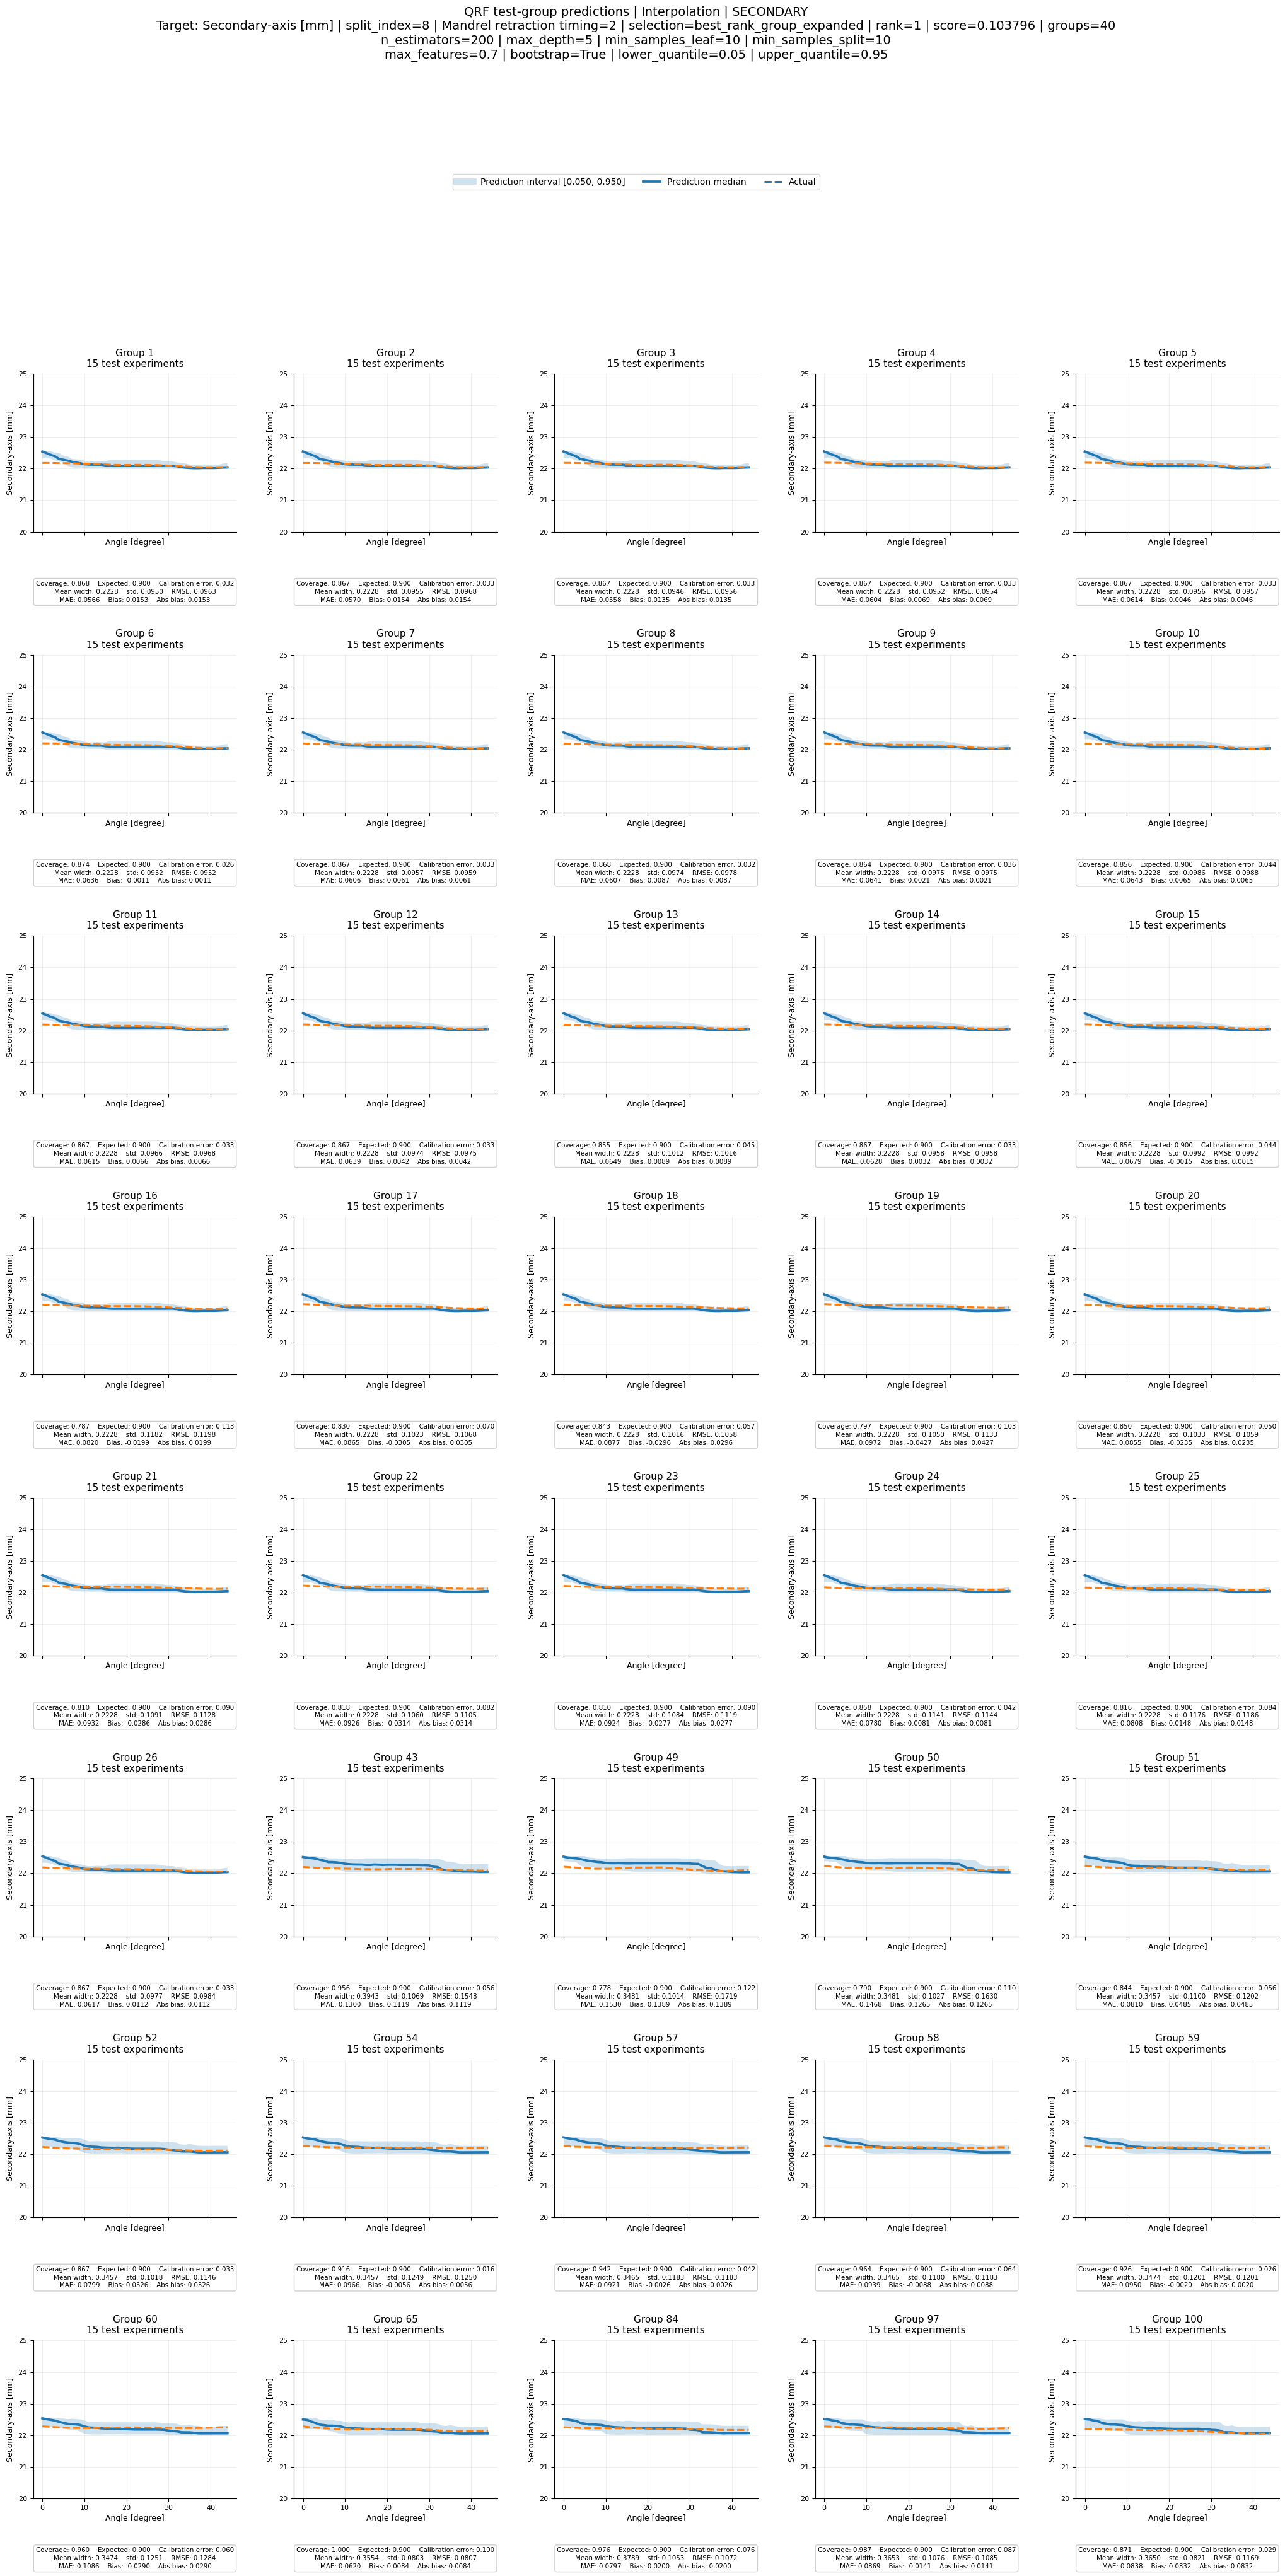

,geometry_source,axis,split_selection_mode,split_index,split_name,qrf_rank,qrf_score,number_of_groups,missing_group_ids,artifact_directory
0,real,main,best_rank,1,Collet boost=0.85,1,0.337876,41,[],/Users/soroureskandari/Master Thesis /tube-ben...
1,real,secondary,best_rank,8,Mandrel retraction timing=2,1,0.103796,40,[],/Users/soroureskandari/Master Thesis /tube-ben...
2,sensor_augmented_noise__time_wrapping__scaling...,main,best_rank_group_expanded,1,Collet boost=0.85,1,0.337876,41,[],/Users/soroureskandari/Master Thesis /tube-ben...
3,sensor_augmented_noise__time_wrapping__scaling...,secondary,best_rank_group_expanded,8,Mandrel retraction timing=2,1,0.103796,40,[],/Users/soroureskandari/Master Thesis /tube-ben...
4,within_group_interpolation_raw,main,best_rank_group_expanded,1,Collet boost=0.85,1,0.337876,41,[],/Users/soroureskandari/Master Thesis /tube-ben...
5,within_group_interpolation_raw,secondary,best_rank_group_expanded,8,Mandrel retraction timing=2,1,0.103796,40,[],/Users/soroureskandari/Master Thesis /tube-ben...


In [29]:
# ============================================================
# QRF: all test groups
#
# Output:
#   3 geometry sources × 2 axes = 6 figures
#
# Each figure:
#   - one subplot per test Group_ID
#   - actual group mean
#   - QRF prediction median
#   - QRF prediction interval
#   - group-level metrics below each subplot
#   - model configuration in the figure header
# ============================================================

from pathlib import Path
import ast
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ============================================================
# Configuration
# ============================================================

def find_project_root(start: Path) -> Path:
    current = start.resolve()

    while True:
        if (
            (current / "data").exists()
            and (
                current
                / "src"
                / "pipeline"
                / "ml"
                / "qrf"
            ).exists()
        ):
            return current

        if current == current.parent:
            raise RuntimeError(
                "Could not locate the project root."
            )

        current = current.parent


PROJECT_ROOT = find_project_root(Path.cwd())

QRF_ROOT = (
    PROJECT_ROOT
    / "src"
    / "pipeline"
    / "ml"
    / "qrf"
)

MODEL_RESULTS_DIR = (
    QRF_ROOT
    / "results"
    / "models"
)

SPLIT_METADATA_PATH = (
    QRF_ROOT
    / "data"
    / "various_splits.parquet"
)

DATA_SOURCES = {
    "real": "Real",
    (
        "sensor_augmented_noise__"
        "time_wrapping__scaling__jittering"
    ): "Augmented",
    "within_group_interpolation_raw": "Interpolation",
}

AXIS_CONFIG = {
    "main": {
        "target": "Main-axis [mm]",
    },
    "secondary": {
        "target": "Secondary-axis [mm]",
    },
}

ANGLE_COLUMN = "Angle[degree]ORDistance[mm]"

# Five columns gives 4 rows when there are 20 test groups.
SUBPLOT_COLUMNS = 5

# Increase this when labels or metrics look crowded.
SUBPLOT_WIDTH = 5.1
SUBPLOT_HEIGHT = 5.4

# Fixed y-axis range for every subplot.
Y_AXIS_LIMITS = (20, 25)

# True applies a small rolling average only to plotted curves.
# Metrics are always calculated from the original unsmoothed rows.
SMOOTH_PLOTTED_CURVES = False
SMOOTHING_WINDOW = 3

SAVE_FIGURES = False

FIGURE_OUTPUT_DIR = (
    QRF_ROOT
    / "results"
    / "all_test_group_figures"
)

if SAVE_FIGURES:
    FIGURE_OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Project root:", PROJECT_ROOT)
print("Model directory:", MODEL_RESULTS_DIR)


# ============================================================
# Data helpers
# ============================================================

def read_table(path: Path) -> pd.DataFrame:
    suffix = path.suffix.lower()

    if suffix == ".parquet":
        return pd.read_parquet(path)

    if suffix == ".csv":
        return pd.read_csv(path)

    raise ValueError(
        f"Unsupported table format: {path}"
    )


def decode_integer_list(value) -> list[int]:
    if isinstance(value, str):
        value = ast.literal_eval(value)

    if isinstance(value, np.ndarray):
        value = value.tolist()

    if isinstance(value, pd.Series):
        value = value.tolist()

    if isinstance(value, (list, tuple, set)):
        return sorted(
            {
                int(item)
                for item in value
                if pd.notna(item)
            }
        )

    if pd.isna(value):
        return []

    return [int(value)]


def load_split_config_from_artifact_metadata(
    axis: str,
    metadata: dict,
) -> dict:
    """
    Resolve split membership from the artifact metadata.

    The artifact is the source of truth for which split was
    actually trained. various_splits.parquet is used only to
    recover the stored test group IDs for that split_index.
    """
    if axis not in AXIS_CONFIG:
        raise KeyError(
            f"Unknown axis: {axis!r}"
        )

    split_index = int(
        metadata["split_index"]
    )
    rank_column = f"qrf_rank_{axis}"
    score_column = f"qrf_score_{axis}"

    split_df = pd.read_parquet(
        SPLIT_METADATA_PATH
    )

    required_columns = {
        "split_index",
        "split_name",
        "test_group_ids",
        rank_column,
    }

    missing = required_columns.difference(
        split_df.columns
    )

    if missing:
        raise KeyError(
            "Split metadata is missing columns: "
            f"{sorted(missing)}"
        )

    matches = split_df[
        pd.to_numeric(
            split_df["split_index"],
            errors="raise",
        ).astype(int).eq(split_index)
    ].copy()

    if len(matches) != 1:
        raise ValueError(
            f"Expected exactly one split with "
            f"split_index={split_index}, "
            f"but found {len(matches)}."
        )

    row = matches.iloc[0]

    return {
        "axis": axis,
        "split_index": split_index,
        "split_name": str(
            metadata.get(
                "split_name",
                row["split_name"],
            )
        ),
        "test_group_ids": decode_integer_list(
            row["test_group_ids"]
        ),
        "rank": (
            int(metadata["qrf_rank"])
            if pd.notna(metadata.get("qrf_rank"))
            else (
                int(row[rank_column])
                if pd.notna(row[rank_column])
                else None
            )
        ),
        "score": (
            float(metadata["qrf_score"])
            if pd.notna(metadata.get("qrf_score"))
            else (
                float(row[score_column])
                if (
                    score_column in row.index
                    and pd.notna(row[score_column])
                )
                else None
            )
        ),
        "split_selection_mode": metadata.get(
            "split_selection_mode",
            "unknown",
        ),
    }


# ============================================================
# Artifact loading
# ============================================================

def find_latest_qrf_artifact(
    geometry_source: str,
    axis: str,
    split_index: int | None = None,
) -> tuple[Path, dict]:
    """
    Find the newest artifact matching source and axis.

    When split_index is provided, restrict the search to that
    split. Otherwise the newest artifact metadata is used as
    the source of truth for the selected split.
    """
    axis_directory = (
        MODEL_RESULTS_DIR
        / geometry_source
        / axis
    )

    if not axis_directory.exists():
        raise FileNotFoundError(
            f"Missing QRF axis directory: "
            f"{axis_directory}"
        )

    candidates = []

    for metadata_path in axis_directory.glob(
        "*/metadata.json"
    ):
        with metadata_path.open(
            "r",
            encoding="utf-8",
        ) as file:
            metadata = json.load(file)

        metadata_split_index = metadata.get(
            "split_index"
        )

        if metadata_split_index is None:
            continue

        if (
            split_index is not None
            and int(metadata_split_index) != int(split_index)
        ):
            continue

        artifact_directory = metadata_path.parent

        candidates.append(
            {
                "modified_time": (
                    artifact_directory
                    .stat()
                    .st_mtime
                ),
                "artifact_directory": artifact_directory,
                "metadata": metadata,
            }
        )

    if not candidates:
        raise FileNotFoundError(
            "No matching QRF artifact found for "
            f"source={geometry_source!r}, "
            f"axis={axis!r}, "
            f"split_index={split_index}."
        )

    selected = max(
        candidates,
        key=lambda item: item["modified_time"],
    )

    return (
        selected["artifact_directory"],
        selected["metadata"],
    )


def load_test_predictions(
    geometry_source: str,
    axis: str,
) -> tuple[pd.DataFrame, dict, Path, dict]:
    artifact_directory, metadata = (
        find_latest_qrf_artifact(
            geometry_source=geometry_source,
            axis=axis,
        )
    )

    split_config = load_split_config_from_artifact_metadata(
        axis=axis,
        metadata=metadata,
    )

    prediction_path = (
        artifact_directory
        / "test_predictions.parquet"
    )

    if not prediction_path.exists():
        prediction_path = (
            artifact_directory
            / "test_predictions.csv"
        )

    if not prediction_path.exists():
        raise FileNotFoundError(
            "No test_predictions.parquet or "
            f"test_predictions.csv found in "
            f"{artifact_directory}"
        )

    prediction_df = read_table(
        prediction_path
    ).copy()

    required_columns = {
        ANGLE_COLUMN,
        "Group_ID",
        "Experiment_ID",
        "y_true",
        "y_median",
        "y_lower",
        "y_upper",
    }

    missing = required_columns.difference(
        prediction_df.columns
    )

    if missing:
        raise KeyError(
            f"{prediction_path} is missing columns: "
            f"{sorted(missing)}"
        )

    numeric_columns = [
        ANGLE_COLUMN,
        "Group_ID",
        "Experiment_ID",
        "y_true",
        "y_median",
        "y_lower",
        "y_upper",
    ]

    for column in numeric_columns:
        prediction_df[column] = pd.to_numeric(
            prediction_df[column],
            errors="coerce",
        )

    prediction_df = prediction_df.dropna(
        subset=[
            ANGLE_COLUMN,
            "Group_ID",
            "y_true",
            "y_median",
            "y_lower",
            "y_upper",
        ]
    ).copy()

    prediction_df["Group_ID"] = (
        prediction_df["Group_ID"]
        .astype(int)
    )

    prediction_df = prediction_df[
        prediction_df[ANGLE_COLUMN].between(
            0,
            44,
            inclusive="both",
        )
    ].copy()

    expected_groups = set(
        split_config["test_group_ids"]
    )

    prediction_df = prediction_df[
        prediction_df["Group_ID"].isin(
            expected_groups
        )
    ].copy()

    return (
        prediction_df,
        metadata,
        artifact_directory,
        split_config,
    )


# ============================================================
# Metrics
# ============================================================

def resolve_quantiles(
    metadata: dict,
) -> tuple[float, float]:
    model_config = metadata.get(
        "model_config",
        {},
    )

    lower_quantile = float(
        model_config.get(
            "lower_quantile",
            metadata.get(
                "lower_quantile",
                0.05,
            ),
        )
    )

    upper_quantile = float(
        model_config.get(
            "upper_quantile",
            metadata.get(
                "upper_quantile",
                0.95,
            ),
        )
    )

    return (
        lower_quantile,
        upper_quantile,
    )


def compute_group_metrics(
    group_df: pd.DataFrame,
    expected_coverage: float,
) -> dict[str, float]:
    """
    Match the metric definitions currently used by qrf_ui.

    Metrics are calculated on all raw test rows belonging
    to the selected Group_ID.
    """
    y_true = group_df["y_true"].to_numpy(
        dtype=float
    )

    y_median = group_df["y_median"].to_numpy(
        dtype=float
    )

    y_lower = group_df["y_lower"].to_numpy(
        dtype=float
    )

    y_upper = group_df["y_upper"].to_numpy(
        dtype=float
    )

    finite_mask = (
        np.isfinite(y_true)
        & np.isfinite(y_median)
        & np.isfinite(y_lower)
        & np.isfinite(y_upper)
    )

    y_true = y_true[finite_mask]
    y_median = y_median[finite_mask]
    y_lower = y_lower[finite_mask]
    y_upper = y_upper[finite_mask]

    if len(y_true) == 0:
        return {
            "coverage": np.nan,
            "expected_coverage": expected_coverage,
            "calibration_error": np.nan,
            "mean_interval_width": np.nan,
            "residual_std": np.nan,
            "rmse": np.nan,
            "mae": np.nan,
            "bias": np.nan,
            "abs_bias": np.nan,
        }

    inside_interval = (
        (y_true >= y_lower)
        & (y_true <= y_upper)
    )

    residual = y_median - y_true

    coverage = float(
        inside_interval.mean()
    )

    rmse = float(
        np.sqrt(
            np.mean(
                np.square(residual)
            )
        )
    )

    mae = float(
        np.mean(
            np.abs(residual)
        )
    )

    bias = float(
        np.mean(residual)
    )

    return {
        "coverage": coverage,
        "expected_coverage": expected_coverage,
        "calibration_error": abs(
            coverage - expected_coverage
        ),
        "mean_interval_width": float(
            np.mean(y_upper - y_lower)
        ),
        "residual_std": float(
            np.std(
                residual,
                ddof=0,
            )
        ),
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "abs_bias": abs(bias),
    }


# ============================================================
# Plot preparation
# ============================================================

def prepare_group_curve(
    group_df: pd.DataFrame,
) -> pd.DataFrame:
    """
    Average experiments inside one Group_ID at each angle.

    This removes individual experiment signals and leaves:
      - actual group curve
      - median prediction curve
      - prediction interval
    """
    curve_df = (
        group_df
        .groupby(
            ANGLE_COLUMN,
            as_index=False,
        )
        .agg(
            y_true=("y_true", "mean"),
            y_median=("y_median", "mean"),
            y_lower=("y_lower", "mean"),
            y_upper=("y_upper", "mean"),
        )
        .sort_values(
            ANGLE_COLUMN
        )
        .reset_index(drop=True)
    )

    if (
        SMOOTH_PLOTTED_CURVES
        and len(curve_df) >= 2
    ):
        for column in [
            "y_true",
            "y_median",
            "y_lower",
            "y_upper",
        ]:
            curve_df[column] = (
                curve_df[column]
                .rolling(
                    window=SMOOTHING_WINDOW,
                    center=True,
                    min_periods=1,
                )
                .mean()
            )

    return curve_df


def format_model_config(
    metadata: dict,
) -> str:
    model_config = metadata.get(
        "model_config",
        {},
    )

    parameter_names = [
        "n_estimators",
        "max_depth",
        "min_samples_leaf",
        "min_samples_split",
        "max_features",
        "bootstrap",
        "max_samples",
        "lower_quantile",
        "upper_quantile",
        "random_state",
    ]

    parts = []

    for parameter_name in parameter_names:
        if parameter_name in model_config:
            parts.append(
                f"{parameter_name}="
                f"{model_config[parameter_name]}"
            )

    if not parts:
        return "Model configuration unavailable"

    # Split the config over multiple lines.
    lines = []

    for start in range(
        0,
        len(parts),
        4,
    ):
        lines.append(
            " | ".join(
                parts[start:start + 4]
            )
        )

    return "\n".join(lines)


def format_metric_text(
    metrics: dict[str, float],
) -> str:
    return (
        f"Coverage: {metrics['coverage']:.3f}    "
        f"Expected: {metrics['expected_coverage']:.3f}    "
        f"Calibration error: "
        f"{metrics['calibration_error']:.3f}\n"
        f"Mean width: "
        f"{metrics['mean_interval_width']:.4f}    "
        f"std: "
        f"{metrics['residual_std']:.4f}    "
        f"RMSE: {metrics['rmse']:.4f}\n"
        f"MAE: {metrics['mae']:.4f}    "
        f"Bias: {metrics['bias']:.4f}    "
        f"Abs bias: {metrics['abs_bias']:.4f}"
    )


# ============================================================
# Main plotting function
# ============================================================

def plot_all_test_groups(
    geometry_source: str,
    source_label: str,
    axis: str,
):
    (
        prediction_df,
        metadata,
        artifact_directory,
        split_config,
    ) = load_test_predictions(
        geometry_source=geometry_source,
        axis=axis,
    )

    target_name = AXIS_CONFIG[axis]["target"]

    lower_quantile, upper_quantile = (
        resolve_quantiles(metadata)
    )

    expected_coverage = (
        upper_quantile
        - lower_quantile
    )

    expected_group_ids = (
        split_config["test_group_ids"]
    )

    present_group_ids = sorted(
        prediction_df["Group_ID"]
        .unique()
        .tolist()
    )

    missing_group_ids = sorted(
        set(expected_group_ids)
        - set(present_group_ids)
    )

    if missing_group_ids:
        print(
            f"Missing prediction groups for "
            f"{source_label} / {axis}: "
            f"{missing_group_ids}"
        )

    group_ids = [
        group_id
        for group_id in expected_group_ids
        if group_id in present_group_ids
    ]

    if not group_ids:
        raise ValueError(
            f"No test groups found for "
            f"{source_label} / {axis}."
        )

    number_of_groups = len(group_ids)

    number_of_columns = min(
        SUBPLOT_COLUMNS,
        number_of_groups,
    )

    number_of_rows = math.ceil(
        number_of_groups
        / number_of_columns
    )

    fig, axes = plt.subplots(
        nrows=number_of_rows,
        ncols=number_of_columns,
        figsize=(
            SUBPLOT_WIDTH * number_of_columns,
            SUBPLOT_HEIGHT * number_of_rows,
        ),
        squeeze=False,
        sharex=True,
    )

    flat_axes = axes.ravel()

    for plot_index, group_id in enumerate(
        group_ids
    ):
        ax = flat_axes[plot_index]

        group_df = prediction_df[
            prediction_df["Group_ID"].eq(
                int(group_id)
            )
        ].copy()

        group_df = group_df.sort_values(
            [
                ANGLE_COLUMN,
                "Experiment_ID",
            ]
        )

        curve_df = prepare_group_curve(
            group_df
        )

        metrics = compute_group_metrics(
            group_df=group_df,
            expected_coverage=expected_coverage,
        )

        x = curve_df[
            ANGLE_COLUMN
        ].to_numpy()

        ax.fill_between(
            x,
            curve_df["y_lower"].to_numpy(),
            curve_df["y_upper"].to_numpy(),
            alpha=0.22,
            label=(
                f"Prediction interval "
                f"[{lower_quantile:.3f}, "
                f"{upper_quantile:.3f}]"
            ),
        )

        ax.plot(
            x,
            curve_df["y_median"].to_numpy(),
            linewidth=2.7,
            label="Prediction median",
        )

        ax.plot(
            x,
            curve_df["y_true"].to_numpy(),
            linewidth=2.2,
            linestyle="--",
            label="Actual",
        )

        number_of_experiments = int(
            group_df["Experiment_ID"]
            .dropna()
            .nunique()
        )

        ax.set_title(
            (
                f"Group {group_id}\n"
                f"{number_of_experiments} test experiment"
                f"{'s' if number_of_experiments != 1 else ''}"
            ),
            fontsize=11,
            pad=8,
        )

        ax.set_xlabel(
            "Angle [degree]",
            fontsize=9,
        )

        ax.set_ylabel(
            target_name,
            fontsize=9,
        )

        ax.set_ylim(*Y_AXIS_LIMITS)

        ax.tick_params(
            axis="both",
            labelsize=8,
        )

        ax.grid(
            True,
            alpha=0.20,
        )

        ax.spines["top"].set_visible(
            False
        )

        ax.spines["right"].set_visible(
            False
        )

        # Metrics directly below each subplot.
        ax.text(
            0.5,
            -0.31,
            format_metric_text(metrics),
            transform=ax.transAxes,
            ha="center",
            va="top",
            fontsize=7.4,
            linespacing=1.35,
            bbox={
                "boxstyle": "round,pad=0.35",
                "facecolor": "white",
                "edgecolor": "0.80",
                "alpha": 0.95,
            },
            clip_on=False,
        )

    # Hide unused subplot locations.
    for unused_index in range(
        number_of_groups,
        len(flat_axes),
    ):
        flat_axes[unused_index].axis(
            "off"
        )

    # One common legend because the line meanings are identical.
    legend_handles = [
        Line2D(
            [0],
            [0],
            linewidth=7,
            alpha=0.22,
            label=(
                f"Prediction interval "
                f"[{lower_quantile:.3f}, "
                f"{upper_quantile:.3f}]"
            ),
        ),
        Line2D(
            [0],
            [0],
            linewidth=2.7,
            label="Prediction median",
        ),
        Line2D(
            [0],
            [0],
            linewidth=2.2,
            linestyle="--",
            label="Actual",
        ),
    ]

    model_config_text = format_model_config(
        metadata
    )

    rank_text = (
        f"rank={split_config['rank']}"
        if split_config["rank"] is not None
        else "rank=unknown"
    )

    score_text = (
        f"score={split_config['score']:.6f}"
        if split_config["score"] is not None
        else "score=unknown"
    )

    selection_text = (
        f"selection={split_config['split_selection_mode']}"
    )


    figure_title = (
        f"QRF test-group predictions | "
        f"{source_label} | {axis.upper()}\n"
        f"Target: {target_name} | "
        f"split_index={split_config['split_index']} | "
        f"{split_config['split_name']} | "
        f"{selection_text} | "
        f"{rank_text} | {score_text} | "
        f"groups={number_of_groups}\n"
        f"{model_config_text}"
    )

    fig.suptitle(
        figure_title,
        fontsize=14,
        y=0.995,
    )

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            0.935,
        ),
        ncol=3,
        frameon=True,
    )

    # Extra vertical space is required for the metric boxes.
    fig.subplots_adjust(
        top=0.86,
        bottom=0.08,
        hspace=0.78,
        wspace=0.28,
    )

    if SAVE_FIGURES:
        output_path = (
            FIGURE_OUTPUT_DIR
            / (
                f"qrf_all_test_groups__"
                f"{geometry_source}__"
                f"{axis}.png"
            )
        )

        fig.savefig(
            output_path,
            dpi=180,
            bbox_inches="tight",
        )

        print(
            "Saved:",
            output_path,
        )

    plt.show()

    return {
        "source": geometry_source,
        "axis": axis,
        "artifact_directory": artifact_directory,
        "number_of_groups": number_of_groups,
        "missing_group_ids": missing_group_ids,
        "metadata": metadata,
    }


# ============================================================
# Generate all six figures
# ============================================================

plot_results = []

for geometry_source, source_label in DATA_SOURCES.items():
    for axis in [
        "main",
        "secondary",
    ]:
        print(
            "\n"
            + "=" * 90
        )
        print(
            f"Plotting {source_label} / {axis}"
        )
        print(
            "=" * 90
        )

        result = plot_all_test_groups(
            geometry_source=geometry_source,
            source_label=source_label,
            axis=axis,
        )

        plot_results.append(result)


# Optional execution summary
plot_summary_df = pd.DataFrame(
    [
        {
            "geometry_source": result["source"],
            "axis": result["axis"],
            "split_selection_mode": result["metadata"].get(
                "split_selection_mode",
                "unknown",
            ),
            "split_index": result["metadata"].get(
                "split_index"
            ),
            "split_name": result["metadata"].get(
                "split_name"
            ),
            "qrf_rank": result["metadata"].get(
                "qrf_rank"
            ),
            "qrf_score": result["metadata"].get(
                "qrf_score"
            ),
            "number_of_groups": result[
                "number_of_groups"
            ],
            "missing_group_ids": result[
                "missing_group_ids"
            ],
            "artifact_directory": str(
                result["artifact_directory"]
            ),
        }
        for result in plot_results
    ]
)

display(plot_summary_df)

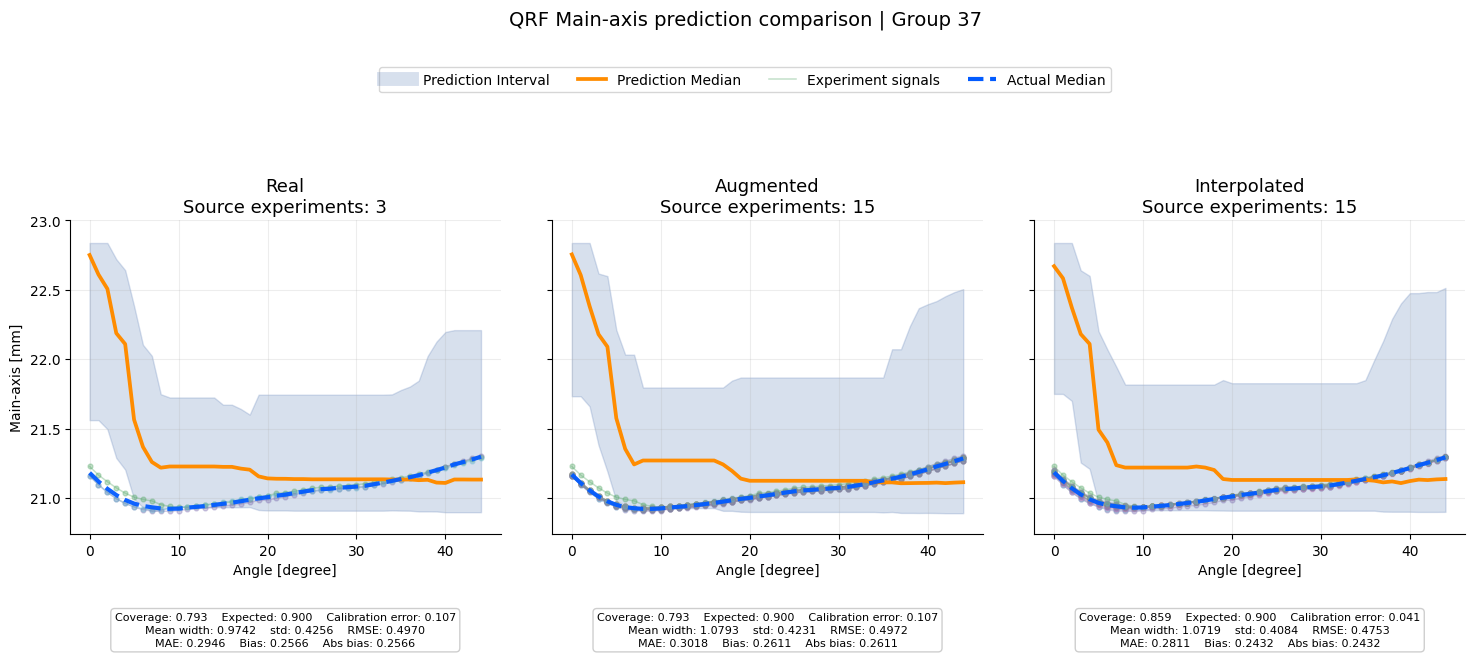

In [32]:
from pathlib import Path
import json
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


GROUP_ID = 37
AXIS = "main"
TARGET_NAME = "Main-axis [mm]"
ANGLE_COLUMN = "Angle[degree]ORDistance[mm]"

DATA_SOURCES = {
    "real": "Real",
    "sensor_augmented_noise__time_wrapping__scaling__jittering": "Augmented",
    "within_group_interpolation_raw": "Interpolated",
}

Y_AXIS_LIMITS = (20.74, 23.0)

EXPERIMENT_SIGNAL_COLORS = [
    "#55A868",
    "#8172B2",
    "#64B5CD",
    "#C44E52",
    "#937860",
    "#DA8BC3",
]


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    while True:
        if (current / "data").exists() and (
            current / "src" / "pipeline" / "ml" / "qrf"
        ).exists():
            return current
        if current == current.parent:
            raise RuntimeError("Could not locate the project root.")
        current = current.parent


PROJECT_ROOT = find_project_root(Path.cwd())
QRF_ROOT = PROJECT_ROOT / "src" / "pipeline" / "ml" / "qrf"
MODEL_RESULTS_DIR = QRF_ROOT / "results" / "models"
BENDING_SETUP_PATH = PROJECT_ROOT / "data" / "rf_augmented" / "ui_data" / "unique_bending_setups.csv"

GEOMETRY_SOURCE_PATHS = {
    "real": PROJECT_ROOT / "data" / "processed" / "geometry.csv",
    "sensor_augmented_noise__time_wrapping__scaling__jittering": (
        PROJECT_ROOT
        / "data"
        / "rf_augmented"
        / "final_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering.parquet"
    ),
    "within_group_interpolation_raw": (
        PROJECT_ROOT
        / "data"
        / "rf_augmented"
        / "final_geometry_within_group_interpolation_raw.parquet"
    ),
}


def read_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported table format: {path}")


def parse_integer_list(value) -> list[int]:
    if isinstance(value, str):
        value = ast.literal_eval(value)
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (list, tuple, set)):
        return sorted(int(item) for item in value if pd.notna(item))
    if pd.isna(value):
        return []
    return [int(value)]


def real_group_experiment_ids(group_id: int) -> list[int]:
    setup_df = pd.read_csv(BENDING_SETUP_PATH)
    row = setup_df[
        pd.to_numeric(setup_df["Group_ID"], errors="coerce").eq(group_id)
    ]

    if row.empty:
        raise ValueError(f"Group_ID={group_id} not found in {BENDING_SETUP_PATH}")

    return parse_integer_list(row.iloc[0]["Experiment_Number"])


def load_source_signal_data(geometry_source: str, group_id: int) -> pd.DataFrame:
    path = GEOMETRY_SOURCE_PATHS[geometry_source]
    geometry_df = read_table(path).copy()

    required = {"Experiment_ID", ANGLE_COLUMN, TARGET_NAME}
    missing = required.difference(geometry_df.columns)
    if missing:
        raise KeyError(f"{path} is missing columns: {sorted(missing)}")

    if geometry_source == "real":
        experiment_ids = real_group_experiment_ids(group_id)
        source_df = geometry_df[
            pd.to_numeric(geometry_df["Experiment_ID"], errors="coerce").isin(
                experiment_ids
            )
        ].copy()
    else:
        group_column = (
            "Group_ID"
            if "Group_ID" in geometry_df.columns
            else "group_id"
            if "group_id" in geometry_df.columns
            else None
        )
        if group_column is None:
            raise KeyError(f"{path} has no Group_ID or group_id column.")

        source_df = geometry_df[
            pd.to_numeric(geometry_df[group_column], errors="coerce").eq(group_id)
        ].copy()

    for column in ["Experiment_ID", ANGLE_COLUMN, TARGET_NAME]:
        source_df[column] = pd.to_numeric(source_df[column], errors="coerce")

    source_df = source_df.dropna(
        subset=["Experiment_ID", ANGLE_COLUMN, TARGET_NAME]
    ).copy()

    source_df = source_df[
        source_df[ANGLE_COLUMN].between(0, 44, inclusive="both")
    ].copy()

    if source_df.empty:
        raise ValueError(f"No source geometry rows for {geometry_source}, group {group_id}")

    return source_df


def find_latest_artifact_with_group(geometry_source: str, axis: str, group_id: int):
    axis_dir = MODEL_RESULTS_DIR / geometry_source / axis
    if not axis_dir.exists():
        raise FileNotFoundError(f"Missing model directory: {axis_dir}")

    candidates = []

    for metadata_path in axis_dir.glob("*/metadata.json"):
        artifact_dir = metadata_path.parent

        prediction_path = artifact_dir / "test_predictions.parquet"
        if not prediction_path.exists():
            prediction_path = artifact_dir / "test_predictions.csv"
        if not prediction_path.exists():
            continue

        pred_df = read_table(prediction_path)
        if "Group_ID" not in pred_df.columns:
            continue

        group_ids = pd.to_numeric(pred_df["Group_ID"], errors="coerce")
        if not group_ids.eq(group_id).any():
            continue

        with metadata_path.open("r", encoding="utf-8") as file:
            metadata = json.load(file)

        candidates.append(
            {
                "modified_time": artifact_dir.stat().st_mtime,
                "artifact_dir": artifact_dir,
                "prediction_path": prediction_path,
                "metadata": metadata,
            }
        )

    if not candidates:
        raise FileNotFoundError(
            f"No {axis} artifact found for source={geometry_source!r} "
            f"containing Group_ID={group_id}."
        )

    return max(candidates, key=lambda item: item["modified_time"])


def prepare_prediction_curve(prediction_df: pd.DataFrame, group_id: int):
    group_df = prediction_df[
        pd.to_numeric(prediction_df["Group_ID"], errors="coerce").eq(group_id)
    ].copy()

    required_columns = {
        ANGLE_COLUMN,
        "Experiment_ID",
        "y_true",
        "y_median",
        "y_lower",
        "y_upper",
    }
    missing = required_columns.difference(group_df.columns)
    if missing:
        raise KeyError(f"Prediction data is missing columns: {sorted(missing)}")

    for column in [
        ANGLE_COLUMN,
        "Experiment_ID",
        "y_true",
        "y_median",
        "y_lower",
        "y_upper",
    ]:
        group_df[column] = pd.to_numeric(group_df[column], errors="coerce")

    group_df = group_df.dropna(
        subset=[
            ANGLE_COLUMN,
            "Experiment_ID",
            "y_true",
            "y_median",
            "y_lower",
            "y_upper",
        ]
    )

    group_df = group_df[
        group_df[ANGLE_COLUMN].between(0, 44, inclusive="both")
    ].copy()

    curve_df = (
        group_df
        .groupby(ANGLE_COLUMN, as_index=False)
        .agg(
            y_median=("y_median", "mean"),
            y_lower=("y_lower", "mean"),
            y_upper=("y_upper", "mean"),
        )
        .sort_values(ANGLE_COLUMN)
        .reset_index(drop=True)
    )

    return curve_df, group_df


def prepare_actual_curve(source_df: pd.DataFrame) -> pd.DataFrame:
    return (
        source_df
        .groupby(ANGLE_COLUMN, as_index=False)
        .agg(y_true=(TARGET_NAME, "mean"))
        .sort_values(ANGLE_COLUMN)
        .reset_index(drop=True)
    )


def resolve_expected_coverage(metadata: dict) -> float:
    model_config = metadata.get("model_config", {})
    lower = float(
        model_config.get(
            "lower_quantile",
            metadata.get("lower_quantile", 0.05),
        )
    )
    upper = float(
        model_config.get(
            "upper_quantile",
            metadata.get("upper_quantile", 0.95),
        )
    )
    return upper - lower


def compute_group_metrics(prediction_group_df: pd.DataFrame, expected_coverage: float):
    y_true = prediction_group_df["y_true"].to_numpy(dtype=float)
    y_median = prediction_group_df["y_median"].to_numpy(dtype=float)
    y_lower = prediction_group_df["y_lower"].to_numpy(dtype=float)
    y_upper = prediction_group_df["y_upper"].to_numpy(dtype=float)

    finite_mask = (
        np.isfinite(y_true)
        & np.isfinite(y_median)
        & np.isfinite(y_lower)
        & np.isfinite(y_upper)
    )

    y_true = y_true[finite_mask]
    y_median = y_median[finite_mask]
    y_lower = y_lower[finite_mask]
    y_upper = y_upper[finite_mask]

    inside_interval = (y_true >= y_lower) & (y_true <= y_upper)
    residual = y_median - y_true

    coverage = float(inside_interval.mean())
    mean_width = float(np.mean(y_upper - y_lower))
    residual_std = float(np.std(residual, ddof=0))
    rmse = float(np.sqrt(np.mean(np.square(residual))))
    mae = float(np.mean(np.abs(residual)))
    bias = float(np.mean(residual))

    return {
        "coverage": coverage,
        "expected_coverage": expected_coverage,
        "calibration_error": abs(coverage - expected_coverage),
        "mean_interval_width": mean_width,
        "residual_std": residual_std,
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "abs_bias": abs(bias),
    }


def format_metric_text(metrics: dict[str, float]) -> str:
    return (
        f"Coverage: {metrics['coverage']:.3f}    "
        f"Expected: {metrics['expected_coverage']:.3f}    "
        f"Calibration error: {metrics['calibration_error']:.3f}\n"
        f"Mean width: {metrics['mean_interval_width']:.4f}    "
        f"std: {metrics['residual_std']:.4f}    "
        f"RMSE: {metrics['rmse']:.4f}\n"
        f"MAE: {metrics['mae']:.4f}    "
        f"Bias: {metrics['bias']:.4f}    "
        f"Abs bias: {metrics['abs_bias']:.4f}"
    )


fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6.4),
    sharex=True,
    sharey=True,
)

for ax, (geometry_source, source_label) in zip(axes, DATA_SOURCES.items()):
    artifact = find_latest_artifact_with_group(
        geometry_source=geometry_source,
        axis=AXIS,
        group_id=GROUP_ID,
    )

    prediction_df = read_table(artifact["prediction_path"])
    prediction_curve_df, prediction_group_df = prepare_prediction_curve(
        prediction_df,
        GROUP_ID,
    )

    source_signal_df = load_source_signal_data(geometry_source, GROUP_ID)
    actual_curve_df = prepare_actual_curve(source_signal_df)

    metadata = artifact["metadata"]
    expected_coverage = resolve_expected_coverage(metadata)
    metrics = compute_group_metrics(prediction_group_df, expected_coverage)

    source_experiment_count = int(source_signal_df["Experiment_ID"].nunique())

    x_pred = prediction_curve_df[ANGLE_COLUMN].to_numpy()

    ax.fill_between(
        x_pred,
        prediction_curve_df["y_lower"].to_numpy(),
        prediction_curve_df["y_upper"].to_numpy(),
        color="#4C72B0",
        alpha=0.22,
    )

    ax.plot(
        x_pred,
        prediction_curve_df["y_median"].to_numpy(),
        color="#FF8C00",
        linewidth=2.7,
        zorder=10,
    )

    signal_ids = (
        source_signal_df["Experiment_ID"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    for color_index, experiment_id in enumerate(signal_ids):
        signal_color = EXPERIMENT_SIGNAL_COLORS[
            color_index % len(EXPERIMENT_SIGNAL_COLORS)
        ]
        signal_df = source_signal_df[
            source_signal_df["Experiment_ID"].eq(experiment_id)
        ].sort_values(ANGLE_COLUMN)

        ax.plot(
            signal_df[ANGLE_COLUMN],
            signal_df[TARGET_NAME],
            color=signal_color,
            linewidth=1.1,
            alpha=0.35,
            label="_nolegend_",
            zorder=7,
        )
        ax.scatter(
            signal_df[ANGLE_COLUMN],
            signal_df[TARGET_NAME],
            color=signal_color,
            s=12,
            marker="o",
            alpha=0.35,
            label="_nolegend_",
            zorder=8,
        )

    ax.plot(
        actual_curve_df[ANGLE_COLUMN].to_numpy(),
        actual_curve_df["y_true"].to_numpy(),
        color="#025BFF",
        linewidth=3.0,
        linestyle="--",
        alpha=0.95,
        zorder=11,
    )

    ax.set_title(
        f"{source_label}\nSource experiments: {source_experiment_count}",
        fontsize=13,
    )
    ax.set_xlabel("Angle [degree]")
    ax.set_ylim(*Y_AXIS_LIMITS)
    ax.grid(True, alpha=0.22)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.5,
        -0.25,
        format_metric_text(metrics),
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=8,
        linespacing=1.35,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": "0.80",
            "alpha": 0.95,
        },
        clip_on=False,
    )

axes[0].set_ylabel(TARGET_NAME)

legend_handles = [
    Line2D(
        [0],
        [0],
        color="#4C72B0",
        linewidth=10,
        alpha=0.22,
        label="Prediction Interval",
    ),
    Line2D(
        [0],
        [0],
        color="#FF8C00",
        linewidth=2.7,
        label="Prediction Median",
    ),
    Line2D(
        [0],
        [0],
        color=EXPERIMENT_SIGNAL_COLORS[0],
        linewidth=1.1,
        alpha=0.35,
        label="Experiment signals",
    ),
    Line2D(
        [0],
        [0],
        color="#025BFF",
        linewidth=3.0,
        linestyle="--",
        label="Actual Median",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    f"QRF Main-axis prediction comparison | Group {GROUP_ID}",
    fontsize=14,
    y=1.10,
)

fig.subplots_adjust(
    top=0.77,
    bottom=0.28,
    wspace=0.12,
)

plt.show()

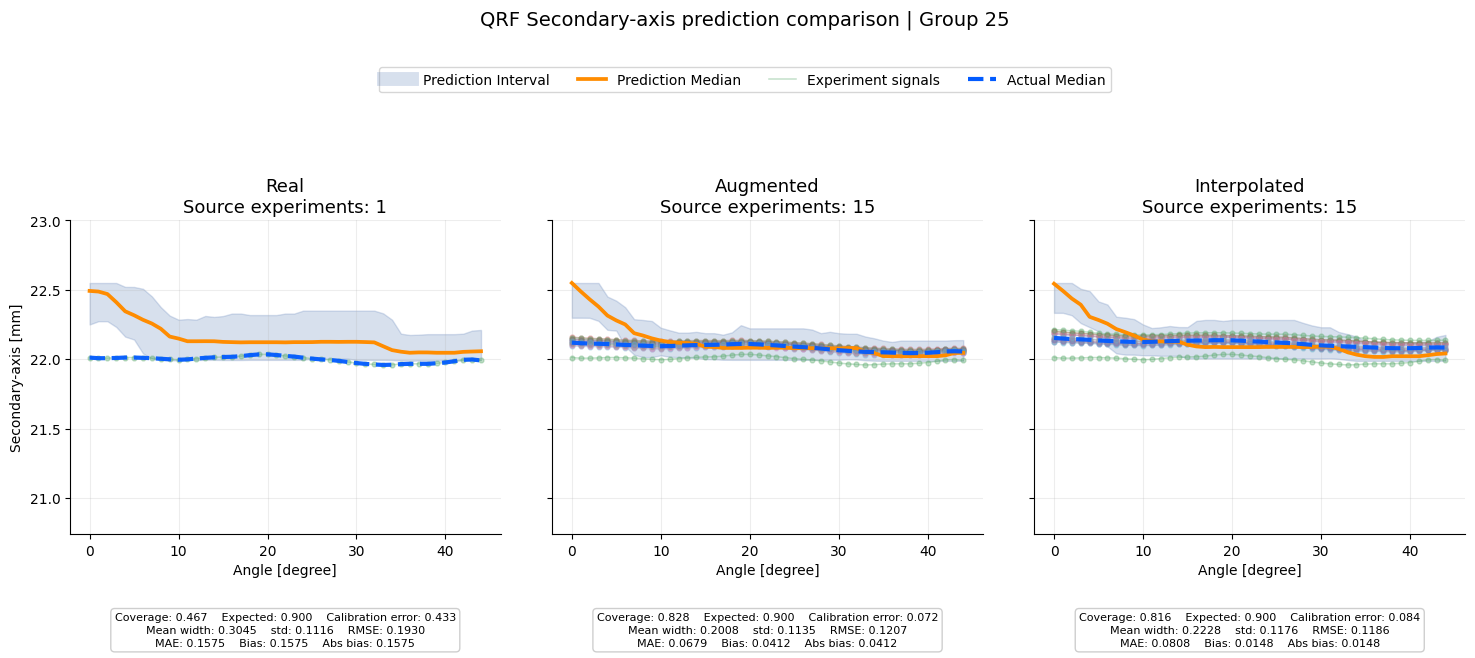

In [34]:
from pathlib import Path
import json
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


GROUP_ID = 25
AXIS = "secondary"
TARGET_NAME = "Secondary-axis [mm]"
ANGLE_COLUMN = "Angle[degree]ORDistance[mm]"

DATA_SOURCES = {
    "real": "Real",
    "sensor_augmented_noise__time_wrapping__scaling__jittering": "Augmented",
    "within_group_interpolation_raw": "Interpolated",
}

Y_AXIS_LIMITS = (20.74, 23.0)

EXPERIMENT_SIGNAL_COLORS = [
    "#55A868",
    "#8172B2",
    "#64B5CD",
    "#C44E52",
    "#937860",
    "#DA8BC3",
]


def find_project_root(start: Path) -> Path:
    current = start.resolve()
    while True:
        if (current / "data").exists() and (
            current / "src" / "pipeline" / "ml" / "qrf"
        ).exists():
            return current
        if current == current.parent:
            raise RuntimeError("Could not locate the project root.")
        current = current.parent


PROJECT_ROOT = find_project_root(Path.cwd())
QRF_ROOT = PROJECT_ROOT / "src" / "pipeline" / "ml" / "qrf"
MODEL_RESULTS_DIR = QRF_ROOT / "results" / "models"
BENDING_SETUP_PATH = PROJECT_ROOT / "data" / "rf_augmented" / "ui_data" / "unique_bending_setups.csv"

GEOMETRY_SOURCE_PATHS = {
    "real": PROJECT_ROOT / "data" / "processed" / "geometry.csv",
    "sensor_augmented_noise__time_wrapping__scaling__jittering": (
        PROJECT_ROOT
        / "data"
        / "rf_augmented"
        / "final_geometry_sensor_augmented_noise__time_wrapping__scaling__jittering.parquet"
    ),
    "within_group_interpolation_raw": (
        PROJECT_ROOT
        / "data"
        / "rf_augmented"
        / "final_geometry_within_group_interpolation_raw.parquet"
    ),
}


def read_table(path: Path) -> pd.DataFrame:
    if path.suffix.lower() == ".parquet":
        return pd.read_parquet(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path)
    raise ValueError(f"Unsupported table format: {path}")


def parse_integer_list(value) -> list[int]:
    if isinstance(value, str):
        value = ast.literal_eval(value)
    if isinstance(value, np.ndarray):
        value = value.tolist()
    if isinstance(value, (list, tuple, set)):
        return sorted(int(item) for item in value if pd.notna(item))
    if pd.isna(value):
        return []
    return [int(value)]


def real_group_experiment_ids(group_id: int) -> list[int]:
    setup_df = pd.read_csv(BENDING_SETUP_PATH)
    row = setup_df[
        pd.to_numeric(setup_df["Group_ID"], errors="coerce").eq(group_id)
    ]

    if row.empty:
        raise ValueError(f"Group_ID={group_id} not found in {BENDING_SETUP_PATH}")

    return parse_integer_list(row.iloc[0]["Experiment_Number"])


def load_source_signal_data(geometry_source: str, group_id: int) -> pd.DataFrame:
    path = GEOMETRY_SOURCE_PATHS[geometry_source]
    geometry_df = read_table(path).copy()

    required = {"Experiment_ID", ANGLE_COLUMN, TARGET_NAME}
    missing = required.difference(geometry_df.columns)
    if missing:
        raise KeyError(f"{path} is missing columns: {sorted(missing)}")

    if geometry_source == "real":
        experiment_ids = real_group_experiment_ids(group_id)
        source_df = geometry_df[
            pd.to_numeric(geometry_df["Experiment_ID"], errors="coerce").isin(
                experiment_ids
            )
        ].copy()
    else:
        group_column = (
            "Group_ID"
            if "Group_ID" in geometry_df.columns
            else "group_id"
            if "group_id" in geometry_df.columns
            else None
        )
        if group_column is None:
            raise KeyError(f"{path} has no Group_ID or group_id column.")

        source_df = geometry_df[
            pd.to_numeric(geometry_df[group_column], errors="coerce").eq(group_id)
        ].copy()

    for column in ["Experiment_ID", ANGLE_COLUMN, TARGET_NAME]:
        source_df[column] = pd.to_numeric(source_df[column], errors="coerce")

    source_df = source_df.dropna(
        subset=["Experiment_ID", ANGLE_COLUMN, TARGET_NAME]
    ).copy()

    source_df = source_df[
        source_df[ANGLE_COLUMN].between(0, 44, inclusive="both")
    ].copy()

    if source_df.empty:
        raise ValueError(
            f"No source geometry rows for {geometry_source}, group {group_id}"
        )

    return source_df


def find_latest_artifact_with_group(geometry_source: str, axis: str, group_id: int):
    axis_dir = MODEL_RESULTS_DIR / geometry_source / axis
    if not axis_dir.exists():
        raise FileNotFoundError(f"Missing model directory: {axis_dir}")

    candidates = []

    for metadata_path in axis_dir.glob("*/metadata.json"):
        artifact_dir = metadata_path.parent

        prediction_path = artifact_dir / "test_predictions.parquet"
        if not prediction_path.exists():
            prediction_path = artifact_dir / "test_predictions.csv"
        if not prediction_path.exists():
            continue

        pred_df = read_table(prediction_path)
        if "Group_ID" not in pred_df.columns:
            continue

        group_ids = pd.to_numeric(pred_df["Group_ID"], errors="coerce")
        if not group_ids.eq(group_id).any():
            continue

        with metadata_path.open("r", encoding="utf-8") as file:
            metadata = json.load(file)

        candidates.append(
            {
                "modified_time": artifact_dir.stat().st_mtime,
                "artifact_dir": artifact_dir,
                "prediction_path": prediction_path,
                "metadata": metadata,
            }
        )

    if not candidates:
        raise FileNotFoundError(
            f"No {axis} artifact found for source={geometry_source!r} "
            f"containing Group_ID={group_id}."
        )

    return max(candidates, key=lambda item: item["modified_time"])


def prepare_prediction_curve(prediction_df: pd.DataFrame, group_id: int):
    group_df = prediction_df[
        pd.to_numeric(prediction_df["Group_ID"], errors="coerce").eq(group_id)
    ].copy()

    required_columns = {
        ANGLE_COLUMN,
        "Experiment_ID",
        "y_true",
        "y_median",
        "y_lower",
        "y_upper",
    }
    missing = required_columns.difference(group_df.columns)
    if missing:
        raise KeyError(f"Prediction data is missing columns: {sorted(missing)}")

    for column in [
        ANGLE_COLUMN,
        "Experiment_ID",
        "y_true",
        "y_median",
        "y_lower",
        "y_upper",
    ]:
        group_df[column] = pd.to_numeric(group_df[column], errors="coerce")

    group_df = group_df.dropna(
        subset=[
            ANGLE_COLUMN,
            "Experiment_ID",
            "y_true",
            "y_median",
            "y_lower",
            "y_upper",
        ]
    )

    group_df = group_df[
        group_df[ANGLE_COLUMN].between(0, 44, inclusive="both")
    ].copy()

    curve_df = (
        group_df
        .groupby(ANGLE_COLUMN, as_index=False)
        .agg(
            y_median=("y_median", "mean"),
            y_lower=("y_lower", "mean"),
            y_upper=("y_upper", "mean"),
        )
        .sort_values(ANGLE_COLUMN)
        .reset_index(drop=True)
    )

    return curve_df, group_df


def prepare_actual_curve(source_df: pd.DataFrame) -> pd.DataFrame:
    return (
        source_df
        .groupby(ANGLE_COLUMN, as_index=False)
        .agg(y_true=(TARGET_NAME, "mean"))
        .sort_values(ANGLE_COLUMN)
        .reset_index(drop=True)
    )


def resolve_expected_coverage(metadata: dict) -> float:
    model_config = metadata.get("model_config", {})
    lower = float(
        model_config.get(
            "lower_quantile",
            metadata.get("lower_quantile", 0.05),
        )
    )
    upper = float(
        model_config.get(
            "upper_quantile",
            metadata.get("upper_quantile", 0.95),
        )
    )
    return upper - lower


def compute_group_metrics(prediction_group_df: pd.DataFrame, expected_coverage: float):
    y_true = prediction_group_df["y_true"].to_numpy(dtype=float)
    y_median = prediction_group_df["y_median"].to_numpy(dtype=float)
    y_lower = prediction_group_df["y_lower"].to_numpy(dtype=float)
    y_upper = prediction_group_df["y_upper"].to_numpy(dtype=float)

    finite_mask = (
        np.isfinite(y_true)
        & np.isfinite(y_median)
        & np.isfinite(y_lower)
        & np.isfinite(y_upper)
    )

    y_true = y_true[finite_mask]
    y_median = y_median[finite_mask]
    y_lower = y_lower[finite_mask]
    y_upper = y_upper[finite_mask]

    inside_interval = (y_true >= y_lower) & (y_true <= y_upper)
    residual = y_median - y_true

    coverage = float(inside_interval.mean())
    mean_width = float(np.mean(y_upper - y_lower))
    residual_std = float(np.std(residual, ddof=0))
    rmse = float(np.sqrt(np.mean(np.square(residual))))
    mae = float(np.mean(np.abs(residual)))
    bias = float(np.mean(residual))

    return {
        "coverage": coverage,
        "expected_coverage": expected_coverage,
        "calibration_error": abs(coverage - expected_coverage),
        "mean_interval_width": mean_width,
        "residual_std": residual_std,
        "rmse": rmse,
        "mae": mae,
        "bias": bias,
        "abs_bias": abs(bias),
    }


def format_metric_text(metrics: dict[str, float]) -> str:
    return (
        f"Coverage: {metrics['coverage']:.3f}    "
        f"Expected: {metrics['expected_coverage']:.3f}    "
        f"Calibration error: {metrics['calibration_error']:.3f}\n"
        f"Mean width: {metrics['mean_interval_width']:.4f}    "
        f"std: {metrics['residual_std']:.4f}    "
        f"RMSE: {metrics['rmse']:.4f}\n"
        f"MAE: {metrics['mae']:.4f}    "
        f"Bias: {metrics['bias']:.4f}    "
        f"Abs bias: {metrics['abs_bias']:.4f}"
    )


fig, axes = plt.subplots(
    nrows=1,
    ncols=3,
    figsize=(18, 6.4),
    sharex=True,
    sharey=True,
)

for ax, (geometry_source, source_label) in zip(axes, DATA_SOURCES.items()):
    artifact = find_latest_artifact_with_group(
        geometry_source=geometry_source,
        axis=AXIS,
        group_id=GROUP_ID,
    )

    prediction_df = read_table(artifact["prediction_path"])
    prediction_curve_df, prediction_group_df = prepare_prediction_curve(
        prediction_df,
        GROUP_ID,
    )

    source_signal_df = load_source_signal_data(geometry_source, GROUP_ID)
    actual_curve_df = prepare_actual_curve(source_signal_df)

    metadata = artifact["metadata"]
    expected_coverage = resolve_expected_coverage(metadata)
    metrics = compute_group_metrics(prediction_group_df, expected_coverage)

    source_experiment_count = int(source_signal_df["Experiment_ID"].nunique())
    x_pred = prediction_curve_df[ANGLE_COLUMN].to_numpy()

    ax.fill_between(
        x_pred,
        prediction_curve_df["y_lower"].to_numpy(),
        prediction_curve_df["y_upper"].to_numpy(),
        color="#4C72B0",
        alpha=0.22,
    )

    ax.plot(
        x_pred,
        prediction_curve_df["y_median"].to_numpy(),
        color="#FF8C00",
        linewidth=2.7,
        zorder=10,
    )

    signal_ids = (
        source_signal_df["Experiment_ID"]
        .dropna()
        .drop_duplicates()
        .sort_values()
        .tolist()
    )

    for color_index, experiment_id in enumerate(signal_ids):
        signal_color = EXPERIMENT_SIGNAL_COLORS[
            color_index % len(EXPERIMENT_SIGNAL_COLORS)
        ]
        signal_df = source_signal_df[
            source_signal_df["Experiment_ID"].eq(experiment_id)
        ].sort_values(ANGLE_COLUMN)

        ax.plot(
            signal_df[ANGLE_COLUMN],
            signal_df[TARGET_NAME],
            color=signal_color,
            linewidth=1.1,
            alpha=0.35,
            label="_nolegend_",
            zorder=7,
        )
        ax.scatter(
            signal_df[ANGLE_COLUMN],
            signal_df[TARGET_NAME],
            color=signal_color,
            s=12,
            marker="o",
            alpha=0.35,
            label="_nolegend_",
            zorder=8,
        )

    ax.plot(
        actual_curve_df[ANGLE_COLUMN].to_numpy(),
        actual_curve_df["y_true"].to_numpy(),
        color="#025BFF",
        linewidth=3.0,
        linestyle="--",
        alpha=0.95,
        zorder=11,
    )

    ax.set_title(
        f"{source_label}\nSource experiments: {source_experiment_count}",
        fontsize=13,
    )
    ax.set_xlabel("Angle [degree]")
    ax.set_ylim(*Y_AXIS_LIMITS)
    ax.grid(True, alpha=0.22)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.text(
        0.5,
        -0.25,
        format_metric_text(metrics),
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=8,
        linespacing=1.35,
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": "0.80",
            "alpha": 0.95,
        },
        clip_on=False,
    )

axes[0].set_ylabel(TARGET_NAME)

legend_handles = [
    Line2D(
        [0],
        [0],
        color="#4C72B0",
        linewidth=10,
        alpha=0.22,
        label="Prediction Interval",
    ),
    Line2D(
        [0],
        [0],
        color="#FF8C00",
        linewidth=2.7,
        label="Prediction Median",
    ),
    Line2D(
        [0],
        [0],
        color=EXPERIMENT_SIGNAL_COLORS[0],
        linewidth=1.1,
        alpha=0.35,
        label="Experiment signals",
    ),
    Line2D(
        [0],
        [0],
        color="#025BFF",
        linewidth=3.0,
        linestyle="--",
        label="Actual Median",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    frameon=True,
    bbox_to_anchor=(0.5, 1.02),
)

fig.suptitle(
    f"QRF Secondary-axis prediction comparison | Group {GROUP_ID}",
    fontsize=14,
    y=1.10,
)

fig.subplots_adjust(
    top=0.77,
    bottom=0.28,
    wspace=0.12,
)

plt.show()